In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Traveller Intervention

The dataset is taken from T2_BIOSECURITY.Traveller.Intervention table, de-IDed. It includes interventions collected over the past nearly 3 years (Jan 2022 - Nov2024)

In [2]:
ti_df = pd.read_csv("./Traveller_Intervention.csv.gz", low_memory=False)

In [3]:
ti_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6827818 entries, 0 to 6827817
Data columns (total 21 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Source_system_code               object 
 1   Intervention_ID                  object 
 2   Intervention_date                object 
 3   Creation_date                    object 
 4   Movement_type_code               object 
 5   Flight_number                    object 
 6   Vessel_name                      object 
 7   Is_declarant                     int64  
 8   Passport_issuing_country_code    object 
 9   Intervention_officer_ID          int64  
 10  Intervention_location_code       object 
 11  Intervention_method_sequence_SK  float64
 12  Non_specified_channel_sequence   object 
 13  Detector_dog_SK                  float64
 14  Is_survey                        int64  
 15  Traveller_age                    float64
 16  Gender_ID                        object 
 17  Interven

In [4]:
with pd.option_context("display.max_columns", None):
    display(ti_df.sample(10))

,Source_system_code,Intervention_ID,Intervention_date,Creation_date,Movement_type_code,Flight_number,Vessel_name,Is_declarant,Passport_issuing_country_code,Intervention_officer_ID,Intervention_location_code,Intervention_method_sequence_SK,Non_specified_channel_sequence,Detector_dog_SK,Is_survey,Traveller_age,Gender_ID,Intervention_outcome_ID,Detector_dog_handler_ID,Is_automated_profile,Comment
4399169,T,INT-16252428-M8B2R,2024-10-25,2024-10-25,A,NaN,NaN,1,AUS,106104,AUPER,18.0,NaN,NaN,0,68.0,M,445290003.0,0,0.0,
5577114,M,VA23057865,2023-09-24,2023-09-24,A,UL604,NaN,1,ZZZ,1917,AUMEL,18.0,NaN,NaN,0,NaN,U,NaN,0,0.0,NaN
5905706,T,INT-11534938-P9Y6S,2023-02-28,2023-02-28,A,QF172,NaN,0,AUS,6058,AUMEL,13.0,NaN,NaN,0,28.0,F,445290000.0,0,1.0,
1964329,T,INT-14988154-G8N2K,2024-06-10,2024-06-10,A,SQ213,NaN,0,SGP,10348,AUPER,12.0,NaN,44.0,0,31.0,M,445290000.0,6194,0.0,
2244644,T,INT-16395601-Y0Z0C,2024-11-09,2024-11-09,A,CZ381,NaN,0,AUS,1239,AUBNE,13.0,NaN,NaN,0,0.0,F,445290000.0,0,0.0,
2989215,T,INT-16057529-N2F4Q,2024-10-07,2024-10-07,A,GS7943,NaN,0,CHN,7883,AUSYD,16.0,NaN,NaN,0,27.0,F,445290002.0,0,1.0,
4309807,T,INT-15814479-N5H3T,2024-09-14,2024-09-14,A,QF60,NaN,0,JPN,2940,AUSYD,12.0,NaN,49.0,0,18.0,M,445290000.0,2873,1.0,
6213630,T,INT-16298709-H6Y3Y,2024-10-30,2024-10-30,A,JQ96,NaN,0,SGP,10349,AUPER,12.0,NaN,44.0,0,33.0,F,445290000.0,6194,0.0,
4069226,T,INT-14952445-P6Q0K,2024-06-05,2024-06-06,A,SQ215,NaN,1,AUS,106224,AUPER,18.0,NaN,NaN,0,74.0,F,445290003.0,0,0.0,
4291243,T,INT-14524346-H9J9H,2024-04-11,2024-04-11,A,SQ221,NaN,0,AUS,2892,AUSYD,12.0,NaN,306.0,0,52.0,M,445290000.0,2940,0.0,


In [6]:
col_dic = {'Flight_number': "XXXX", 'Vessel_name': "", 'Passport_issuing_country_code': "???", 'Non_specified_channel_sequence': "", 'Gender_ID': "U", 'Comment': ""}

for c in col_dic:
    # ti_df.loc[ti_df[c].isna(), c] = ""    # OK
    ti_df[c] = ti_df[c].mask(ti_df[c].isna(), col_dic.get(c))

In [7]:
for c in ("Creation_date", "Intervention_date"):
    ti_df[c] = pd.to_datetime(ti_df[c]).dt.date

# ti_df["Creation_date"].values  # checks OK

In [8]:
for c in ti_df.columns:
    print(f"{c}: {ti_df[c].nunique()}")

Source_system_code: 2
Intervention_ID: 6827818
Intervention_date: 1053
Creation_date: 1053
Movement_type_code: 2
Flight_number: 3887
Vessel_name: 65
Is_declarant: 2
Passport_issuing_country_code: 235
Intervention_officer_ID: 972
Intervention_location_code: 30
Intervention_method_sequence_SK: 32
Non_specified_channel_sequence: 176
Detector_dog_SK: 70
Is_survey: 2
Traveller_age: 123
Gender_ID: 5
Intervention_outcome_ID: 7
Detector_dog_handler_ID: 107
Is_automated_profile: 2
Comment: 61991


In [9]:
for c in ti_df.columns:
    print(f"{c}: {ti_df[c].isna().sum()}")

Source_system_code: 0
Intervention_ID: 0
Intervention_date: 0
Creation_date: 0
Movement_type_code: 0
Flight_number: 0
Vessel_name: 0
Is_declarant: 0
Passport_issuing_country_code: 0
Intervention_officer_ID: 0
Intervention_location_code: 0
Intervention_method_sequence_SK: 12932
Non_specified_channel_sequence: 0
Detector_dog_SK: 5446751
Is_survey: 0
Traveller_age: 429411
Gender_ID: 0
Intervention_outcome_ID: 578252
Detector_dog_handler_ID: 0
Is_automated_profile: 65
Comment: 0


In [10]:
ti_df.describe(include="number")

,Is_declarant,Intervention_officer_ID,Intervention_method_sequence_SK,Detector_dog_SK,Is_survey,Traveller_age,Intervention_outcome_ID,Detector_dog_handler_ID,Is_automated_profile
count,6.827818e+06,6.827818e+06,6.814886e+06,1.381067e+06,6.827818e+06,6.398407e+06,6.249566e+06,6.827818e+06,6.827753e+06
mean,5.352706e-01,6.939537e+03,1.404289e+01,1.930266e+02,2.515269e-02,4.092252e+01,4.452817e+08,1.480710e+03,2.576142e-01
std,4.987545e-01,1.690715e+04,4.099149e+00,9.382705e+01,1.565888e-01,1.940674e+01,1.721437e+06,9.595551e+03,4.373204e-01
min,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+01,0.000000e+00,-1.169000e+03,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.537000e+03,1.200000e+01,1.140000e+02,0.000000e+00,2.700000e+01,4.452900e+08,0.000000e+00,0.000000e+00
50%,1.000000e+00,2.951000e+03,1.300000e+01,2.050000e+02,0.000000e+00,4.000000e+01,4.452900e+08,0.000000e+00,0.000000e+00
75%,1.000000e+00,7.762000e+03,1.800000e+01,2.580000e+02,0.000000e+00,5.600000e+01,4.452900e+08,0.000000e+00,1.000000e+00
max,1.000000e+00,1.072380e+05,3.600000e+01,3.620000e+02,1.000000e+00,1.830000e+03,4.452900e+08,1.064870e+05,1.000000e+00


In [11]:
ti_df.describe(exclude="number")

,Source_system_code,Intervention_ID,Intervention_date,Creation_date,Movement_type_code,Flight_number,Vessel_name,Passport_issuing_country_code,Intervention_location_code,Non_specified_channel_sequence,Gender_ID,Comment
count,6827818,6827818,6827818,6827818,6827818,6827818,6827818,6827818,6827818,6827818,6827818,6827818
unique,2,6827818,1053,1053,2,3887,65,235,30,176,5,61991
top,T,INT-14686790-Y0J2F,2024-10-05,2024-10-05,A,XXXX,,AUS,AUSYD,,F,
freq,6249566,1,12709,12538,6820480,292640,6820481,2396367,2196024,6808141,3447783,6249566


Replace the object type with category where appropriate:

In [13]:
for c in ['Intervention_method_sequence_SK', 'Intervention_outcome_ID', 'Detector_dog_SK', 'Intervention_officer_ID', 'Detector_dog_handler_ID']:
    # ti_df.loc[ti_df[c].isna(), c] = 0    # OK
    ti_df[c] = ti_df[c].mask(ti_df[c].isna(), 0).astype(int)

In [14]:
iout_df = pd.read_csv("./Intervention_Outcome.csv")

ti_df = pd.merge(ti_df, iout_df, on='Intervention_outcome_ID', how="inner").drop(columns='Intervention_outcome_ID')

In [15]:
for c in ("Source_system_code", "Movement_type_code", "Flight_number", "Vessel_name", "Passport_issuing_country_code",
          "Intervention_location_code", "Non_specified_channel_sequence", "Gender_ID", "Intervention_outcome"):
    ti_df[c] = ti_df[c].astype("category")

Replace with bool where only binary values available:

In [16]:
for c in ("Is_survey", "Is_automated_profile", "Is_declarant"):
    ti_df[c] = ti_df[c].astype("bool")

This reduced memory usage materially:

In [17]:
ti_df['Is_declarant'].value_counts()

Is_declarant
True     3654730
False    3173088
Name: count, dtype: int64

In [18]:
ti_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6827818 entries, 0 to 6827817
Data columns (total 21 columns):
 #   Column                           Dtype   
---  ------                           -----   
 0   Source_system_code               category
 1   Intervention_ID                  object  
 2   Intervention_date                object  
 3   Creation_date                    object  
 4   Movement_type_code               category
 5   Flight_number                    category
 6   Vessel_name                      category
 7   Is_declarant                     bool    
 8   Passport_issuing_country_code    category
 9   Intervention_officer_ID          int32   
 10  Intervention_location_code       category
 11  Intervention_method_sequence_SK  int32   
 12  Non_specified_channel_sequence   category
 13  Detector_dog_SK                  int32   
 14  Is_survey                        bool    
 15  Traveller_age                    float64 
 16  Gender_ID                        cat

Usually the Intervention date corresponds to the Creation date, but not always:

In [19]:
(ti_df['Creation_date'] != ti_df['Intervention_date']).sum()

230185

In [21]:
(ti_df['Creation_date'] - ti_df['Intervention_date']).div(np.timedelta64(1, 'D')).value_counts()

0.0      6597633
1.0       222529
2.0         2287
3.0         1159
4.0          616
          ...   
179.0          1
249.0          1
321.0          1
219.0          1
263.0          1
Name: count, Length: 276, dtype: int64

In 597 records the Creation date appears to have happened before intervention:

In [22]:
(ti_df['Creation_date'] < ti_df['Intervention_date']).sum(), (ti_df['Creation_date'] > ti_df['Intervention_date']).sum()

(597, 229588)

285302 airport intervention from unknown flight number:

In [23]:
ti_df.query('Movement_type_code =="A"').shape[0], ti_df.query('Flight_number != "XXXX"').shape[0], ti_df.query('Movement_type_code =="A"').shape[0] - ti_df.query('Flight_number != "XXXX"').shape[0]

(6820480, 6535178, 285302)

In [24]:
ti_df.query('Flight_number != "XXXX"')['Movement_type_code'].unique()

['A']
Categories (2, object): ['A', 'S']

Only a single seaport intervention from unknown vessel:

In [25]:
ti_df.query('Movement_type_code =="S"').shape[0], ti_df.query('Vessel_name != ""').shape[0]

(7338, 7337)

In [26]:
ti_df.query('Vessel_name != ""')['Movement_type_code'].unique()

['S']
Categories (2, object): ['A', 'S']

The daily count of interventions at each location:

In [27]:
interv_count = ti_df.query('Movement_type_code == "A"').\
    pivot_table(values='Intervention_ID', index='Intervention_date', columns='Intervention_location_code', aggfunc='count', fill_value=0, margins=True, observed=True)

with pd.option_context("display.max_columns", None):
    display(interv_count)

Intervention_location_code,AUABL,AUADA,AUADL,AUASP,AUAVV,AUBME,AUBNE,AUCBR,AUCNS,AUDRW,AUEBH,AUFBN,AUGBT,AUHBA,AUHID,AUMCY,AUMEB,AUMEL,AUNLK,AUNTL,AUOOL,AUPCE,AUPER,AUPHE,AURCH,AUROK,AUSYD,AUTSV,NFNLK,All
Intervention_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01,0,0,11,0,0,0,37,0,0,0,0,0,0,0,0,0,0,104,0,0,0,0,25,0,0,0,912,0,0,1089
2022-01-02,0,0,0,0,0,0,32,0,0,0,0,0,0,0,0,0,0,187,0,0,0,0,32,0,0,0,1026,0,0,1277
2022-01-03,0,0,3,0,0,0,38,0,0,8,0,0,0,0,0,0,0,126,0,0,0,0,37,0,0,0,768,0,0,980
2022-01-04,0,0,14,0,0,0,5,0,0,2,0,0,0,0,0,0,0,181,0,0,0,0,29,0,0,0,1281,0,0,1512
2022-01-05,0,0,1,0,0,0,108,0,0,1,0,0,0,0,0,0,0,139,0,0,0,0,31,0,0,0,1549,0,0,1829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-15,0,0,327,0,0,0,1729,48,232,214,0,0,0,0,0,9,0,2540,0,0,146,0,1710,0,0,0,3216,0,11,10182
2024-11-16,0,0,386,0,0,0,2017,0,193,103,4,0,0,0,0,0,0,2722,0,0,309,0,1874,0,0,3,3630,0,1,11242
2024-11-17,0,0,308,0,0,0,2057,48,288,179,0,0,0,32,0,0,0,2851,0,0,181,0,1691,0,0,0,3252,0,2,10889


The daily count of distinct officers at each location:

In [28]:
officer_count = ti_df.query('Movement_type_code == "A"').\
    pivot_table(values='Intervention_officer_ID', index='Intervention_date', columns='Intervention_location_code', aggfunc='nunique', fill_value=0, margins=True, observed=True)

with pd.option_context("display.max_columns", None):
    display(officer_count)

Intervention_location_code,AUABL,AUADA,AUADL,AUASP,AUAVV,AUBME,AUBNE,AUCBR,AUCNS,AUDRW,AUEBH,AUFBN,AUGBT,AUHBA,AUHID,AUMCY,AUMEB,AUMEL,AUNLK,AUNTL,AUOOL,AUPCE,AUPER,AUPHE,AURCH,AUROK,AUSYD,AUTSV,NFNLK,All
Intervention_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01,0,0,4,0,0,0,4,0,0,0,0,0,0,0,0,0,0,16,0,0,0,0,3,0,0,0,34,0,0,61
2022-01-02,0,0,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,5,0,0,0,38,0,0,63
2022-01-03,0,0,2,0,0,0,10,0,0,1,0,0,0,0,0,0,0,19,0,0,0,0,4,0,0,0,35,0,0,70
2022-01-04,0,0,5,0,0,0,5,0,0,2,0,0,0,0,0,0,0,18,0,0,0,0,6,0,0,0,33,0,0,69
2022-01-05,0,0,1,0,0,0,12,0,0,1,0,0,0,0,0,0,0,19,0,0,0,0,6,0,0,0,32,0,0,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-15,0,0,12,0,0,0,36,4,7,10,0,0,0,0,0,1,0,40,0,0,8,0,39,0,0,0,69,0,2,227
2024-11-16,0,0,13,0,0,0,35,0,5,4,2,0,0,0,0,0,0,40,0,0,8,0,32,0,0,1,67,0,1,207
2024-11-17,0,0,12,0,0,0,34,3,5,8,0,0,0,2,0,0,0,37,0,0,8,0,37,0,0,0,72,0,2,219


Dividing the previous two tables yields the daily number of interventions per officer at each location:

In [29]:
with pd.option_context("display.max_columns", None):
    display(interv_count.div(officer_count).fillna(0).round(1).iloc[:-1, :-1])

Intervention_location_code,AUABL,AUADA,AUADL,AUASP,AUAVV,AUBME,AUBNE,AUCBR,AUCNS,AUDRW,AUEBH,AUFBN,AUGBT,AUHBA,AUHID,AUMCY,AUMEB,AUMEL,AUNLK,AUNTL,AUOOL,AUPCE,AUPER,AUPHE,AURCH,AUROK,AUSYD,AUTSV,NFNLK
Intervention_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01,0.0,0.0,2.8,0.0,0.0,0.0,9.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.5,0.0,0.0,0.0,0.0,8.3,0.0,0.0,0.0,26.8,0.0,0.0
2022-01-02,0.0,0.0,0.0,0.0,0.0,0.0,4.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.4,0.0,0.0,0.0,0.0,6.4,0.0,0.0,0.0,27.0,0.0,0.0
2022-01-03,0.0,0.0,1.5,0.0,0.0,0.0,3.8,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.6,0.0,0.0,0.0,0.0,9.2,0.0,0.0,0.0,21.9,0.0,0.0
2022-01-04,0.0,0.0,2.8,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.1,0.0,0.0,0.0,0.0,4.8,0.0,0.0,0.0,38.8,0.0,0.0
2022-01-05,0.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.3,0.0,0.0,0.0,0.0,5.2,0.0,0.0,0.0,48.4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-14,0.0,0.0,20.2,0.0,0.0,0.0,49.9,0.0,21.6,12.9,0.0,0.0,0.0,9.5,0.0,0.0,0.0,61.9,0.0,0.0,23.0,0.0,39.7,0.0,0.0,0.0,45.5,0.0,0.0
2024-11-15,0.0,0.0,27.2,0.0,0.0,0.0,48.0,12.0,33.1,21.4,0.0,0.0,0.0,0.0,0.0,9.0,0.0,63.5,0.0,0.0,18.2,0.0,43.8,0.0,0.0,0.0,46.6,0.0,5.5
2024-11-16,0.0,0.0,29.7,0.0,0.0,0.0,57.6,0.0,38.6,25.8,2.0,0.0,0.0,0.0,0.0,0.0,0.0,68.0,0.0,0.0,38.6,0.0,58.6,0.0,0.0,3.0,54.2,0.0,1.0


The descriptove statistics on the number of interventions per officer per day at the five major airports after 2022:

In [30]:
d2023 = pd.to_datetime("2023-01-01").date()

five_df = interv_count.div(officer_count).fillna(0).iloc[:-1, :-1].reset_index().query('Intervention_date >= @d2023')

five_df[['AUDRW', 'AUADL', 'AUBNE', 'AUMEL', 'AUPER', 'AUSYD']].describe()

Intervention_location_code,AUDRW,AUADL,AUBNE,AUMEL,AUPER,AUSYD
count,688.000000,688.000000,688.000000,688.000000,688.000000,688.000000
mean,16.851758,24.024922,39.354492,45.353899,38.647272,39.803253
std,7.201180,6.566841,8.337408,10.993986,9.051904,12.161984
min,1.000000,10.375000,23.309524,17.650000,13.108696,10.656716
25%,12.000000,19.556490,33.274038,37.806373,32.200284,32.726190
50%,16.535714,23.033333,38.517442,44.360618,37.486184,42.122316
75%,21.500000,27.637987,44.701786,52.374492,43.885913,47.544467
max,42.800000,51.250000,68.529412,82.612903,70.612903,69.583333


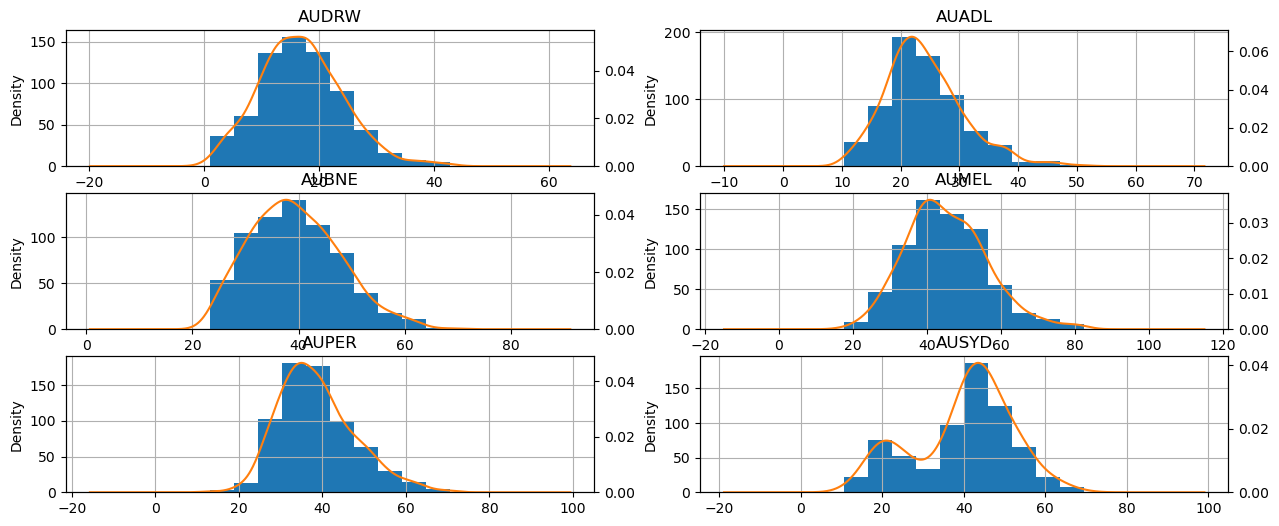

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
for i, (name, col) in enumerate(five_df[['AUDRW', 'AUADL', 'AUBNE', 'AUMEL', 'AUPER', 'AUSYD']].items()):
    r, c = i // 2, i % 2
    ax = axes[r, c]
    col.hist(ax=ax)
    ax2 = col.plot.kde(ax=ax, secondary_y=True, title=name)
    ax2.set_ylim(0)

In [32]:
syd_low = five_df.query('10 <= AUSYD <= 30')['Intervention_date'].to_list()
syd_low[:10], syd_low[-10:]

([datetime.date(2023, 1, 1),
  datetime.date(2023, 1, 2),
  datetime.date(2023, 1, 3),
  datetime.date(2023, 1, 4),
  datetime.date(2023, 1, 5),
  datetime.date(2023, 1, 6),
  datetime.date(2023, 1, 7),
  datetime.date(2023, 1, 8),
  datetime.date(2023, 1, 9),
  datetime.date(2023, 1, 10)],
 [datetime.date(2023, 6, 8),
  datetime.date(2023, 6, 9),
  datetime.date(2023, 6, 10),
  datetime.date(2023, 6, 11),
  datetime.date(2023, 6, 12),
  datetime.date(2023, 6, 13),
  datetime.date(2023, 6, 14),
  datetime.date(2023, 6, 15),
  datetime.date(2023, 11, 17),
  datetime.date(2024, 3, 7)])

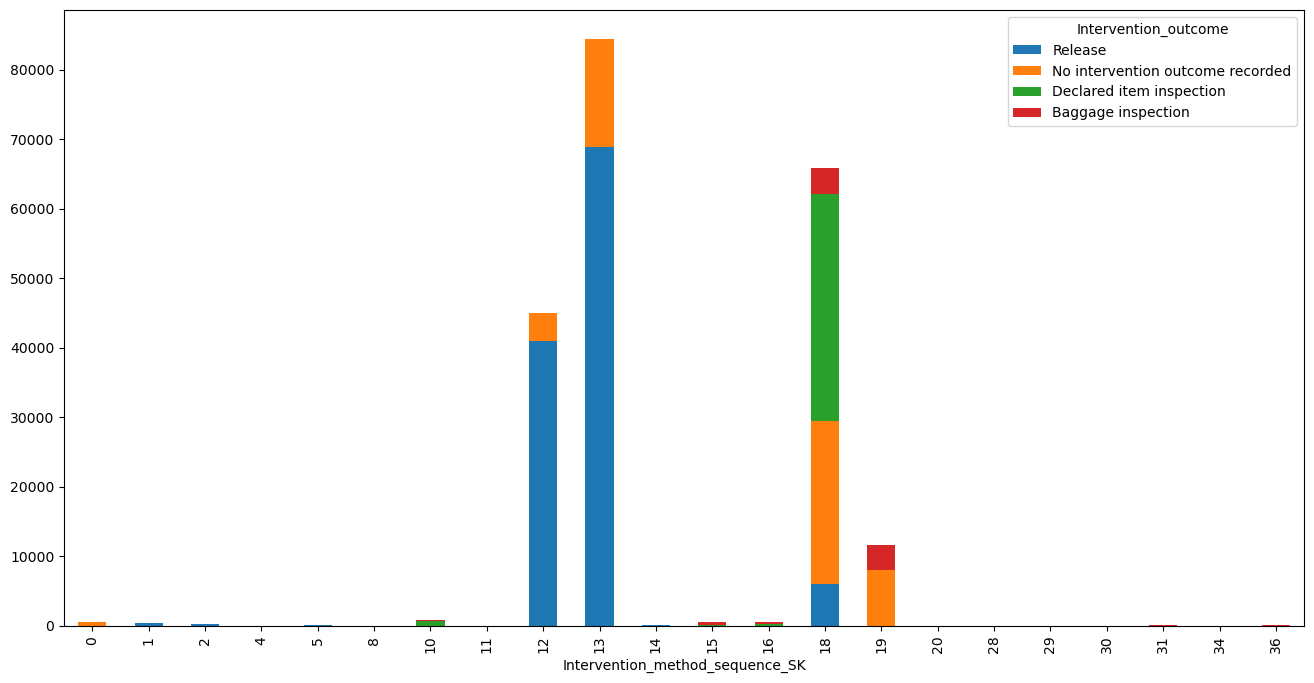

In [33]:
ti_df.query('Intervention_date in @syd_low').\
    query('Intervention_location_code == "AUSYD"').\
    groupby(['Intervention_outcome', 'Intervention_method_sequence_SK'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by=13.0, ascending=False).head(10).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True);

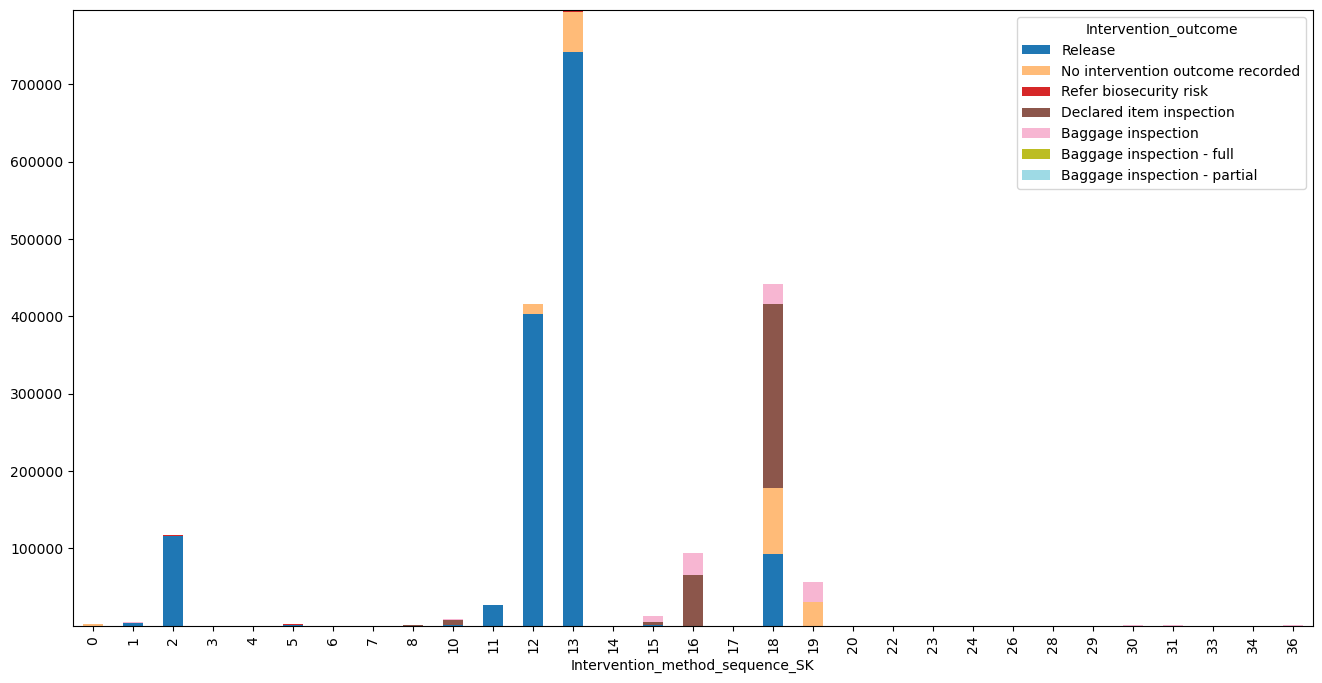

In [34]:
ti_df.query('Intervention_date not in @syd_low').\
    query('Intervention_location_code == "AUSYD"').\
    groupby(['Intervention_outcome', 'Intervention_method_sequence_SK'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by=13.0, ascending=False).head(10).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

Similarly for the seaports:

In [35]:
vessel_interv = ti_df.query('Movement_type_code == "S"').\
    pivot_table(values='Intervention_officer_ID', index='Intervention_date', columns='Intervention_location_code', aggfunc='count', fill_value=0, margins=True, observed=True)

vessel_interv = vessel_interv.loc[:, vessel_interv.iloc[-1] > 0]

with pd.option_context("display.max_columns", None):
    display(vessel_interv)

Intervention_location_code,AUADL,AUBNE,AUCNS,AUDRW,AUFRE,AUHBA,AUMEL,AUNTL,AUSYD,All
Intervention_date,,,,,,,,,,
2022-03-07,0,0,0,1,0,0,0,0,0,1
2022-05-29,0,0,0,0,0,0,0,0,6,6
2022-06-20,0,0,1,0,0,0,0,0,0,1
2022-07-10,0,0,0,0,0,0,0,0,2,2
2022-08-20,0,0,0,0,0,0,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...
2024-08-09,0,0,0,0,0,0,0,0,32,32
2024-08-19,0,0,0,0,0,0,0,0,11,11
2024-08-25,0,0,0,0,0,0,0,0,24,24


In [36]:
vessel_officers = ti_df.query('Movement_type_code == "S"').\
    pivot_table(values='Intervention_officer_ID', index='Intervention_date', columns='Intervention_location_code', aggfunc='nunique', fill_value=0, margins=True, observed=True)

vessel_officers = vessel_officers.loc[:, vessel_officers.iloc[-1] > 0]

with pd.option_context("display.max_columns", None):
    display(vessel_officers)

Intervention_location_code,AUADL,AUBNE,AUCNS,AUDRW,AUFRE,AUHBA,AUMEL,AUNTL,AUSYD,All
Intervention_date,,,,,,,,,,
2022-03-07,0,0,0,1,0,0,0,0,0,1
2022-05-29,0,0,0,0,0,0,0,0,1,1
2022-06-20,0,0,1,0,0,0,0,0,0,1
2022-07-10,0,0,0,0,0,0,0,0,1,1
2022-08-20,0,0,0,0,0,0,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...
2024-08-09,0,0,0,0,0,0,0,0,3,3
2024-08-19,0,0,0,0,0,0,0,0,4,4
2024-08-25,0,0,0,0,0,0,0,0,4,4


In [37]:
vessel_interv.div(vessel_officers).fillna(0).round(1).iloc[:-1, :-1].describe()

Intervention_location_code,AUADL,AUBNE,AUCNS,AUDRW,AUFRE,AUHBA,AUMEL,AUNTL,AUSYD
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000
mean,0.154088,1.489623,0.049371,0.128302,0.081761,0.435535,0.940566,0.003145,4.040566
std,1.485949,2.519887,0.455305,0.540724,0.649859,3.996027,2.847295,0.056077,3.851849
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.700000
75%,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.500000
max,23.000000,15.200000,5.700000,4.000000,7.000000,63.000000,30.000000,1.000000,25.000000


The flight numbers with most interventions:

In [38]:
tmp_df = ti_df.query('Movement_type_code == "A"').\
    groupby('Flight_number', observed=True).\
    agg(total_intervention=('Intervention_ID', "count"), total_flights=('Intervention_date', "nunique")).\
    sort_values(by='total_intervention', ascending=False)

tmp_df

,total_intervention,total_flights
Flight_number,,
XXXX,285302,828
SQ223,92181,1040
SQ255,77841,1043
SQ245,76760,1042
SQ225,75205,995
...,...,...
N915JG,1,1
N9527C,1,1
NA265,1,1


The number of interventions per flight:

In [39]:
(tmp_df['total_intervention'] / tmp_df['total_flights']).sort_values(ascending=False).head(10)

Flight_number
XXXX       344.567633
Unknown    179.224490
TG8050     152.000000
D7200      101.278409
VJ83        96.372093
MK2440      95.000000
CZ381       94.977444
SQ223       88.635577
JQ1012      88.500000
UL608       86.750000
dtype: float64

"Singapore Airlines" on top, followed by "Qantas" and "Jetstar":

In [40]:
ti_df.query('Movement_type_code == "A"').groupby(ti_df['Flight_number'].str.slice(stop=2)).agg(total_intervention=('Intervention_ID', "count")).sort_values(by='total_intervention', ascending=False).head(10)

,total_intervention
Flight_number,
SQ,878209
QF,872851
JQ,788761
EK,334805
NZ,288364
XX,285302
QR,253433
MH,239782
TR,200275


In [41]:
flight_vs_intervsq = ti_df.query('Movement_type_code == "A"')\
    .pivot_table(values="Intervention_ID", index="Intervention_method_sequence_SK", columns="Flight_number", aggfunc="count", fill_value=0, margins=True, observed=True)\
    .round(1)

with pd.option_context("display.max_columns", 20):
    display(flight_vs_intervsq.sort_values(by='All', axis=1))

Flight_number,PR223,T7-CJK,L151,KQ886,TB613,KL835,TD218,KIWI692,TD475,TD479,...,QR900,EK420,SQ235,SQ279,SQ225,SQ245,SQ255,SQ223,XXXX,All
Intervention_method_sequence_SK,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,477,480,104,137,379,126,146,357,6,12904
1,0,0,0,0,0,0,0,0,0,0,...,115,150,328,616,375,341,384,625,853,19684
2,0,0,0,0,0,0,0,0,0,0,...,3102,2941,2349,1076,2775,2784,2387,2658,21069,373500
3,0,0,0,0,0,0,0,0,0,0,...,0,1,3,2,0,0,2,0,65,194
4,0,0,0,0,0,0,0,0,0,0,...,0,0,136,7,0,129,179,39,113,3656
5,0,0,0,0,0,0,0,0,0,0,...,126,102,278,33,211,379,267,152,296,10024
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
7,0,0,0,0,0,0,0,0,0,0,...,0,0,56,5,0,72,66,5,28,1485
8,0,0,0,0,0,0,0,0,0,0,...,20,22,92,41,44,149,130,42,89,4227


In [42]:
ti_df.query('Movement_type_code == "A"').\
            groupby(['Intervention_method_sequence_SK', ti_df.query('Movement_type_code == "A"')['Flight_number']], observed=True)['Intervention_ID'].count().\
            unstack().fillna(0)

Flight_number,PR223,D7212,JQ144,NZ173,NZ195,NZ213,QF178,VA094,VA146,VJ083,...,vn787,vn791,vn794,vq216,vw779,vy89,x,xj382,xx0000,zl402
Intervention_method_sequence_SK,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
ti_df.query('Movement_type_code == "A"')['Flight_number'].str.slice(stop=2).unique()

array(['TG', 'Un', 'KE', 'OD', 'QF', 'PR', 'QR', 'NZ', 'ID', 'CX', 'LA',
       'FJ', 'SQ', 'TR', 'VA', 'EK', 'JQ', 'AC', 'VN', 'CZ', 'XX', 'VJ',
       '3U', 'EY', 'UL', 'D7', 'GA', 'QZ', 'UA', 'PX', 'MH', 'MF', '5J',
       'MU', 'OZ', 'JD', 'AA', 'MK', 'JL', 'AI', 'HA', 'XJ', 'QH', 'ek',
       'IE', 'HU', 'DL', 'CI', 'CA', 'SA', '3C', 'TW', 'BR', 'AK', 'NH',
       'UN', 'mh', 'BA', 'AS', 'TL', 'NF', 'va', 'SB', 'QG', 'jq', '3K',
       'ON', 'BI', 'ot', 'sq', 'qf', 'GS', 'tg', 'Va', 'un', 'HX', 'px',
       'vj', 'ie', 'nz', 'cz', 'TK', 'od', 'JN', 'cx', 'ey', 'd7', 'N2',
       'tr', 'ai', 'EV', 'FR', 'ul', 'AY', 'ba', 'qr', 'pr', 'OA', 'ga',
       'mu', 'C0', 'TQ', 'fj', 'nc', '*', '00', 'RC', 'OH', 'NC', 'C1',
       'VU', 'SI', 'K4', 'YN', 'DE', ' D', 'TT', 'Q2', 'GT', 'ke', 'M8',
       'GN', 'T0', 'HF', '19', 'DJ', 'ac', 'V2', 'JK', 'QK', 'DI', 'x',
       'X2', '3L', 'on', 'LX', 'mf', 'ua', 'Q0', 'FX', 'EI', 'la', 'vw',
       '02', 'KI', '3u', 'LH', 'ca', 'QE', 'VH', 'CN'

In [44]:
with pd.option_context("display.max_columns", 20):
    display(ti_df.query('Movement_type_code == "A"').\
            groupby(['Intervention_method_sequence_SK', ti_df.query('Movement_type_code == "A"')['Flight_number'].str.rstrip().str.slice(stop=2)], observed=True).\
            agg(total_intervention=('Intervention_ID', "count")).\
            unstack().\
            fillna(0).\
            droplevel(0, axis=1).\
            rename_axis(columns={'Flight_number': 'Airline'})\
            [['QF', 'JQ', 'SQ', 'EK', 'QR', 'NZ', 'TR', 'VA', 'MH', 'XX']])

Airline,QF,JQ,SQ,EK,QR,NZ,TR,VA,MH,XX
Intervention_method_sequence_SK,,,,,,,,,,
0,1025.0,620.0,2345.0,1159.0,1216.0,190.0,958.0,102.0,1049.0,6.0
1,2433.0,1805.0,3922.0,614.0,533.0,391.0,585.0,304.0,1148.0,853.0
2,47506.0,63427.0,39913.0,25175.0,17115.0,32006.0,10107.0,13708.0,7965.0,21069.0
3,17.0,22.0,20.0,6.0,7.0,11.0,1.0,2.0,3.0,65.0
4,454.0,366.0,620.0,196.0,152.0,120.0,50.0,157.0,51.0,113.0
5,841.0,953.0,1768.0,598.0,414.0,327.0,388.0,295.0,325.0,296.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,249.0,108.0,259.0,58.0,85.0,37.0,8.0,32.0,19.0,28.0
8,464.0,260.0,720.0,276.0,173.0,79.0,121.0,84.0,123.0,89.0


In [45]:
ti_df.query('Movement_type_code == "A"').groupby('Intervention_method_sequence_SK').agg(total_intervention=('Intervention_ID', "count")).sort_values(by='total_intervention', ascending=False)

,total_intervention
Intervention_method_sequence_SK,
18,2251264
13,2141023
12,1414470
2,373500
16,224090
19,148251
11,106904
15,61739
10,29189


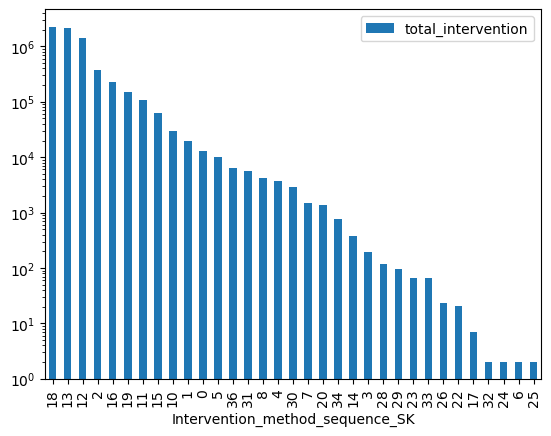

In [46]:
ti_df.query('Movement_type_code == "A"').groupby('Intervention_method_sequence_SK').agg(total_intervention=('Intervention_ID', "count")).sort_values(by='total_intervention', ascending=False).plot(kind="bar", log=True);

In [47]:
with pd.option_context("display.max_columns", 20):
    display(flight_vs_intervsq.sort_values(by='All', axis=0))

Flight_number,PR223,D7212,JQ144,NZ173,NZ195,NZ213,QF178,VA094,VA146,VJ083,...,vn791,vn794,vq216,vw779,vy89,x,xj382,xx0000,zl402,All
Intervention_method_sequence_SK,,,,,,,,,,,,,,,,,,,,,
24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
32,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20
26,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,22
33,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,64
23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,66


In [48]:
ti_df.query('Movement_type_code == "S"').groupby('Intervention_method_sequence_SK').agg(total_intervention=('Intervention_ID', "count")).sort_values(by='total_intervention', ascending=False)

,total_intervention
Intervention_method_sequence_SK,
19,4805
18,2402
13,92
0,28
12,11


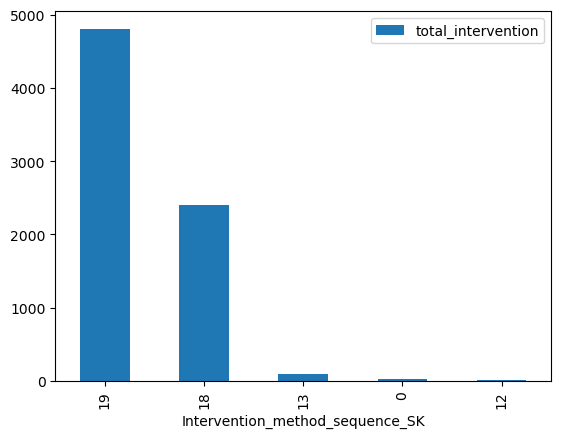

In [49]:
ti_df.query('Movement_type_code == "S"').groupby('Intervention_method_sequence_SK').agg(total_intervention=('Intervention_ID', "count")).sort_values(by='total_intervention', ascending=False).plot(kind="bar");

In Perth the preferred method is 18.0 (Inspection bench), while in Sydney 13.0 (2D X-ray), and in Melbourne 12.0 (Detector dog). The relative lack of 12.0 type intervention is most obvious for Perth.

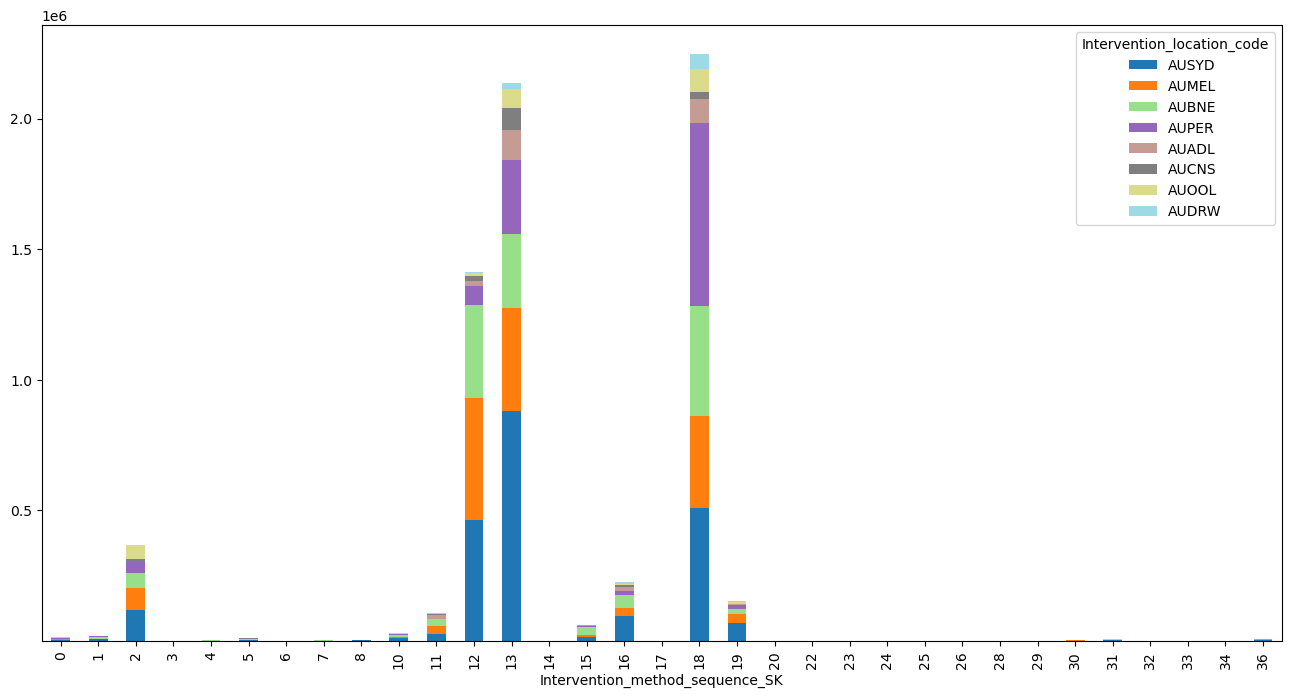

In [50]:
ti_df.groupby(['Intervention_location_code', 'Intervention_method_sequence_SK'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by=13.0, ascending=False).head(8).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

The contrast in the use of detector dogs is most apparent between Melbourne and Peth. The latter seems to have slightly higher "headcounts" of both dosg and their handlers.
Yet, the number of interventins is only a fraction of the former. Also note that in Sydney dogs and their handlers seem to be half as busy as in Melbourne.

In [51]:
ti_df.groupby(['Intervention_location_code'], observed=True)['Detector_dog_SK'].nunique()

Intervention_location_code
AUABL     4
AUADA     1
AUADL     4
AUASP     1
AUAVV     9
AUBME     1
AUBNE    25
AUCBR     1
AUCNS     5
AUDRW     7
AUEBH     2
AUFBN     1
AUFRE     1
AUGBT     1
AUHBA     2
AUHID     1
AUMCY     6
AUMEB     2
AUMEL    21
AUNLK     1
AUNTL     1
AUOOL    12
AUPCE     1
AUPER    24
AUPHE     1
AURCH     1
AUROK     1
AUSYD    44
AUTSV     1
NFNLK     1
Name: Detector_dog_SK, dtype: int64

In [52]:
ti_df.query('Detector_dog_SK > 0').\
    groupby(['Intervention_location_code'], observed=True).\
    agg(total_dog_interventions=('Detector_dog_SK', lambda x: x.count()),
        total_dogs=('Detector_dog_SK', lambda x: x.nunique()),
        total_dog_handlers=('Detector_dog_handler_ID', lambda x: x.nunique())
       ).fillna(0).astype("int").sort_values(by='total_dog_interventions', ascending=False)

,total_dog_interventions,total_dogs,total_dog_handlers
Intervention_location_code,,,
AUMEL,467591,20,25
AUSYD,459640,43,45
AUBNE,339702,24,42
AUPER,62141,23,27
AUCNS,22182,4,25
AUADL,13216,3,4
AUOOL,8350,11,18
AUDRW,8000,6,15
AUMCY,99,5,5


Not much daily variation in the activity, with weekends sligthly busier in Sydney and Melbourne:

In [53]:
ti_df.groupby(['Intervention_location_code', pd.to_datetime(ti_df['Intervention_date']).dt.weekday], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention_date": ""}).\
    rename(columns={0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}).sort_values(by='Mon', ascending=False)

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Intervention_location_code,,,,,,,
AUSYD,313409,310153,294953,298573,306820,347490,324626
AUMEL,190888,196887,192701,194600,207063,210208,222441
AUBNE,182194,177028,161325,186000,184941,196691,194942
AUPER,160168,155015,157169,167515,171868,168835,167025
AUOOL,43943,30801,23952,43830,25857,49032,23099
AUADL,35957,39497,33310,42563,36799,41897,38164
AUCNS,22746,16113,20998,18365,26379,21352,23084
AUDRW,16904,14499,17094,15522,16345,18288,9536
AUHBA,287,620,107,932,132,84,959


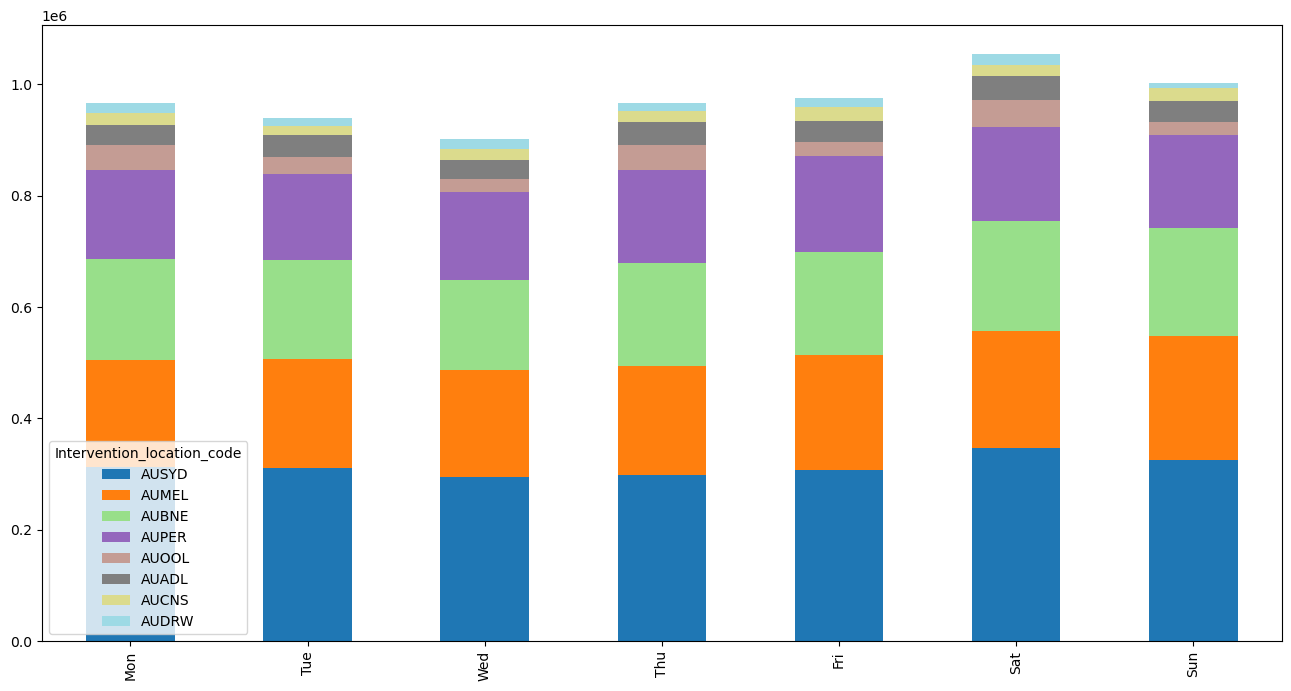

In [54]:
ti_df.groupby(['Intervention_location_code', pd.to_datetime(ti_df['Intervention_date']).dt.weekday], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention_date": ""}).\
    rename(columns={0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}).\
    sort_values(by='Mon', ascending=False).head(8).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

July is the busiest month, while Feb and Mar the least busy (note that Dec is unaccounted yet for 2024): 

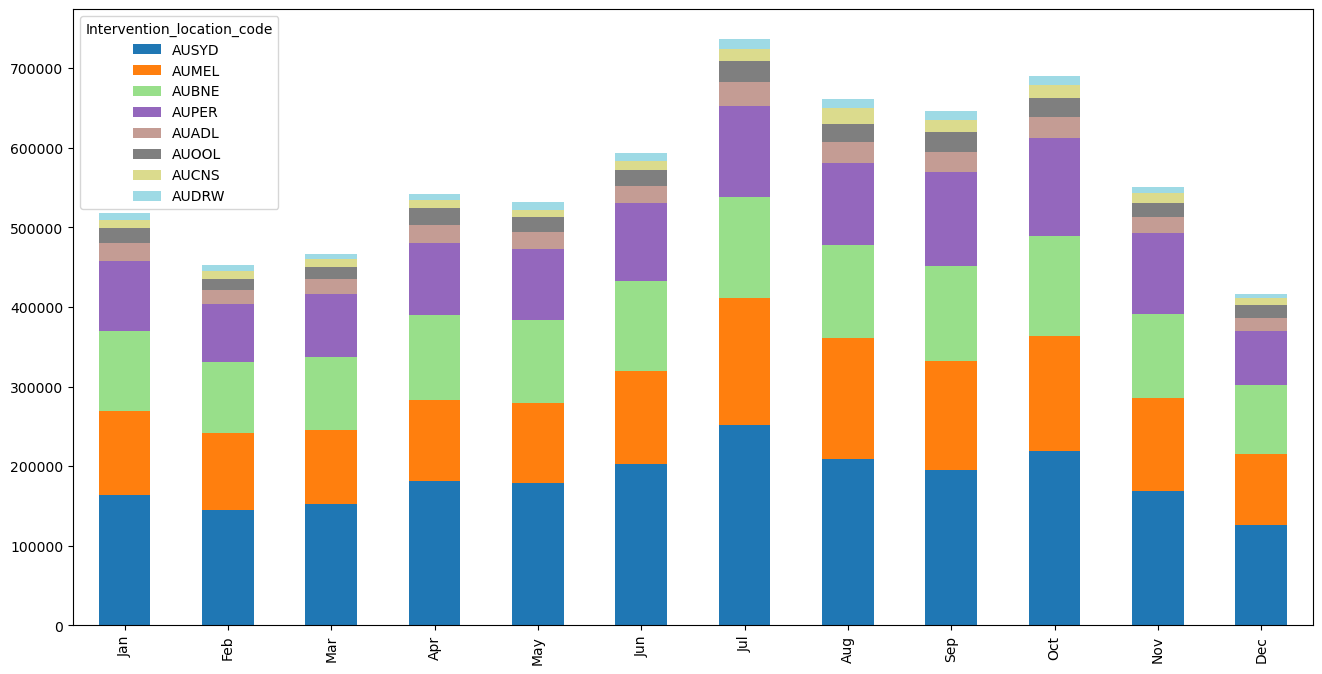

In [55]:
ti_df.groupby(['Intervention_location_code', pd.to_datetime(ti_df['Intervention_date']).dt.month], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention_date": ""}).\
    rename(columns={1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}).\
    sort_values(by='Jan', ascending=False).head(8).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

Evident from the headcount (i.e., the count of distinct officers) is that some are unavailable in Dec, mostly in Sydney and Meilbourne, possibly due the unaccounted Dec 2024:

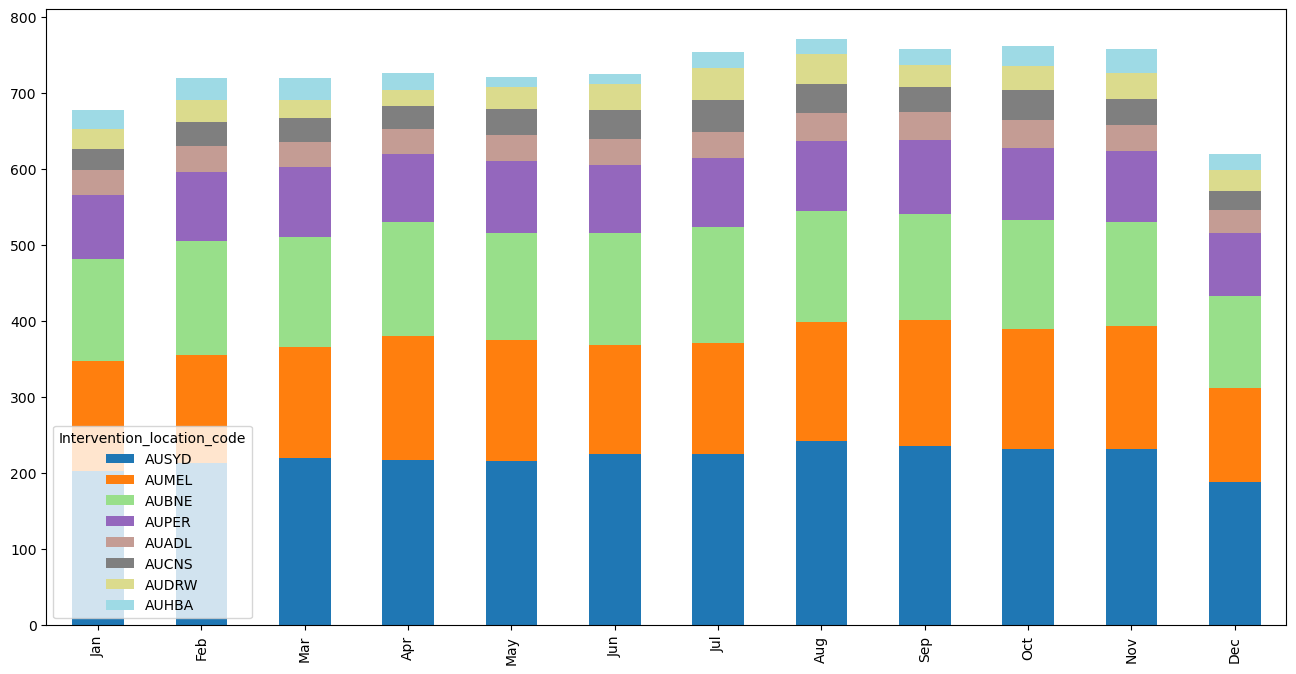

In [56]:
ti_df.groupby(['Intervention_location_code', pd.to_datetime(ti_df['Intervention_date']).dt.month], observed=True)\
    ['Intervention_officer_ID'].nunique().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention_date": ""}).\
    rename(columns={1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}).\
    sort_values(by='Jan', ascending=False).head(8).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

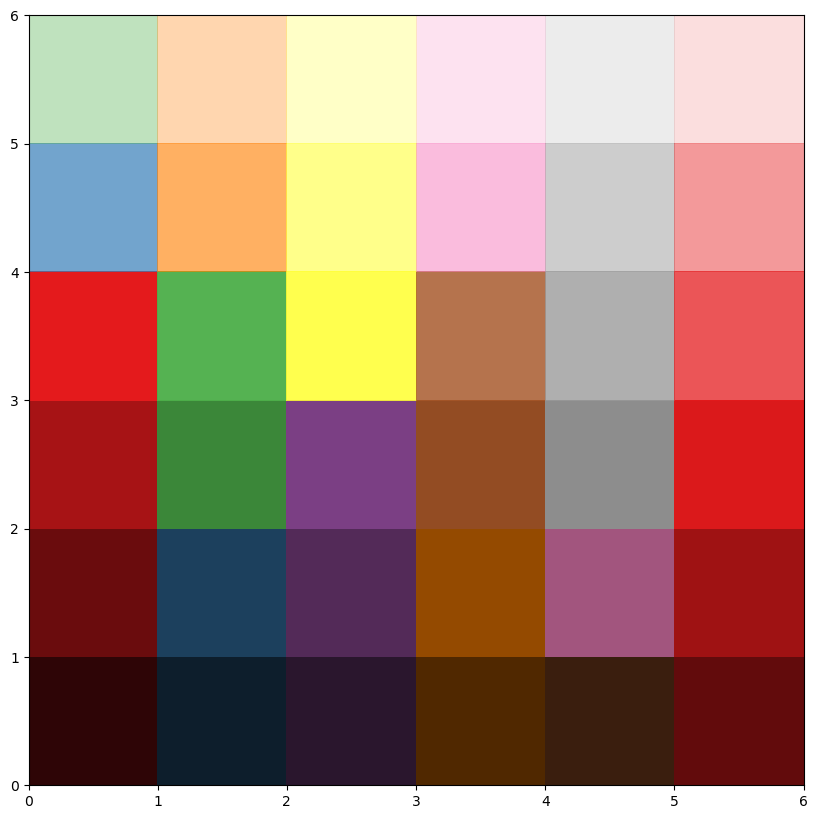

In [57]:
import matplotlib
from matplotlib.colors import ListedColormap
from math import ceil

def generate_colormap(N):
    arr = np.arange(N)/N
    N_up = int(ceil(N/7)*7)
    arr.resize(N_up)
    arr = arr.reshape(7,N_up//7).T.reshape(-1)
    ret = matplotlib.cm.Set1(arr)
    n = ret[:,3].size
    a = n//2
    b = n-a
    for i in range(3):
        ret[0:n//2,i] *= np.arange(0.2,1,0.8/a)
    ret[n//2:,3] *= np.arange(1,0.1,-0.9/b)
#     print(ret)
    return ret

N = 6
H = np.arange(N*N).reshape([N,N])
fig = plt.figure(figsize=(10, 10))
ax = plt.pcolor(H, cmap=ListedColormap(generate_colormap(N*N)))

Monthly timeseries of interventions, restricted to the top dozen method sequences, note the sudden rise of method sequence 2.0 (Rover) in recent months:

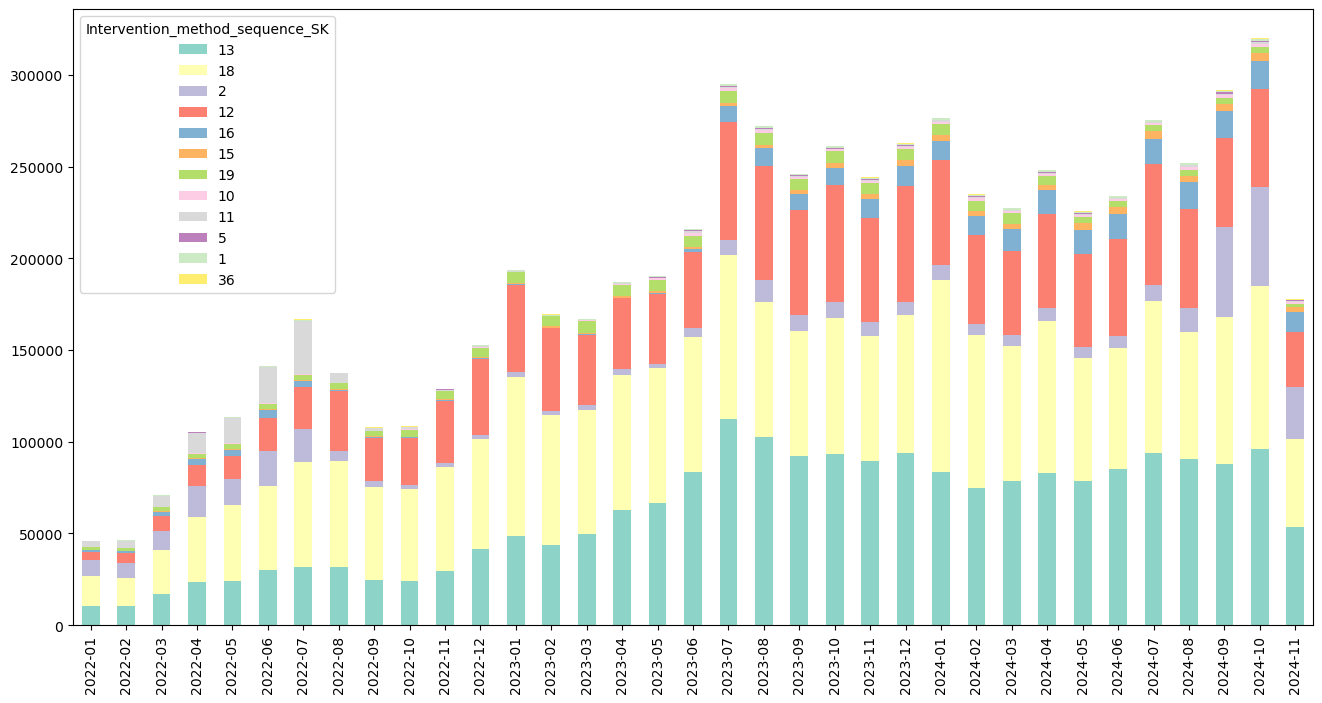

In [58]:
ti_df.groupby(['Intervention_method_sequence_SK', pd.to_datetime(ti_df['Intervention_date']).dt.to_period("M")])\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention_date": ""}).\
    sort_values(by='2024-10', ascending=False).head(12).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap='Set3');
#   T.plot(kind="bar", figsize=(28, 14), stacked=True, colormap=ListedColormap(generate_colormap(36)));

A similar monthly breakdown ny intervention outcome. Note above that method sequence 11.0 (Marshall) was relatively common before Sep 2022. It seems that this was producing a material number of 445290001 ("Refer biosecurity risk") outcomes in the same period: 

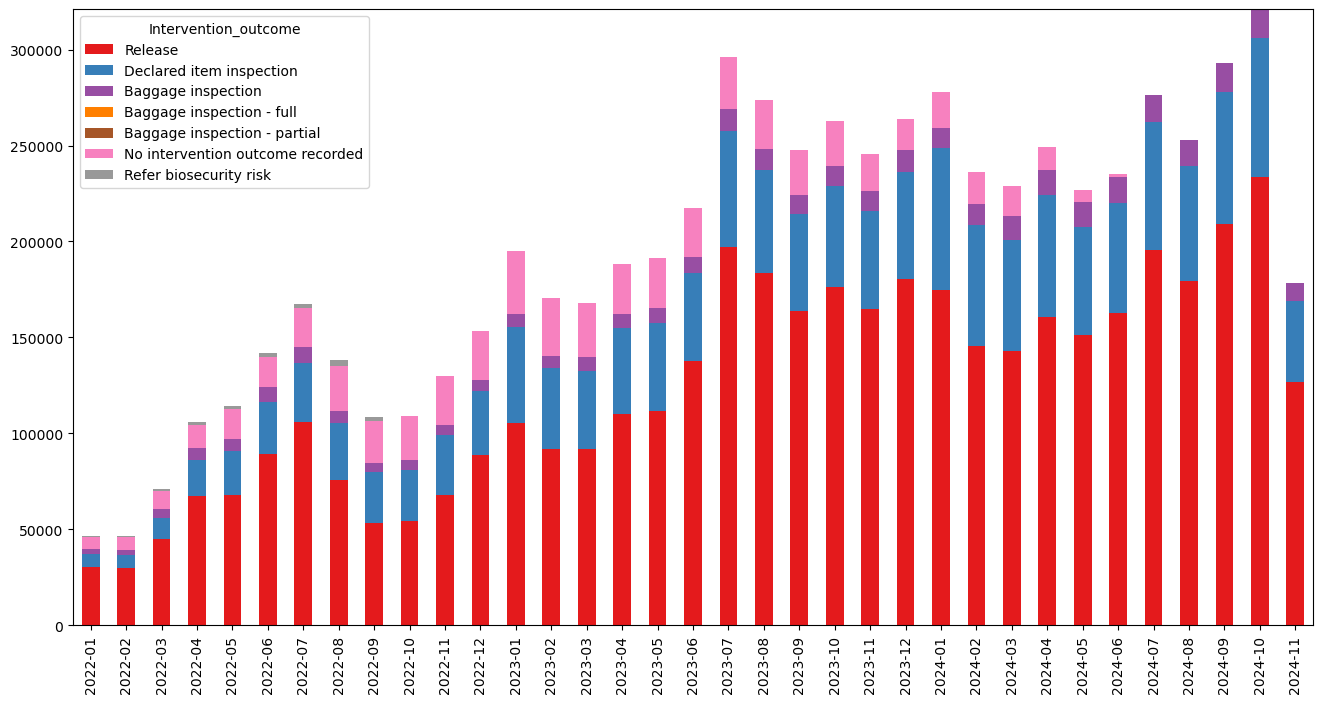

In [59]:
ti_df.groupby(['Intervention_outcome', pd.to_datetime(ti_df['Intervention_date']).dt.to_period("M")], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention_date": ""}).\
    sort_values(by='2024-10', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="Set1");

The number of "officer-days" in a month timeseries:

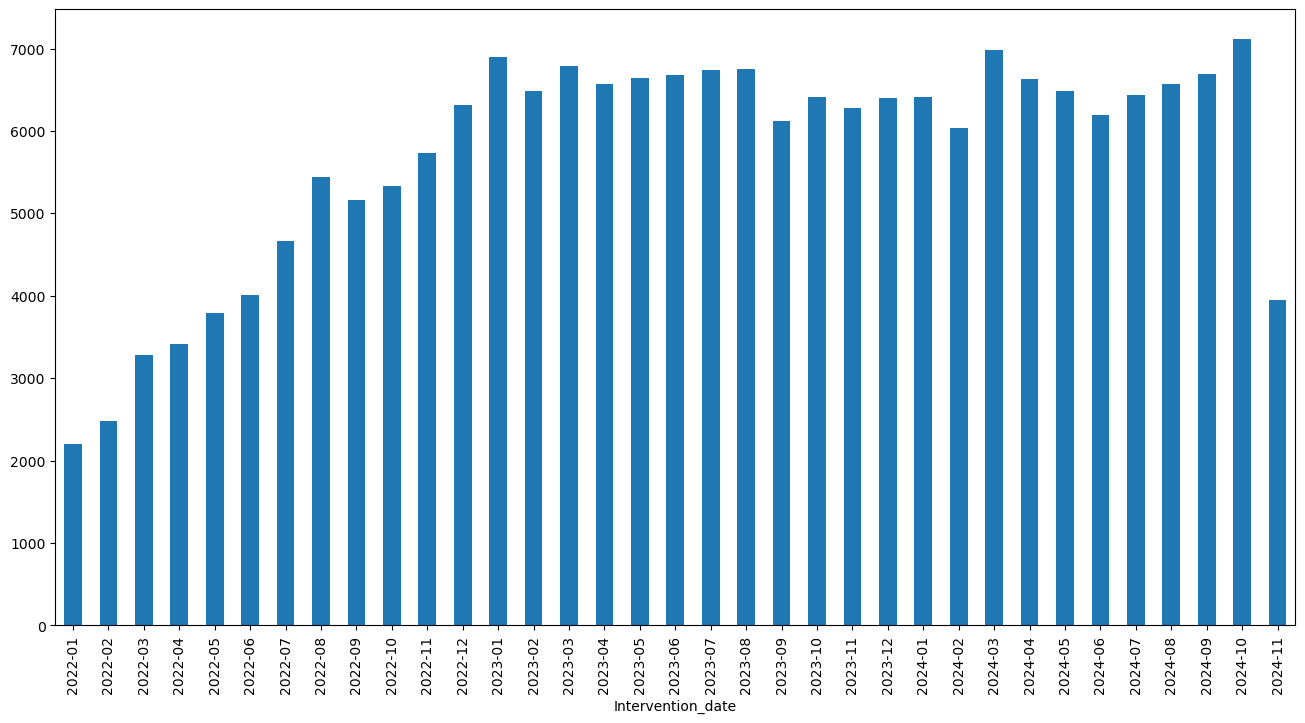

In [60]:
ti_df[['Intervention_date', 'Intervention_officer_ID']].drop_duplicates().\
    groupby(pd.to_datetime(ti_df['Intervention_date']).dt.to_period("M"))\
    ['Intervention_officer_ID'].count().fillna(0).astype("int").\
    plot(kind="bar", figsize=(16, 8), stacked=True);

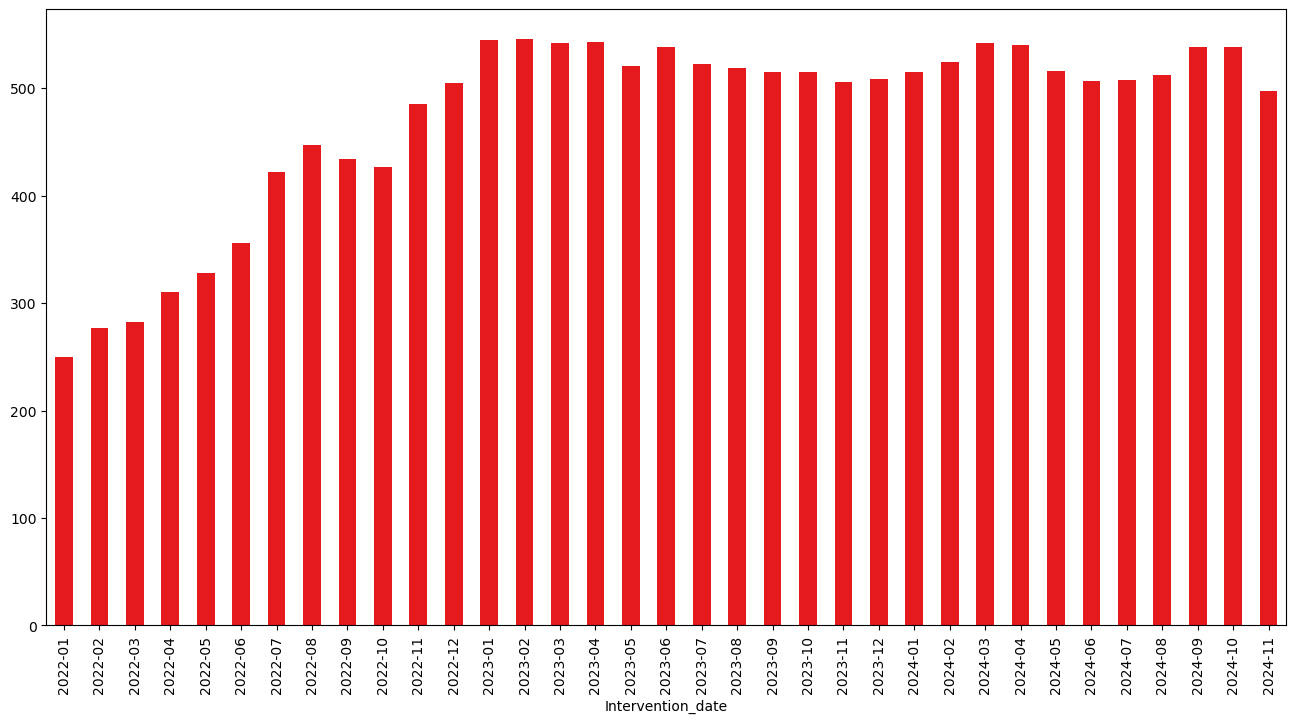

In [61]:
ti_df[['Intervention_date', 'Intervention_officer_ID']].drop_duplicates()
ti_df.groupby(pd.to_datetime(ti_df['Intervention_date']).dt.to_period("M"))\
    ['Intervention_officer_ID'].nunique().fillna(0).astype("int").\
    plot(kind="bar", figsize=(16, 8), stacked=True, colormap="Set1");

So 280,000 monthly interventions / 7,000 officer-days equals about 40 interventions per day per officer, which is about 5 interventions per hour per officer. 

Investigating possible age bias. First, fix negative and 101+ age values:

In [62]:
ti_df['Traveller_age'] = np.abs(ti_df.Traveller_age)
# ti_df.loc[ti_df['Traveller_age'] > 101, 'Traveller_age'] = np.nan
ti_df['Traveller_age'] = ti_df['Traveller_age'].mask(ti_df['Traveller_age'] > 101, np.nan)

In [63]:
ti_df.Traveller_age.describe().to_frame()

,Traveller_age
count,6.398383e+06
mean,4.092162e+01
std,1.935231e+01
min,0.000000e+00
25%,2.700000e+01
50%,4.000000e+01
75%,5.600000e+01
max,1.010000e+02


Bin the age into 7 categories plus "missing":

In [64]:
bins = [0, 15, 25, 35, 45, 55, 65, 101]
group = ["<15", "15-24", "25-34", "35-44", "45-54", "55-64", "65+"]
ti_df['Age_group'] = pd.cut(ti_df['Traveller_age'], bins=bins, labels=group, right=False).cat.add_categories('missing').fillna('missing')

No evidence of age bias, all age groups represented almost equally (although this may be at odds with the age distribution of all travellers, which likely peaks around 25-55):

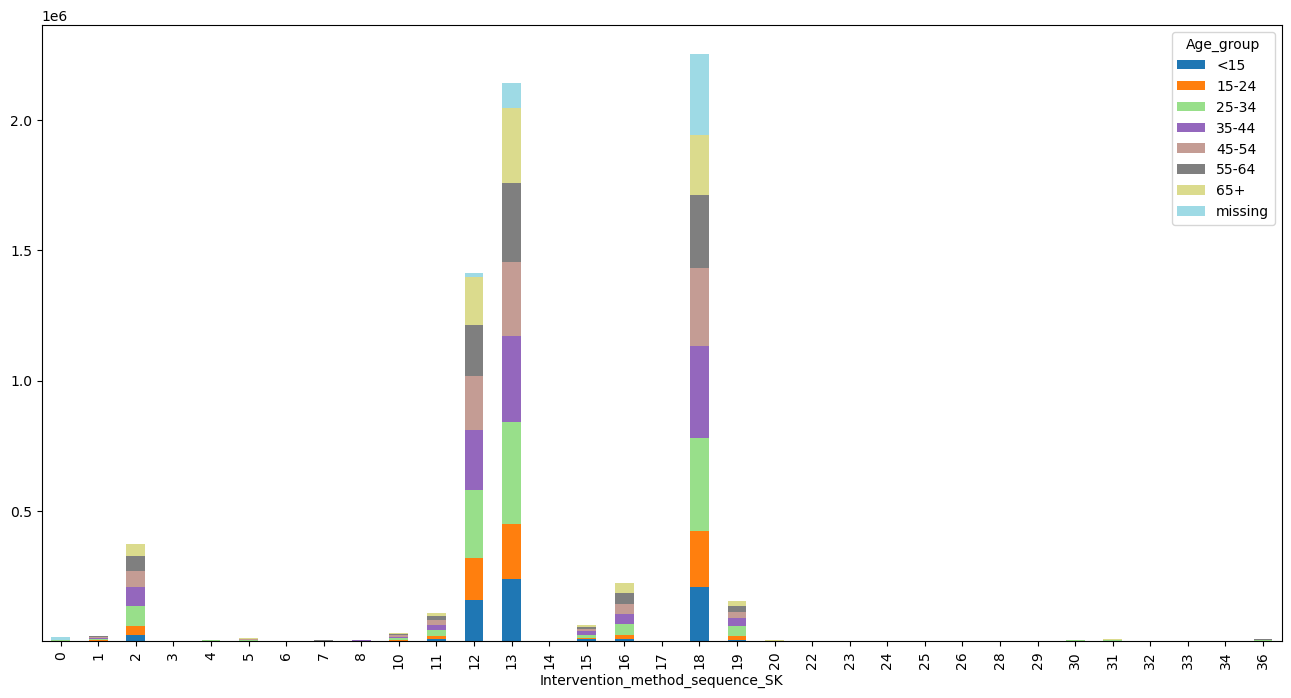

In [65]:
ti_df.groupby(['Age_group', 'Intervention_method_sequence_SK'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by='Age_group', ascending=True).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

The most common ntervention outcomes 445290000 (Release) and 445290003 (Declared item inspection) follow a similar uniform pattern, while 445290002 (Baggage inspection) appears to have a peak in the 25-34 group:

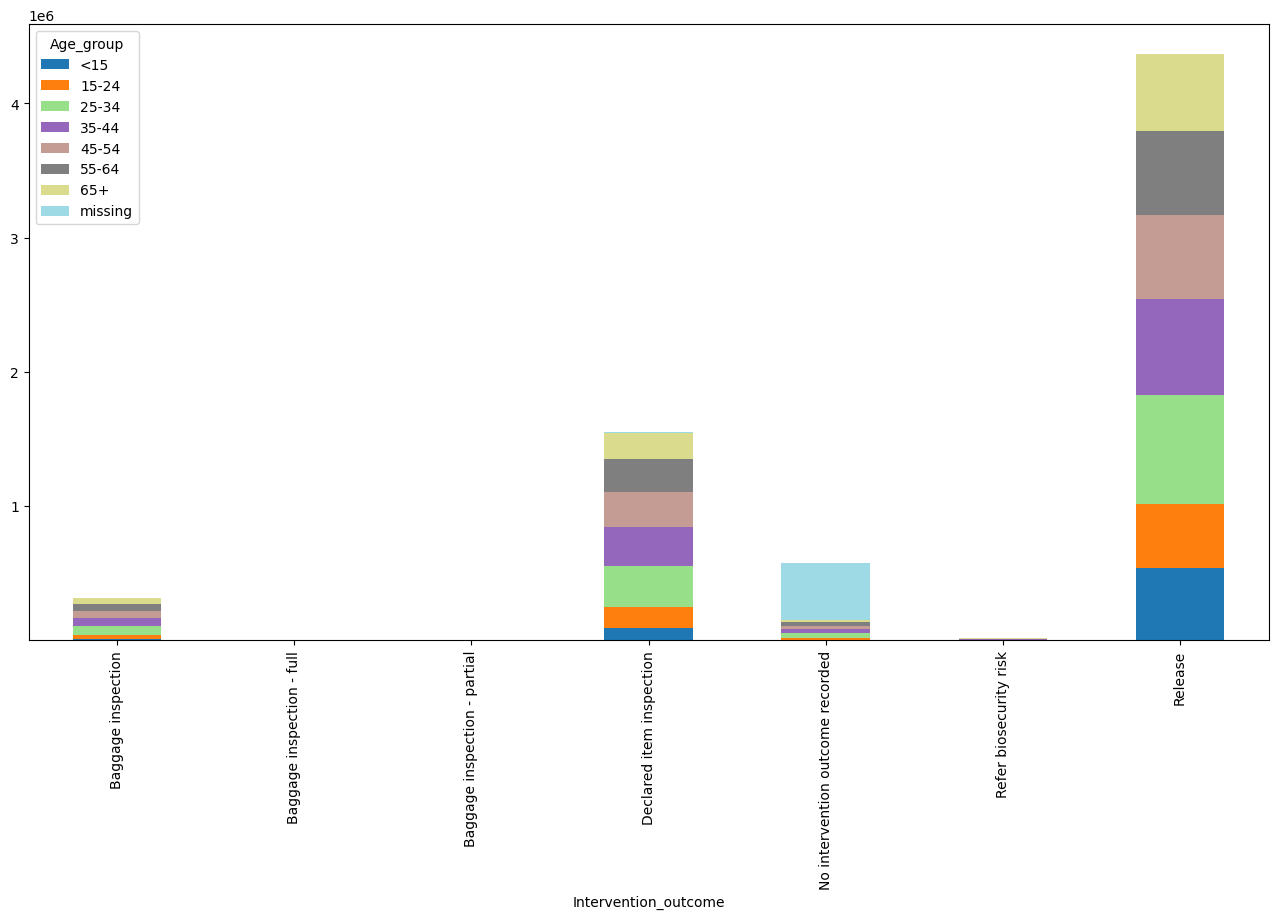

In [66]:
ti_df.groupby(['Age_group', 'Intervention_outcome'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by='Age_group', ascending=True).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

Finally, there is not much variation location-wise:

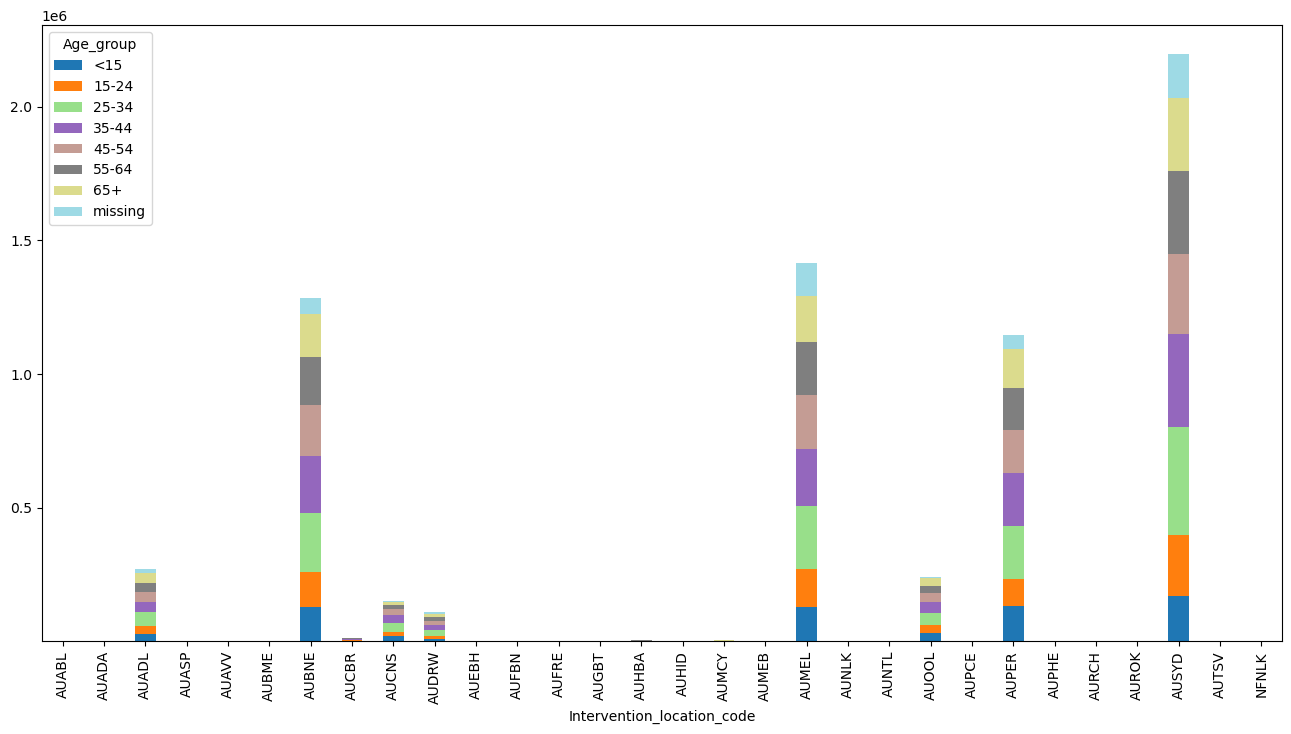

In [67]:
ti_df.groupby(['Age_group', 'Intervention_location_code'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by='Age_group', ascending=True).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

In Sydney and Melbourne the majority of interventions are focussed on foreign passport holders, unlike at other locations: 

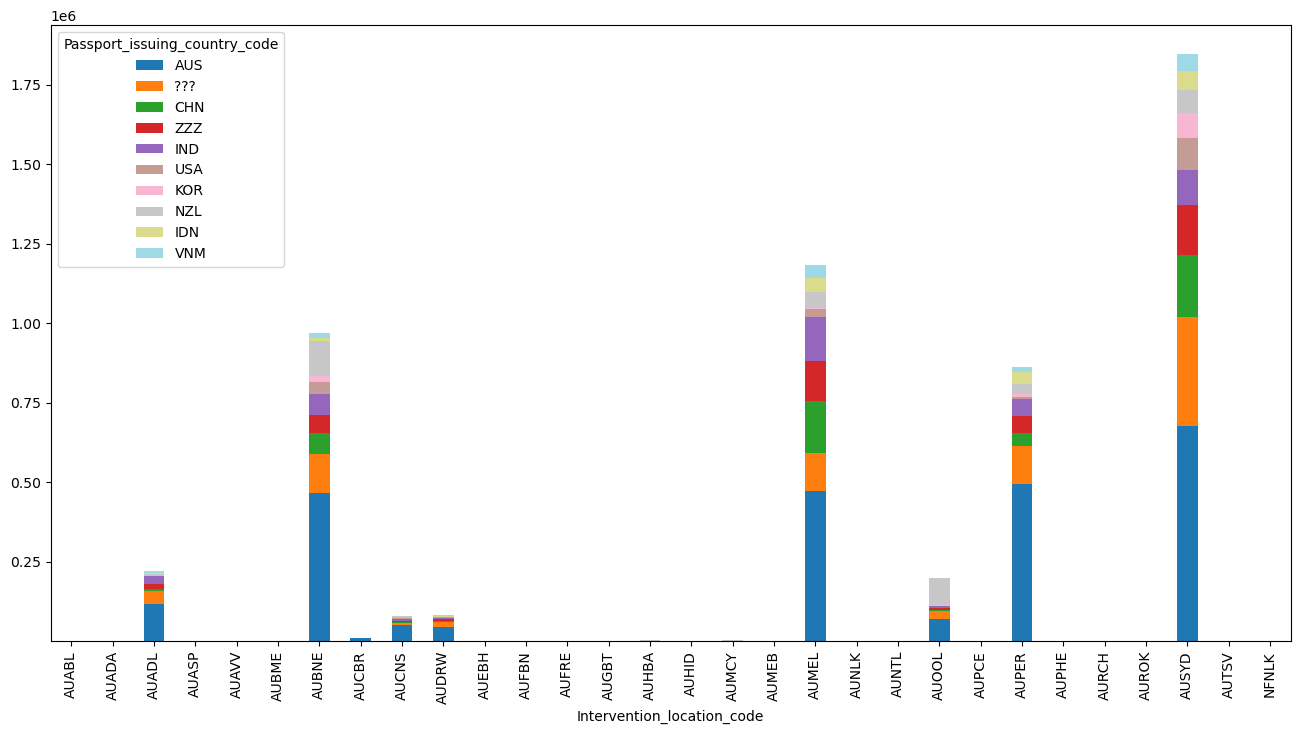

In [68]:
ti_df.groupby(['Passport_issuing_country_code', 'Intervention_location_code'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by='AUSYD', ascending=False).head(10).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

For CHN, IND, USA, IDN passport holders 12.0 and 13.0 (dogs and 2D X-rays) are more common than 18.0 (Inspection bench), which is more commong for AUS and NZL passport holders.

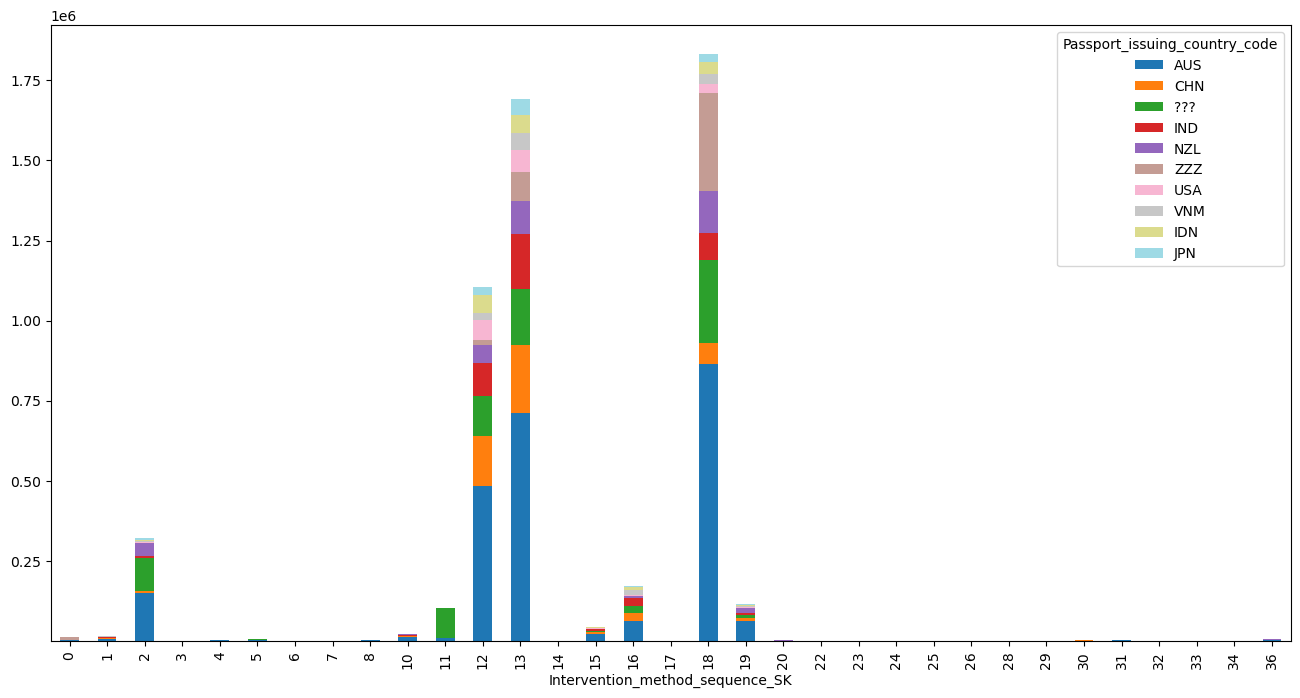

In [69]:
ti_df.groupby(['Passport_issuing_country_code', 'Intervention_method_sequence_SK'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by=13.0, ascending=False).head(10).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

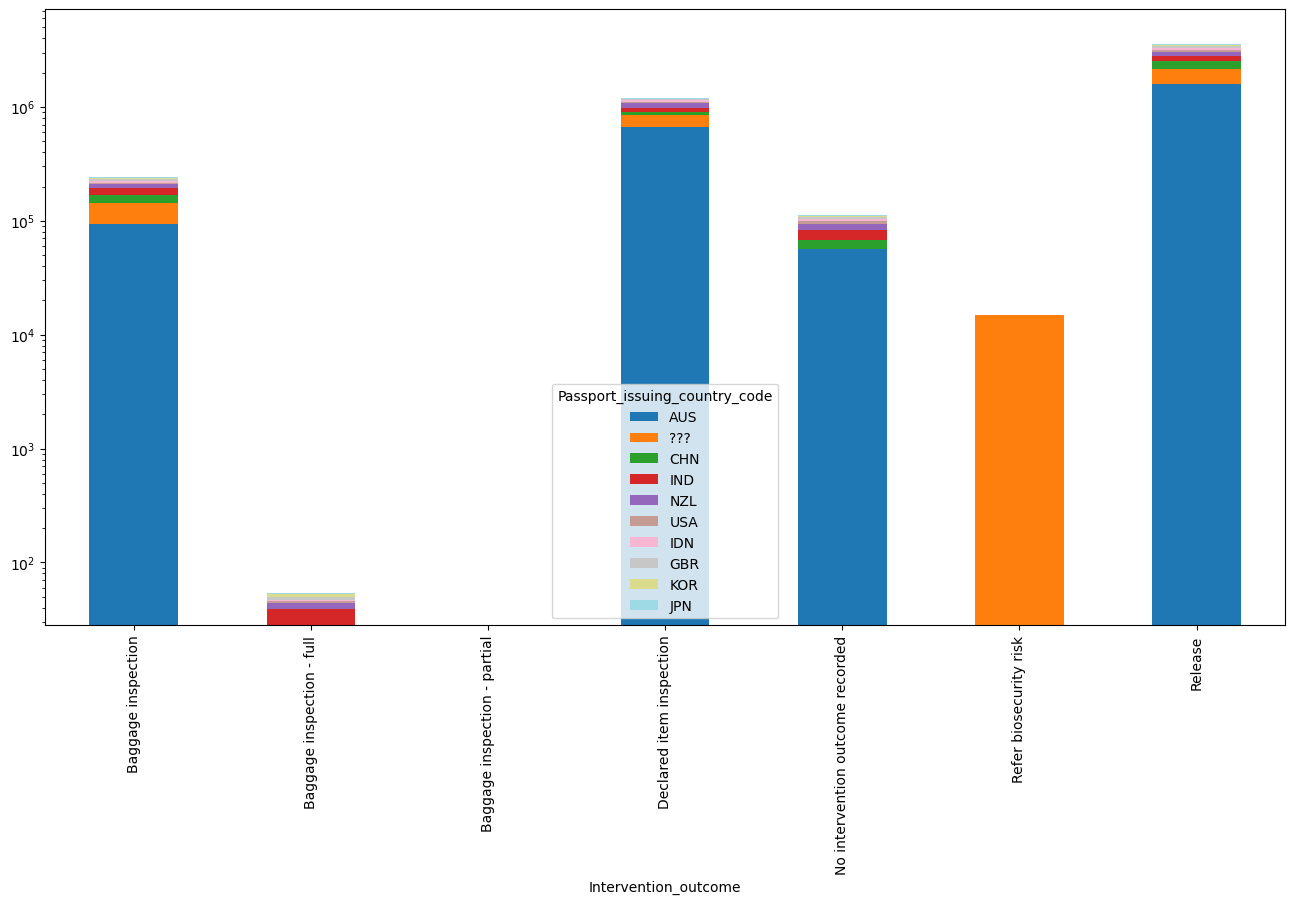

In [70]:
ti_df.groupby(['Passport_issuing_country_code', 'Intervention_outcome'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by="Release", ascending=False).head(10).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", log=True);

Evidently, for the ouctome 445290001 "Refer biosecurity risk", the passport country is almost never recorded (except very rarely in Brisbane):

In [71]:
ti_df.query('Intervention_outcome == "Refer biosecurity risk"')[['Intervention_location_code', 'Passport_issuing_country_code']].value_counts().head(15)

Intervention_location_code  Passport_issuing_country_code
AUSYD                       ???                              5094
AUPER                       ???                              2700
AUBNE                       ???                              2681
AUMEL                       ???                              2436
AUADL                       ???                               717
AUOOL                       ???                               526
AUDRW                       ???                               445
AUCNS                       ???                               179
AUHBA                       ???                                10
AUBNE                       AUS                                 3
NFNLK                       ???                                 3
AUBNE                       NZL                                 2
AUAVV                       ???                                 2
AUBNE                       NPL                                 1
AUCBR             

The majority of the biosecurity risk referrals arrive via Singapore, regardless of the destination:

In [72]:
ti_df.query('Intervention_outcome == "Refer biosecurity risk"')[['Intervention_location_code', 'Flight_number']].value_counts().head(15)

Intervention_location_code  Flight_number
AUSYD                       XXXX             816
AUBNE                       XXXX             533
AUPER                       SQ223            506
                            XXXX             483
AUMEL                       XXXX             482
AUPER                       SQ225            426
AUBNE                       SQ245            340
                            SQ255            340
AUADL                       SQ279            264
AUBNE                       SQ235            230
AUMEL                       UL604            217
AUSYD                       SQ231            216
                            VN773            212
                            AI302            199
                            SQ241            197
Name: count, dtype: int64

No evidence of gender bias in intervention method sequences nor location:

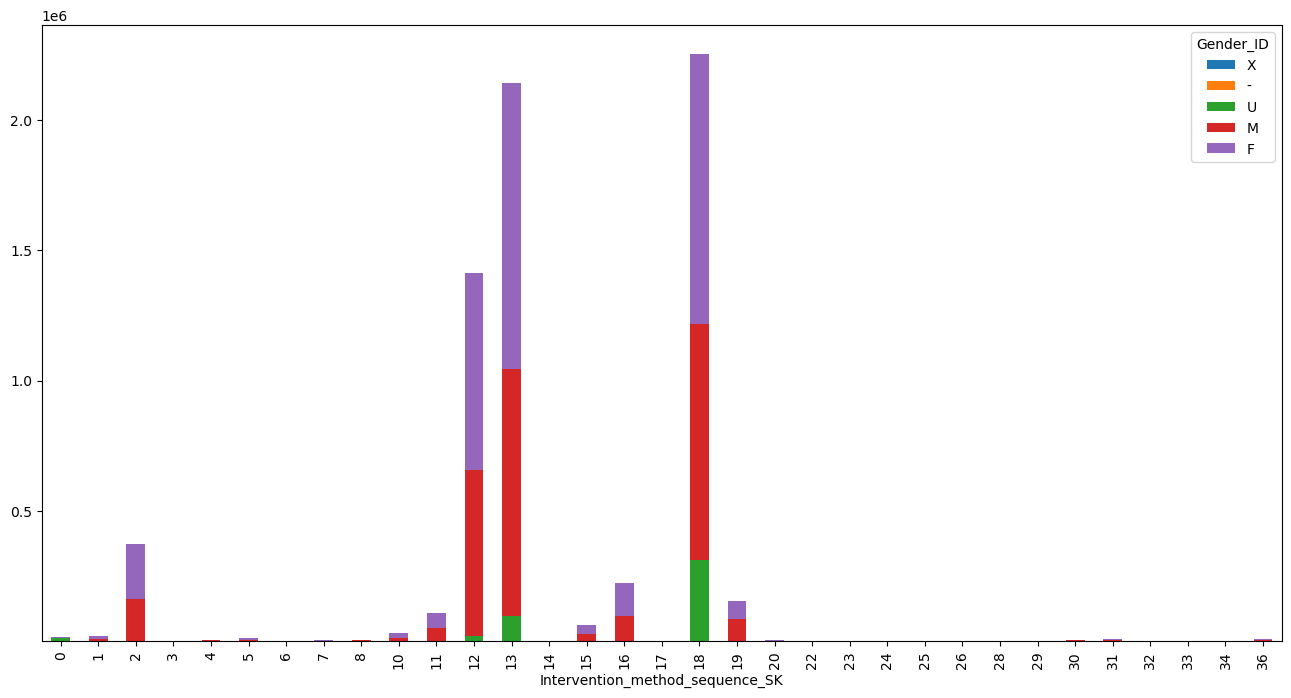

In [73]:
ti_df.groupby(['Gender_ID', 'Intervention_method_sequence_SK'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by=13.0, ascending=True).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True);

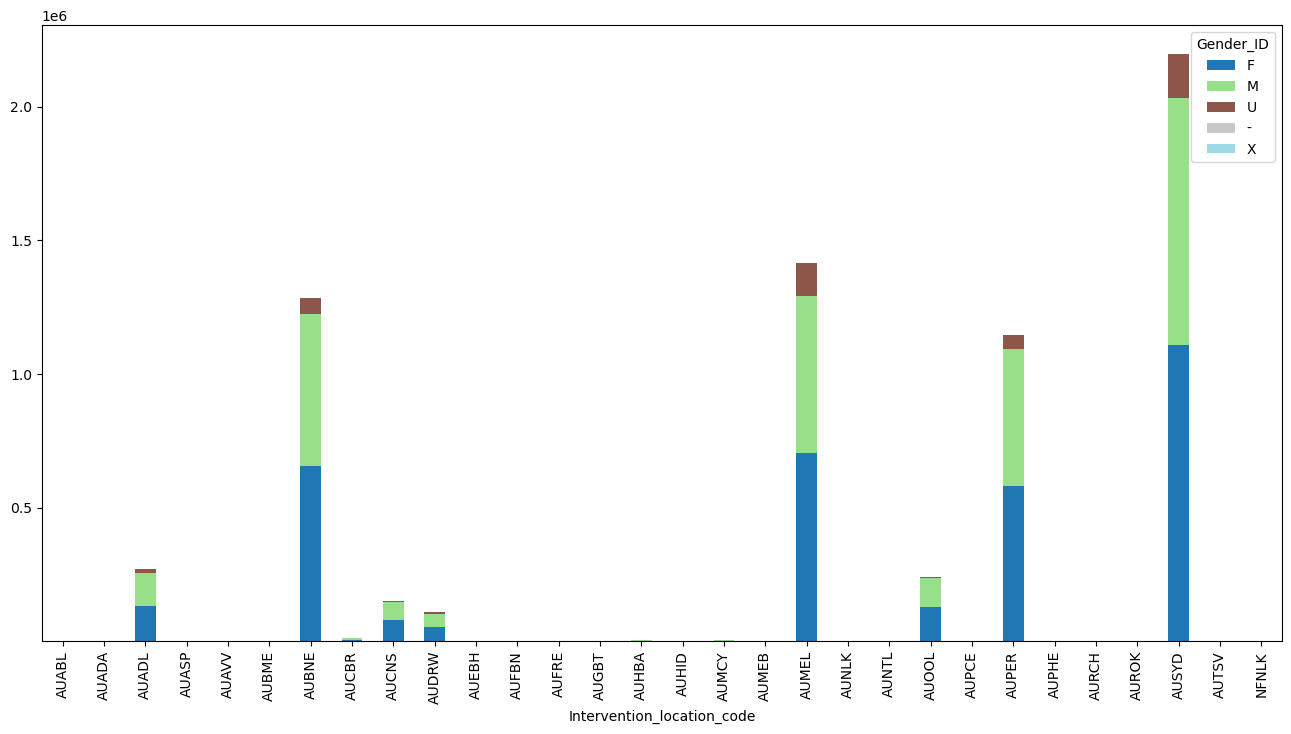

In [74]:
ti_df.groupby(['Gender_ID', 'Intervention_location_code'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by='AUSYD', ascending=False).head(10).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

There is an interesting correlation between the intervention method sequence and intervention outcome. For the method sequences 2, 11 and 12 the outcome is apparently always 445290000 "Release", while for 13 a small fraction results in the 445290001 (Refer biosecurity risk outcome). For the method sequence 18 the most common outcome is 445290003 "Declared item inspection", which is also the case for 10 and 16:

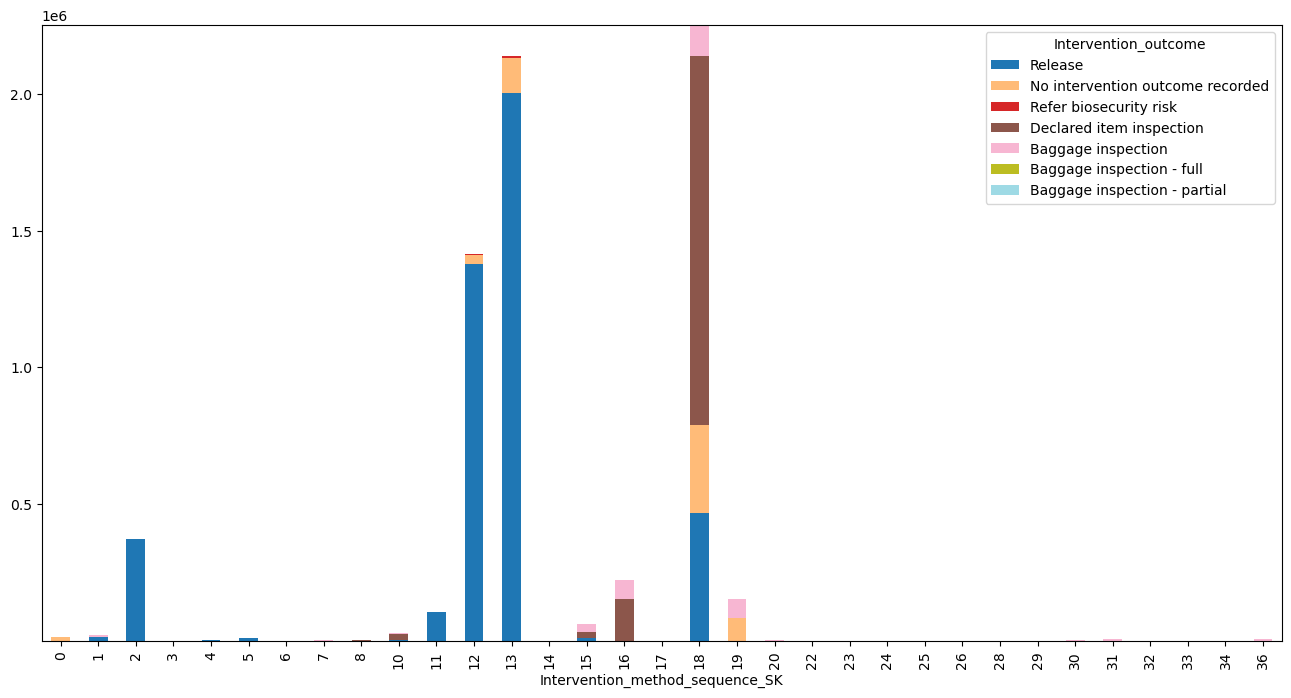

In [75]:
ti_df.groupby(['Intervention_outcome', 'Intervention_method_sequence_SK'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by=13.0, ascending=False).head(10).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

An alternative view of the same data (log y-axis for clarity). The 13.0 (2D X-ray) and 1.0 (Not specified) are the only significant contributions leading to 445290001 (Biosecurity risk referrals)

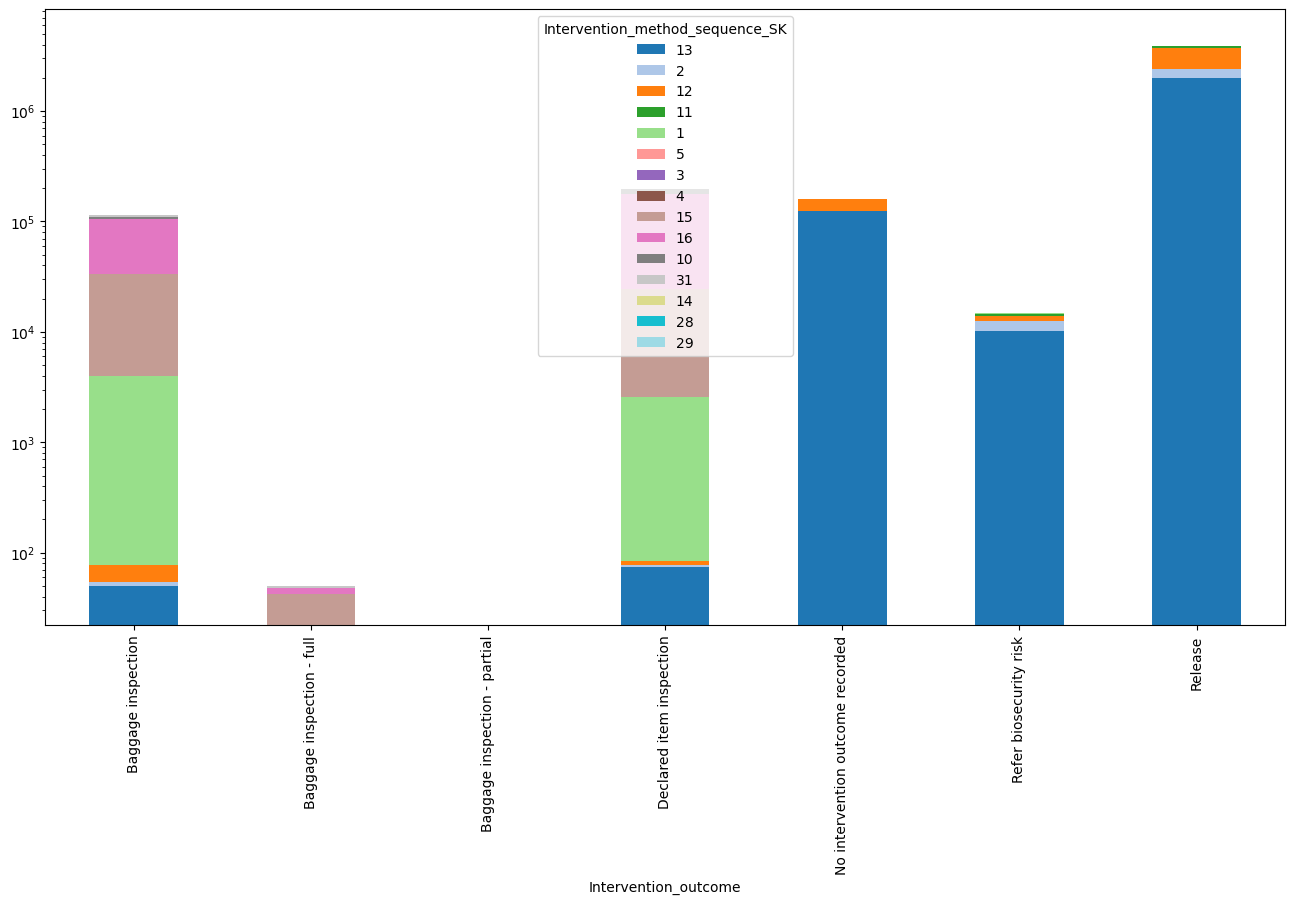

In [76]:
ti_df.groupby(['Intervention_method_sequence_SK', 'Intervention_outcome'], observed=True)\
    ['Intervention_ID'].count().unstack().fillna(0).astype("int").\
    sort_values(by="Refer biosecurity risk", ascending=False).head(15).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", log=True);

In [77]:
ti_df['Non_specified_channel_sequence'].value_counts()

Non_specified_channel_sequence
                                                                                                   6808141
Detector dog > Detector dog                                                                           5428
Inspection bench > 2D X-Ray                                                                           3207
Detector dog > Detector dog > Inspection bench                                                        2104
Detector dog > 2D X-Ray                                                                               1214
                                                                                                    ...   
Inspection bench > Marshal > Inspection bench                                                            1
Inspection bench > Inspection bench > 2D X-Ray > Inspection bench > 2D X-Ray > Inspection bench          1
Inspection bench > Inspection bench > 2D X-Ray                                                           1
2D X-R

In [78]:
ti_df.query('Non_specified_channel_sequence.str.len() > 0')[['Intervention_method_sequence_SK', 'Non_specified_channel_sequence']].value_counts()

Intervention_method_sequence_SK  Non_specified_channel_sequence                                                                 
1                                Detector dog > Detector dog                                                                        5428
                                 Inspection bench > 2D X-Ray                                                                        3207
                                 Detector dog > Detector dog > Inspection bench                                                     2104
                                 Detector dog > 2D X-Ray                                                                            1214
                                 Inspection bench > Detector dog                                                                    1063
                                                                                                                                    ... 
                                 Inspection bench

In [79]:
ti_df.query('Non_specified_channel_sequence.str.len() > 0')[['Intervention_outcome', 'Non_specified_channel_sequence']].value_counts()

Intervention_outcome      Non_specified_channel_sequence                                    
Release                   Detector dog > Detector dog                                           5419
                          Inspection bench > 2D X-Ray                                           3084
Baggage inspection        Detector dog > Detector dog > Inspection bench                        1498
Release                   Detector dog > 2D X-Ray                                               1207
                          Inspection bench > Detector dog                                        791
                                                                                                ... 
Declared item inspection  2D X-Ray > Inspection bench > Survey > 2D X-Ray > Inspection bench       1
                          2D X-Ray > Rover                                                         1
                          2D X-Ray > Survey > 2D X-Ray > Inspection bench                          

In [80]:
ims_df = pd.read_csv("./Intervention_Method_Sequence.csv")
ims_df['Intervention_method_sequence'] = ims_df['Intervention_method_sequence'].str.replace("X-ray", "X-Ray")

In [81]:
ti_df = pd.merge(ti_df, ims_df, on='Intervention_method_sequence_SK', how="inner", suffixes=(None, None))

with pd.option_context("display.max_columns", None):
    display(ti_df.sample(10))

,Source_system_code,Intervention_ID,Intervention_date,Creation_date,Movement_type_code,Flight_number,Vessel_name,Is_declarant,Passport_issuing_country_code,Intervention_officer_ID,Intervention_location_code,Intervention_method_sequence_SK,Non_specified_channel_sequence,Detector_dog_SK,Is_survey,Traveller_age,Gender_ID,Detector_dog_handler_ID,Is_automated_profile,Comment,Intervention_outcome,Age_group,Sequence_ID,Has_survey,Intervention_method_sequence,Intervention_method_1,Intervention_method_2,Intervention_method_3,Intervention_method_4,Final_intervention_method,Is_detector_dog,Is_X_ray,Is_inspection
1345442,T,INT-12837870-G7Y3X,2023-09-09,2023-09-09,A,EK434,,False,AUS,7967,AUBNE,12,,237,False,1.0,F,584,False,,Release,<15,12,0,Detector dog,Detector dog,Finished,Finished,Finished,Detector dog,1,0,0
4253513,T,INT-12009305-R0T3C,2023-05-26,2023-05-26,A,CX171,,True,CHN,7795,AUPER,18,,0,False,72.0,F,0,False,,Baggage inspection,65+,18,0,Inspection bench,Inspection bench,Finished,Finished,Finished,Inspection bench,0,0,1
969654,M,NA22022424,2022-06-14,2022-06-14,A,LA801,,False,AUS,2121,AUSYD,19,,0,True,21.0,M,0,False,,No intervention outcome recorded,15-24,1,1,Survey,Survey,Finished,Finished,Finished,Survey,0,0,0
5864987,T,INT-11809018-X7T1S,2023-04-22,2023-04-22,A,GS7939,,False,CHN,7979,AUSYD,13,,0,False,41.0,F,0,True,,Release,35-44,13,0,2D X-Ray,2D X-ray,Finished,Finished,Finished,2D X-ray,0,1,0
623469,T,INT-10055472-F3X1K,2022-01-11,2022-01-11,A,AA73,,False,???,2674,AUSYD,13,,0,False,32.0,M,0,False,,Release,25-34,13,0,2D X-Ray,2D X-ray,Finished,Finished,Finished,2D X-ray,0,1,0
2478142,T,INT-15294583-M5J0K,2024-07-16,2024-07-16,A,ID6007,,False,GBR,7817,AUPER,1,Detector dog > 2D X-Ray,314,False,43.0,M,10348,False,,Release,35-44,0,0,Not a specified intervention method sequence,NaN,Finished,Finished,Finished,NaN,0,0,0
1384538,T,INT-15261091-N0R0C,2024-07-13,2024-07-13,A,QF44,,False,AUS,6042,AUSYD,13,,0,False,31.0,M,0,True,,Release,25-34,13,0,2D X-Ray,2D X-ray,Finished,Finished,Finished,2D X-ray,0,1,0
4900895,T,INT-11885401-L0Q2C,2023-05-05,2023-05-05,A,D7236,,True,VNM,1527,AUPER,18,,0,False,26.0,F,0,False,,Declared item inspection,25-34,18,0,Inspection bench,Inspection bench,Finished,Finished,Finished,Inspection bench,0,0,1
5085139,T,INT-15859771-S2T0M,2024-09-18,2024-09-19,A,SQ215,,True,CHN,1526,AUPER,2,,0,False,27.0,F,0,False,,Release,25-34,2,0,Rover,Rover,Finished,Finished,Finished,Rover,0,0,0
5527287,T,INT-15997982-J1L0F,2024-10-02,2024-10-02,A,MF803,,False,CHN,106097,AUMEL,13,,0,False,54.0,M,0,False,,Release,45-54,13,0,2D X-Ray,2D X-ray,Finished,Finished,Finished,2D X-ray,0,1,0


In [82]:
ti_df['Intervention_method_sequence'] = ti_df['Intervention_method_sequence'].mask(ti_df['Intervention_method_sequence'].str.startswith("Not a specified"), ti_df['Non_specified_channel_sequence'])

In [83]:
seq_set = set()

for seq_lst in ti_df['Intervention_method_sequence'].str.split(" > "):
    seq_set = seq_set.union(set(seq_lst))

seq_set

{'',
 '2D X-Ray',
 '3D X-Ray',
 'Detector dog',
 'Inspection bench',
 'Marshal',
 'Rover',
 'Survey'}

In [84]:
ti_df = ti_df.assign(sequence_count=ti_df['Intervention_method_sequence'].str.split(" > ").apply(lambda x: len(x)))

In [85]:
ti_df.query('Intervention_method_sequence.str.len() == 0')

,Source_system_code,Intervention_ID,Intervention_date,Creation_date,Movement_type_code,Flight_number,Vessel_name,Is_declarant,Passport_issuing_country_code,Intervention_officer_ID,...,Intervention_method_sequence,Intervention_method_1,Intervention_method_2,Intervention_method_3,Intervention_method_4,Final_intervention_method,Is_detector_dog,Is_X_ray,Is_inspection,sequence_count
719817,T,INT-10917456-X7Q7K,2022-10-20,2022-10-20,A,QF122,,True,???,1447,...,,NaN,Finished,Finished,Finished,NaN,0,0,0,1
735615,T,INT-10916854-M4V2L,2022-10-20,2022-10-20,A,SQ227,,True,???,1497,...,,NaN,Finished,Finished,Finished,NaN,0,0,0,1
746027,T,INT-10916865-S4F6B,2022-10-20,2022-10-20,A,SQ227,,True,???,1497,...,,NaN,Finished,Finished,Finished,NaN,0,0,0,1
764273,T,INT-10916861-Z0H1V,2022-10-20,2022-10-20,A,SQ227,,True,???,1497,...,,NaN,Finished,Finished,Finished,NaN,0,0,0,1
764277,T,INT-10917264-M4S5H,2022-10-20,2022-10-20,A,TR18,,True,???,1497,...,,NaN,Finished,Finished,Finished,NaN,0,0,0,1
772166,T,INT-10916858-Q1M4K,2022-10-20,2022-10-20,A,SQ227,,False,???,1497,...,,NaN,Finished,Finished,Finished,NaN,0,0,0,1
774862,T,INT-10916351-P9R8L,2022-10-20,2022-10-20,A,JQ128,,True,???,4988,...,,NaN,Finished,Finished,Finished,NaN,0,0,0,1


In [86]:
from collections import Counter

meth_count = Counter(k for k_lst in ti_df['Intervention_method_sequence'].str.split(" > ") for k in k_lst)
meth_count, sum(v for v in meth_count.values())

(Counter({'Inspection bench': 2594263,
          '2D X-Ray': 2394705,
          'Detector dog': 1503909,
          'Rover': 424548,
          'Survey': 171782,
          'Marshal': 108955,
          '3D X-Ray': 411,
          '': 7}),
 7198580)

In [87]:
Counter(ti_df['Intervention_method_sequence'].str.split(" > ").iloc[6814883])

Counter({'2D X-Ray': 1})

In [88]:
ti_df['sequence_count'].sum()

7198580

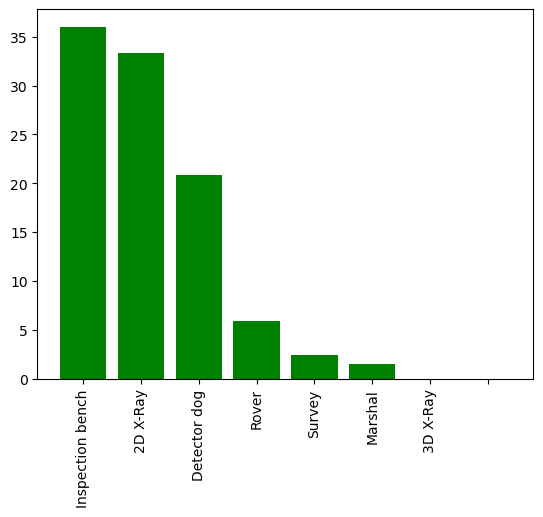

In [89]:
ddic = {k: round(v / 7198580 * 100.0, 1) for k, v in sorted(meth_count.items(), key=lambda x: x[1], reverse=True)}
plt.bar(list(ddic.keys()), ddic.values(), color='g')
plt.xticks(rotation='vertical')
plt.show();

Limiting above counts to the FY 2023/24:

In [90]:
fy_meth_count = Counter(k for k_lst in ti_df.loc[ti_df['Intervention_date'].between(pd.to_datetime("2023-07-01").date(), pd.to_datetime("2024-06-30").date()), 'Intervention_method_sequence'].str.split(" > ")
                        for k in k_lst
                       )
fy_meth_count, sum(v for v in fy_meth_count.values())

(Counter({'2D X-Ray': 1213024,
          'Inspection bench': 1117680,
          'Detector dog': 723067,
          'Rover': 119002,
          'Survey': 75768,
          'Marshal': 7127,
          '3D X-Ray': 5}),
 3255673)

In [91]:
ti_df.loc[ti_df['Intervention_date'].between(pd.to_datetime("2023-07-01").date(), pd.to_datetime("2024-06-30").date()), 'sequence_count'].sum()

3255673

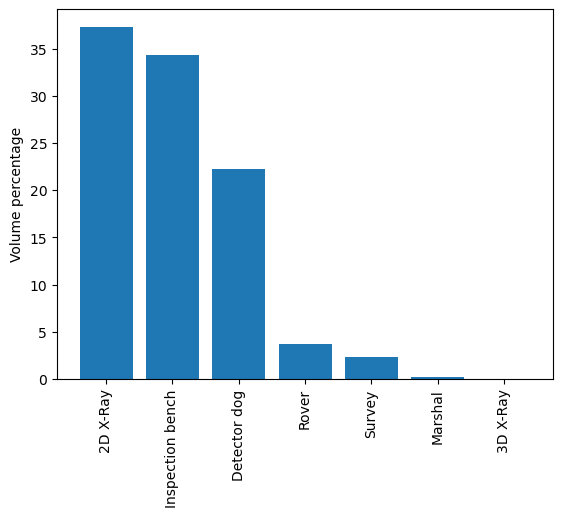

In [92]:
ddic = {k: round(v / 3255673 * 100.0, 1) for k, v in sorted(fy_meth_count.items(), key=lambda x: x[1], reverse=True)}
plt.bar(list(ddic.keys()), ddic.values())
plt.ylabel("Volume percentage")
plt.xticks(rotation='vertical')
plt.show();

### TAMS Intervention Method Event

Note that the Intervention_Method_Event.csv table only captures the 2024 calendar year!

In [93]:
ime_df = pd.read_csv("./Intervention_Method_Event.csv.gz", parse_dates=['Intervention method event start datetime', 'Creation datetime'] )

ime_df.sample(5)

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
1239972,c40f8793-528d-4e1f-befa-1d07985df28a,01d7daa0-49be-451b-8c9a-5f900261d67c,2024-01-24 07:10:29,INT-13937101-W8F5W-2024-01-24 07:11:56,445290003,445290000,NaN,2b15f2f5-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-01-23 20:11:56
2743366,9f83bb06-c1f7-44e9-b130-14f67e401299,7aad72ed-6195-4909-a0d5-d3800189e5a0,2024-01-17 06:56:59,INT-13879771-S2C8M-2024-01-17 07:58:57,445290002,445290000,NaN,0b104b48-8b90-ed11-aad1-002248933f88,b8bb7692-f0cf-eb11-8235-0022481542dd,6f80ccc5-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-01-16 20:58:57
147877,890358b3-0653-4be0-b912-804ee25b11f2,f71134b9-49cc-40ac-8c5a-0b3e1e68855d,2024-12-18 16:32:47,INT-16805159-Z9P4T-2024-12-18 16:36:19,445290003,445290000,NaN,78b3b93c-6565-ed11-9561-0022489338ed,NaN,NaN,NaN,Secondary Examination Area,2024-12-18 05:36:19
2153477,ceb8d336-ef87-4e6a-bd53-ea99fee492ac,265e99bc-0e86-48c8-83a3-a5f25a177b26,2024-04-02 12:12:06,INT-14457193-M3S4M-2024-04-02 12:12:12,445290005,445290003,NaN,436cfa75-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-02 01:12:12
2027828,cac2a35a-f461-4893-825f-2da5fe18a81c,f3a3fc8e-87a0-4772-b989-9c3f15b6366f,2024-11-30 19:42:18,INT-16612389-R9Z9P-2024-11-30 22:42:43,445290003,445290000,NaN,ed362a8e-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-30 11:42:43


There exist records with identical 'Intervention method event ID' values:

In [94]:
ime_df['Intervention method event ID'].nunique(), (ime_df['Intervention method event ID'].value_counts() > 1).sum(), ime_df['Intervention method event ID'].value_counts().head()

(3317478,
 210,
 Intervention method event ID
 Its currently blank :)-2024-03-05 02:36:57    4
 Its currently blank :)-2024-07-10 21:58:33    3
 Its currently blank :)-2024-03-05 02:36:56    3
 INT-14522405-W3Q4J-2024-04-10 20:08:53        2
 INT-16525354-F3T6L-2024-11-22 11:01:12        2
 Name: count, dtype: int64)

Some of the rows with duplicated 'Intervention method event ID' values:

In [95]:
for id in (ime_df['Intervention method event ID'].value_counts() == 2).index[3:10]:
    display(ime_df.query("`Intervention method event ID` == @id"))

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
458669,2fc2185b-ba74-4502-a99f-7f0f6d3fce6b,3f96c166-453a-4fc6-b103-232024c8c92e,2024-04-10 20:04:02,INT-14522405-W3Q4J-2024-04-10 20:08:53,445290003,445290001,NaN,7a488577-d3aa-ea11-a814-000d3a6a9def,NaN,NaN,Declared item of interest,Secondary Examination Area,2024-04-10 10:08:53
678285,2fc2185b-ba74-4502-a99f-7f0f6d3fce6b,ac2d874b-d14a-4559-9b78-3420acda8490,2024-04-10 20:08:45,INT-14522405-W3Q4J-2024-04-10 20:08:53,445290005,445290003,NaN,7a488577-d3aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-10 10:08:53


,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
224049,41493aca-ade8-407f-bd3d-2b5140896660,d7e4b8d9-afab-45d1-b1f4-111d7a83c167,2024-11-22 11:01:03,INT-16525354-F3T6L-2024-11-22 11:01:12,445290005,445290003,NaN,e1729dc8-f36e-ef11-a670-0022480fe86c,NaN,NaN,NaN,Secondary Examination Area,2024-11-22 00:01:13
817683,41493aca-ade8-407f-bd3d-2b5140896660,ac5dd2fa-bcc9-4ee7-b632-3ede96130a64,2024-11-22 10:57:02,INT-16525354-F3T6L-2024-11-22 11:01:12,445290003,445290001,NaN,e1729dc8-f36e-ef11-a670-0022480fe86c,NaN,NaN,Declared item of interest,Secondary Examination Area,2024-11-22 00:01:12


,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
495142,0b58f8df-cddf-4095-898d-f677ca263d0e,d5139098-e3aa-4eb8-879f-25f3662208fd,2024-02-26 15:37:12,INT-14203556-V5R5V-2024-02-26 17:07:25,445290003,445290001,NaN,050600b9-d5aa-ea11-a814-000d3a6a9def,NaN,NaN,"Declared item of interest, X-ray referral",Secondary Examination Area,2024-02-26 06:07:25
905274,0b58f8df-cddf-4095-898d-f677ca263d0e,58c4f300-acc2-486e-b48a-45a7bfd826ea,2024-02-26 15:36:52,INT-14203556-V5R5V-2024-02-26 17:07:25,445290005,445290000,NaN,050600b9-d5aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-02-26 06:07:25


,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
1060632,f0f16101-6e4d-4916-af06-0d8f263dad32,30695d82-7284-4b2d-a3d8-51aaa1299c4f,2024-04-07 17:48:57,INT-14497981-M8T0M-2024-04-07 17:49:21,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-07 07:49:21
1118460,f0f16101-6e4d-4916-af06-0d8f263dad32,2f2f1412-79a3-4cb5-8fb3-5623cfd9ab19,2024-04-07 17:48:57,INT-14497981-M8T0M-2024-04-07 17:49:21,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-07 07:49:21


,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
291066,aa3ea504-ff39-4e2b-b826-a6e8b03fcaa8,e0f7a8a8-9062-45a3-99bc-163cc636ac0d,2024-05-15 09:20:09,INT-14791639-N8T3X-2024-05-15 09:30:19,445290003,445290001,NaN,51654143-46ba-ee11-9078-0022489331f6,NaN,NaN,X-ray referral,Secondary Examination Area,2024-05-14 23:30:19
3019199,aa3ea504-ff39-4e2b-b826-a6e8b03fcaa8,60ca438e-3ecb-48de-b97e-e8b3d9c93c4b,2024-05-15 09:30:04,INT-14791639-N8T3X-2024-05-15 09:30:19,445290005,445290002,NaN,51654143-46ba-ee11-9078-0022489331f6,NaN,NaN,NaN,Secondary Examination Area,2024-05-14 23:30:19


,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
473529,f2572cef-b369-4870-bbfb-d91eea5774ab,9fbe9bcf-6b3c-4cb4-aff7-24499c091ea4,2024-07-06 07:50:30,INT-15198034-Z8S4F-2024-07-06 07:53:52,445290003,445290001,NaN,78b3b93c-6565-ed11-9561-0022489338ed,NaN,NaN,X-ray referral,Secondary Examination Area,2024-07-05 21:53:52
887283,f2572cef-b369-4870-bbfb-d91eea5774ab,1c6d8746-8c31-4d1e-b651-44448c7fc58f,2024-07-06 07:53:46,INT-15198034-Z8S4F-2024-07-06 07:53:52,445290005,445290002,NaN,78b3b93c-6565-ed11-9561-0022489338ed,NaN,NaN,NaN,Secondary Examination Area,2024-07-05 21:53:53


,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
865906,4bc2005f-c8a6-4263-9a9b-c7ee2554fa72,f802a496-01d8-414b-92c1-429c14a79701,2024-02-28 08:43:58,INT-14215068-C0K8N-2024-02-28 08:44:12,445290003,445290001,NaN,0c6b1bfc-fa69-ed11-81ab-000d3acbf070,NaN,NaN,X-ray referral,Secondary Examination Area,2024-02-27 21:44:12
1558605,4bc2005f-c8a6-4263-9a9b-c7ee2554fa72,612e91fe-5613-4c17-a769-7808b36d8383,2024-02-28 08:44:04,INT-14215068-C0K8N-2024-02-28 08:44:12,445290005,445290002,NaN,0c6b1bfc-fa69-ed11-81ab-000d3acbf070,NaN,NaN,NaN,Secondary Examination Area,2024-02-27 21:44:12


In [96]:
for c in ('Intervention method ID', 'Intervention outcome ID', 'Detector dog GUID', 'Detector dog handler GUID', 'Location'):
    ime_df[c] = ime_df[c].astype("category")

In [97]:
ime_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3321840 entries, 0 to 3321839
Data columns (total 13 columns):
 #   Column                                    Dtype         
---  ------                                    -----         
 0   Intervention GUID                         object        
 1   Intervention method event GUID            object        
 2   Intervention method event start datetime  datetime64[ns]
 3   Intervention method event ID              object        
 4   Intervention method ID                    category      
 5   Intervention outcome ID                   category      
 6   Intervention method event comment         object        
 7   Intervention officer GUID                 object        
 8   Detector dog GUID                         category      
 9   Detector dog handler GUID                 category      
 10  Reason summary                            object        
 11  Location                                  category      
 12  Creation datet

The total count (i.e., including the duplicates) and distinct count of the 'Intervention method event ID' per officer per day:

In [98]:
ime_df.pivot_table(index='Intervention officer GUID',
                   columns=pd.Grouper(key='Intervention method event start datetime', freq="D"),
                   values='Intervention method event ID',
                   aggfunc=["count", lambda x: len(x.unique())], fill_value=0)

count                        \
Intervention method event start datetime 2024-01-01 2024-01-02 2024-01-03   
Intervention officer GUID                                                   
002727cb-77a9-eb11-9442-0022480fe6d6              0          0          0   
0030689c-d2aa-ea11-a814-000d3a6a9def              0          0          0   
0116c2cb-c1e4-ee11-904d-002248933647              0          0          0   
01493553-d3aa-ea11-a814-000d3a6a9def              0          0          0   
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e              0          0          0   
...                                             ...        ...        ...   
fcd011f6-d3aa-ea11-a814-000d3a6a9def             12          7          0   
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def              0          0          0   
fe185c2a-ac8f-ed11-aad1-002248933b6d              0          0          0   
ff36baa6-d5aa-ea11-a814-000d3a6a9def              0          0          0   
ff485647-46ba-ee11-9078-0022489330fc              0          0          0   

                                                                           \
Intervention method event start datetime 2024-01-04 2024-01-05 2024-01-06   
Intervention officer GUID                                                   
002727cb-77a9-eb11-9442-0022480fe6d6              0        168        236   
0030689c-d2aa-ea11-a814-000d3a6a9def              0          0          0   
0116c2cb-c1e4-ee11-904d-002248933647              0          0          0   
01493553-d3aa-ea11-a814-000d3a6a9def              0          3          0   
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e              0          0          0   
...                                             ...        ...        ...   
fcd011f6-d3aa-ea11-a814-000d3a6a9def              0         15          0   
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def              0          0          0   
fe185c2a-ac8f-ed11-aad1-002248933b6d              0          0          0   
ff36baa6-d5aa-ea11-a814-000d3a6a9def              0          0          0   
ff485647-46ba-ee11-9078-0022489330fc              0          0          0   

                                                                           \
Intervention method event start datetime 2024-01-07 2024-01-08 2024-01-09   
Intervention officer GUID                                                   
002727cb-77a9-eb11-9442-0022480fe6d6              0          0          0   
0030689c-d2aa-ea11-a814-000d3a6a9def              0          0          0   
0116c2cb-c1e4-ee11-904d-002248933647              0          0          0   
01493553-d3aa-ea11-a814-000d3a6a9def              0         16          0   
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e              0         30          5   
...                                             ...        ...        ...   
fcd011f6-d3aa-ea11-a814-000d3a6a9def             58         95         98   
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def              0          0          0   
fe185c2a-ac8f-ed11-aad1-002248933b6d              0          0          0   
ff36baa6-d5aa-ea11-a814-000d3a6a9def              0          0          0   
ff485647-46ba-ee11-9078-0022489330fc              0          0          0   

                                                     ...   <lambda>  \
Intervention method event start datetime 2024-01-10  ... 2024-12-10   
Intervention officer GUID                            ...              
002727cb-77a9-eb11-9442-0022480fe6d6              0  ...          0   
0030689c-d2aa-ea11-a814-000d3a6a9def              0  ...          0   
0116c2cb-c1e4-ee11-904d-002248933647              0  ...         79   
01493553-d3aa-ea11-a814-000d3a6a9def              0  ...         30   
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e              0  ...        104   
...                                             ...  ...        ...   
fcd011f6-d3aa-ea11-a814-000d3a6a9def             45  ...          0   
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def              0  ...          0   
fe185c2a-ac8f-ed11-aad1-0022

The count of the distinct intervention start datetimes per officer per day:

In [99]:
ime_df.assign(start_datetime=ime_df['Intervention method event start datetime']).\
        pivot_table(index='Intervention officer GUID',
                   columns=pd.Grouper(key='Intervention method event start datetime', freq="D"),
                   values='start_datetime',
                   aggfunc=lambda x: len(x.unique()), fill_value=0).rename_axis(columns={"Intervention method event start datetime": ""})

,2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-05,2024-01-06,2024-01-07,2024-01-08,2024-01-09,2024-01-10,...,2024-12-10,2024-12-11,2024-12-12,2024-12-13,2024-12-14,2024-12-15,2024-12-16,2024-12-17,2024-12-18,2024-12-19
Intervention officer GUID,,,,,,,,,,,,,,,,,,,,,
002727cb-77a9-eb11-9442-0022480fe6d6,0,0,0,0,38,52,0,0,0,0,...,0,0,0,0,0,0,24,33,33,0
0030689c-d2aa-ea11-a814-000d3a6a9def,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0116c2cb-c1e4-ee11-904d-002248933647,0,0,0,0,0,0,0,0,0,0,...,49,4,0,0,51,39,71,51,51,3
01493553-d3aa-ea11-a814-000d3a6a9def,0,0,0,0,2,0,0,11,0,0,...,17,5,8,0,0,0,0,0,0,0
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,0,0,0,0,0,0,0,10,4,0,...,39,0,0,13,36,35,32,12,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fcd011f6-d3aa-ea11-a814-000d3a6a9def,5,4,0,0,9,0,35,39,52,30,...,0,0,0,1,15,33,35,85,6,0
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,25,9,0,1,0,0
fe185c2a-ac8f-ed11-aad1-002248933b6d,0,0,0,0,0,0,0,0,0,0,...,39,51,0,0,47,28,5,21,0,0


The time differences between the latest and earliet intervention on each day suggest that some of the days include more than a single shift:

In [100]:
ime_df.assign(start_datetime=ime_df['Intervention method event start datetime']).\
              pivot_table(index='Intervention officer GUID',
                   columns=pd.Grouper(key='Intervention method event start datetime', freq="D"),
                   values='start_datetime',
                   aggfunc=lambda x: x.max() - x.min(), fill_value=pd.to_timedelta(0))

Intervention method event start datetime,2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-05,2024-01-06,2024-01-07,2024-01-08,2024-01-09,2024-01-10,...,2024-12-10,2024-12-11,2024-12-12,2024-12-13,2024-12-14,2024-12-15,2024-12-16,2024-12-17,2024-12-18,2024-12-19
Intervention officer GUID,,,,,,,,,,,,,,,,,,,,,
002727cb-77a9-eb11-9442-0022480fe6d6,0 days 00:00:00,0 days 00:00:00,0 days,0 days,0 days 05:31:23,0 days 05:36:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,...,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 04:26:23,0 days 04:51:37,0 days 05:06:55,0 days 00:00:00
0030689c-d2aa-ea11-a814-000d3a6a9def,0 days 00:00:00,0 days 00:00:00,0 days,0 days,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,...,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00
0116c2cb-c1e4-ee11-904d-002248933647,0 days 00:00:00,0 days 00:00:00,0 days,0 days,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,...,0 days 23:48:22,0 days 00:49:47,0 days 00:00:00,0 days 00:00:00,0 days 09:35:59,0 days 09:04:03,0 days 09:06:27,0 days 07:16:06,0 days 23:38:44,0 days 00:16:27
01493553-d3aa-ea11-a814-000d3a6a9def,0 days 00:00:00,0 days 00:00:00,0 days,0 days,0 days 01:31:29,0 days 00:00:00,0 days 00:00:00,0 days 04:18:53,0 days 00:00:00,0 days 00:00:00,...,0 days 04:19:15,0 days 01:04:40,0 days 01:49:03,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,0 days 00:00:00,0 days 00:00:00,0 days,0 days,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 01:15:39,0 days 00:13:21,0 days 00:00:00,...,0 days 04:17:49,0 days 00:00:00,0 days 00:00:00,0 days 06:59:05,0 days 06:44:25,0 days 23:02:54,0 days 22:46:07,0 days 01:36:29,0 days 00:00:00,0 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fcd011f6-d3aa-ea11-a814-000d3a6a9def,0 days 07:21:05,0 days 00:12:39,0 days,0 days,0 days 02:55:58,0 days 00:00:00,0 days 06:38:54,0 days 06:55:47,0 days 23:56:14,0 days 01:23:24,...,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 05:38:54,0 days 05:21:25,0 days 08:23:18,0 days 23:10:31,0 days 00:16:28,0 days 00:00:00
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def,0 days 00:00:00,0 days 00:00:00,0 days,0 days,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,...,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 02:00:09,0 days 04:49:08,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00
fe185c2a-ac8f-ed11-aad1-002248933b6d,0 days 00:00:00,0 days 00:00:00,0 days,0 days,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,...,0 days 09:34:55,0 days 07:25:22,0 days 00:00:00,0 days 00:00:00,0 days 07:27:26,0 days 06:30:31,0 days 01:01:16,0 days 06:49:32,0 days 00:00:00,0 days 00:00:00


Sort the table by the intervention start datetime (and 'Intervention method event ID' which notably also includes a timestamp, when start time is idential) for each officer:

In [101]:
ime_df = ime_df.sort_values(by=['Intervention officer GUID', 'Intervention method event start datetime', 'Intervention method event ID'], ascending=[True, True, True], ignore_index=True)

Add a new column 'time_btwn' as a time difference between consecutive interventions:

In [102]:
ime_df = ime_df.assign(time_btwn=ime_df.groupby('Intervention officer GUID')['Intervention method event start datetime'].diff().shift(-1))

The statistics shows a large skew (with tne median of only 33 sec, and the mean well over an hour):

In [103]:
ime_df['time_btwn'].describe()

count                      3321182
mean     0 days 01:18:24.435943889
std      0 days 18:23:18.535233608
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:33
75%                0 days 00:04:53
max              177 days 18:43:07
Name: time_btwn, dtype: object

The log scale is needed to show the distribution past the low-end peak:

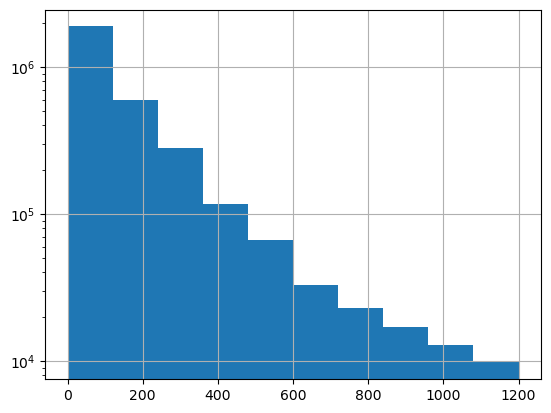

In [195]:
ime_df['time_btwn'].astype('timedelta64[s]').div(np.timedelta64(1, "s")).hist(log=True);

An attempt (failed) to assign 'intervention_batch' flag based on the 'time_diff' values.
We start with the batch number 1 whenever 'time_diff' is missing a value (i.e., with the first intervention for each officer):

In [106]:
ime_df = ime_df.assign(intervention_batch=0)
ime_df['intervention_batch'] = ime_df['intervention_batch'].mask(ime_df['time_btwn'].isna(), 1)
ime_df['intervention_batch'].sum()

658

Trying a function for vectorised assignment:

Iteration row by row would take hours:

Howeve, the following cell does it in a vectorised way, assuming that a minimal time differences separating different batches is 20 minutes:

In [107]:
ime_df = ime_df.assign(intervention_batch=-1)

ime_df['intervention_batch'] = ime_df.groupby('Intervention officer GUID')['time_btwn'].transform(lambda x: x.ge(pd.to_timedelta("20 minutes")).cumsum())

For the first officer in the sorted dataframe these would be the top (by size) 26 batches:

In [108]:
ime_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"')['intervention_batch'].value_counts().head(26)

intervention_batch
6      150
139    149
118    137
344    129
221    128
201    126
99     123
76     121
365    120
30     116
172    115
24     115
401    114
105    110
62     110
134    110
128    108
37     108
245    107
317    107
303    106
222    105
251    104
43     104
74     102
0      100
Name: count, dtype: int64

There are still 658 NaN values (i.e., one for each officer):

In [109]:
ime_df['time_btwn'].isna().sum()

658

Let's impute zero seconds for these:

In [110]:
ime_df['time_btwn'] = ime_df['time_btwn'].fillna(pd.Timedelta(seconds=0))
ime_df['time_btwn'].isna().sum()

0

The following transform will create a new column 'start_dtime' which will separate "simultaneous" intervention starts by a part of a second
(and also add extra part of a second to the subsequent interventions).
Then we add the 'Intervention method event start datetime' value to it:

In [111]:
ime_df = ime_df.assign(start_dtime=ime_df.groupby('Intervention officer GUID')['time_btwn'].transform(lambda x: x.shift().lt(pd.to_timedelta("1 seconds")).cumsum()))

In [112]:
ime_df.head()

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime
0,ccb2fb5c-1eb1-4a8a-b60e-97d0a119f899,29377f09-32f1-48c4-97eb-b7d588366e25,2024-01-05 06:44:42,INT-13773698-R7F3Q-2024-01-05 06:45:25,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,cecd11ff-2fc9-ed11-b596-0022489331f6,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-04 19:45:25,0 days 00:00:00,0,0
1,b9b50300-fb60-40a4-9370-b288ccb3ff46,919b51ab-6c76-4aac-9336-b0fb2fb9b97a,2024-01-05 06:44:42,INT-13773699-N0N0F-2024-01-05 06:45:26,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,cecd11ff-2fc9-ed11-b596-0022489331f6,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-04 19:45:26,0 days 00:02:04,0,1
2,d125a217-51f3-495b-b98a-17838cdf69a0,40a1bbb1-190a-4a36-9374-93fb53c98840,2024-01-05 06:46:46,INT-13773721-J3D5Y-2024-01-05 06:47:44,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:47:44,0 days 00:00:00,0,1
3,f2ff9fe3-087b-4bcf-a387-f86e61fdd61f,f692149a-0c22-486a-b90c-aecf8a541c3b,2024-01-05 06:46:46,INT-13773722-H6S2S-2024-01-05 06:47:44,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:47:44,0 days 00:04:24,0,2
4,e70f54a1-41c2-4596-b591-80f16bfcf69d,db8a610a-a575-4982-af5b-5aaaa23ad7b4,2024-01-05 06:51:10,INT-13773757-Z6Y1Q-2024-01-05 06:51:25,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:51:25,0 days 00:02:03,0,2


Interventions with identical start datetimes often seem to get assigned as non-cluster members (with the label -1) by the DBSCAN, so we separate them by a fraction of a second:

In [113]:
ime_df['start_dtime'] = pd.to_timedelta(ime_df['start_dtime'] / 100.0 , unit="s")  + ime_df['Intervention method event start datetime']

This results in a tiny dilation of ~2 min over the year:

In [114]:
(ime_df['start_dtime'] - ime_df['Intervention method event start datetime']).describe()

count                      3321840
mean     0 days 00:00:18.652962448
std      0 days 00:00:16.364856956
min                0 days 00:00:00
25%         0 days 00:00:06.370000
50%         0 days 00:00:14.330000
75%         0 days 00:00:26.530000
max         0 days 00:01:53.830000
dtype: object

The effect of the tiny additions to the UNIX timestamp:

In [115]:
ime_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"')['start_dtime'].apply(lambda x: x.timestamp()).iloc[0],\
ime_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"')['start_dtime'].apply(lambda x: x.timestamp()).iloc[1],\
ime_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"')['start_dtime'].apply(lambda x: x.timestamp()).iloc[2]

(1704437082.0, 1704437082.01, 1704437206.01)

Now we test the clustering, using the DBSCAN unsupervised algorithm, to detect batches/clusters of intervention activity.
We set the eps parameters to 1200 sec (20 min) as the max allowed "distance" between interventions in the same cluster.
And we also require the minimum of 5 interventions, min_samples, to make a cluster.

In [116]:
from sklearn.cluster import DBSCAN

clust_01 = DBSCAN(eps=1200, min_samples=5, p=1)

Limiting, for the times being, the dataset to a single officer:

In [117]:
first_df = ime_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"')

The total count of separate datetimes for this officer:

In [118]:
first_df.start_dtime.nunique()

15019

Now we apply the DBSCAN with chosen parameters to the first officer in the dataset, for testing:

In [119]:
first_cl = clust_01.fit(first_df['start_dtime'].apply(lambda x: x.timestamp()).to_frame())

first_cl.labels_

array([  0,   0,   0, ..., 357,  -1,  -1], dtype=int64)

The cluster labels with their member counts:

In [120]:
np.unique(first_cl.labels_, return_counts=True)

(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
         12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
         25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
         38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
         51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
         64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
         77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
         90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
        103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
        116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
        129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
        142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176

Assigning the labels to a new column 'intervention-batch' in the corresponding dataframe:

In [121]:
first_df = first_df.assign(intervention_batch=first_cl.labels_)

first_df.groupby('intervention_batch')['Location'].count().sort_values()

intervention_batch
 250      5
 206      5
 30       5
 295      5
 319      5
       ... 
 304    129
 110    137
-1      140
 130    149
 5      150
Name: Location, Length: 359, dtype: int64

Evidently, the largest batch of 150 interventions is with the label 5:

In [122]:
first_df.query('intervention_batch == 5')

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime
254,e1b8b0f7-e72d-4972-965b-aff488d39b44,b2d78583-4db9-4f5a-b37b-224dc8462aec,2024-01-06 09:30:34,INT-13784373-G0W1B-2024-01-06 09:36:37,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,72bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2024-01-05 22:36:37,0 days 00:00:00,5,2024-01-06 09:30:35.960
255,96d47042-e79b-432b-aa2a-b8d80030bcc8,62f716be-dc44-4b7d-be66-b5db01384a63,2024-01-06 09:30:34,INT-13784374-D0S0V-2024-01-06 09:36:37,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,72bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2024-01-05 22:36:37,0 days 00:06:58,5,2024-01-06 09:30:35.970
256,2a3ccc07-43f0-419b-a53c-2b82046e1ba7,f2d9903b-ca1b-4370-acc5-f0b54e3e6ea1,2024-01-06 09:37:32,INT-13784385-F1D8B-2024-01-06 09:37:40,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,72bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2024-01-05 22:37:40,0 days 00:00:00,5,2024-01-06 09:37:33.970
257,7d8bf788-c74d-40a7-9517-a39c58b58d93,5be35850-43f0-442b-9e42-18d4b81815e9,2024-01-06 09:37:32,INT-13784386-M9L0Q-2024-01-06 09:37:39,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,72bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2024-01-05 22:37:39,0 days 00:00:00,5,2024-01-06 09:37:33.980
258,9484a558-14d8-4cb5-8011-065e358310c5,40062abc-568e-4d7c-882f-092b4bf72919,2024-01-06 09:37:32,INT-13784387-B2Q7R-2024-01-06 09:37:40,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,72bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2024-01-05 22:37:40,0 days 00:00:00,5,2024-01-06 09:37:33.990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,ae84b0c1-d3e1-4256-9dcc-167d95131404,1e64b743-830f-42cc-bb9b-8f4f1b424640,2024-01-06 12:23:33,INT-13786519-N3D1H-2024-01-06 12:23:56,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,cecd11ff-2fc9-ed11-b596-0022489331f6,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-06 01:23:56,0 days 00:02:25,5,2024-01-06 12:23:36.120
400,b960733f-f14a-4ab4-a19a-d9c0675cd4a2,ae266994-2373-4dbe-8aed-80c0177f07cb,2024-01-06 12:25:58,INT-13786527-M2T4B-2024-01-06 12:26:31,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,ed1307ea-fb82-ec11-8d21-00224892090f,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-06 01:26:31,0 days 00:00:00,5,2024-01-06 12:26:01.120
401,3e99466b-f73f-42d4-89fa-322d9bc6c2ea,bd92a9a2-a08e-4e0c-9594-12c903ddca77,2024-01-06 12:25:58,INT-13786528-W7Z9R-2024-01-06 12:26:31,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,ed1307ea-fb82-ec11-8d21-00224892090f,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-06 01:26:31,0 days 00:01:39,5,2024-01-06 12:26:01.130
402,657e69b2-5dcc-4f94-8cf2-c0b3abfcb34b,7a3e7711-dfb7-43f9-9844-53df01593d6b,2024-01-06 12:27:37,INT-13786546-P5R6G-2024-01-06 12:27:45,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,ed1307ea-fb82-ec11-8d21-00224892090f,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-06 01:27:45,0 days 00:00:00,5,2024-01-06 12:27:40.130


Confirming the batch duration of ~3 hours:

In [123]:
first_df.groupby('intervention_batch').agg(batch_duraion=('Intervention method event start datetime', lambda x: x.max() - x.min())).iloc[6]

batch_duraion   0 days 02:57:03
Name: 5, dtype: timedelta64[ns]

The officer took almost 20 days before the next interventions:

In [124]:
first_df.iloc[[404, 405],:]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime
404,1915e480-fe6f-4bcd-ae0c-f594f7e25adc,ad77fbc7-d00a-4d01-a443-3ffec9ec51f9,2024-01-26 06:59:27,INT-13953868-H3C4F-2024-01-26 07:21:40,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-25 20:21:40,0 days 00:00:00,-1,2024-01-26 06:59:30.140
405,91f7311e-5572-4cd9-ab61-abe692345879,b3edb87b-a6f2-4b14-8c79-6bddd64dc0ab,2024-01-26 06:59:27,INT-13953870-S4H1V-2024-01-26 07:21:39,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-25 20:21:39,0 days 00:21:58,-1,2024-01-26 06:59:30.150


However, the following batch, with the label 6 , starts only 22 minutes later:

In [125]:
first_df.query('intervention_batch == 6').head()

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime
406,b579003c-8259-47c8-9268-0e25bc76dd22,273cbcdf-2426-4bb7-8a85-447081cb7a71,2024-01-26 07:21:25,INT-13953869-F8G6S-2024-01-26 07:21:40,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,6644fc7d-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-01-25 20:21:40,0 days 00:00:00,6,2024-01-26 07:21:28.150
407,335da8cf-583e-4b79-8066-66188fee48ec,b539caf4-a8f1-41c6-881d-379e89cb2ae1,2024-01-26 07:21:25,INT-13953871-H9G9V-2024-01-26 07:21:39,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,6644fc7d-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-01-25 20:21:40,0 days 00:02:06,6,2024-01-26 07:21:28.160
408,3f0a2b64-5686-4904-8840-69109d85e1ca,89ccf6aa-8956-418a-b52e-7ba4069e3d37,2024-01-26 07:23:31,INT-13953887-X5Y9Z-2024-01-26 07:23:40,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,6644fc7d-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-01-25 20:23:40,0 days 00:00:00,6,2024-01-26 07:23:34.160
409,dfa818fb-c717-4b59-995d-15c9db7a2418,d4281f22-1a2b-45c4-bc46-7740ae1dde2f,2024-01-26 07:23:31,INT-13953888-S3H8W-2024-01-26 07:23:40,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,6644fc7d-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-01-25 20:23:40,0 days 00:01:16,6,2024-01-26 07:23:34.170
410,cad8b312-005a-4322-9280-1633b70ee33a,f167214d-f765-45e2-9a87-0673eaf9b672,2024-01-26 07:24:47,INT-13953923-V6X4H-2024-01-26 07:26:6,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,6644fc7d-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-01-25 20:26:06,0 days 00:00:00,6,2024-01-26 07:24:50.170


And it goes for 47 min:

In [126]:
first_df.groupby('intervention_batch').agg(batch_duraion=('Intervention method event start datetime', lambda x: x.max() - x.min())).iloc[7]

batch_duraion   0 days 00:46:45
Name: 6, dtype: timedelta64[ns]

To properly assign values to the 'intervention_batch' column across the whole set, we will add a new feature called 'unix_timestamp' (because the raw datetime type is not the best choice for DBSCAN).
Note this column is not actually assigned to the dataframe, it will only exist inside the "view" used for cluster fitting.

In [127]:
ime_df.assign(unix_tstamp=ime_df['start_dtime'].apply(lambda x: x.timestamp())).head()

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,unix_tstamp
0,ccb2fb5c-1eb1-4a8a-b60e-97d0a119f899,29377f09-32f1-48c4-97eb-b7d588366e25,2024-01-05 06:44:42,INT-13773698-R7F3Q-2024-01-05 06:45:25,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,cecd11ff-2fc9-ed11-b596-0022489331f6,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-04 19:45:25,0 days 00:00:00,0,2024-01-05 06:44:42.000,1.704437e+09
1,b9b50300-fb60-40a4-9370-b288ccb3ff46,919b51ab-6c76-4aac-9336-b0fb2fb9b97a,2024-01-05 06:44:42,INT-13773699-N0N0F-2024-01-05 06:45:26,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,cecd11ff-2fc9-ed11-b596-0022489331f6,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-04 19:45:26,0 days 00:02:04,0,2024-01-05 06:44:42.010,1.704437e+09
2,d125a217-51f3-495b-b98a-17838cdf69a0,40a1bbb1-190a-4a36-9374-93fb53c98840,2024-01-05 06:46:46,INT-13773721-J3D5Y-2024-01-05 06:47:44,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:47:44,0 days 00:00:00,0,2024-01-05 06:46:46.010,1.704437e+09
3,f2ff9fe3-087b-4bcf-a387-f86e61fdd61f,f692149a-0c22-486a-b90c-aecf8a541c3b,2024-01-05 06:46:46,INT-13773722-H6S2S-2024-01-05 06:47:44,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:47:44,0 days 00:04:24,0,2024-01-05 06:46:46.020,1.704437e+09
4,e70f54a1-41c2-4596-b591-80f16bfcf69d,db8a610a-a575-4982-af5b-5aaaa23ad7b4,2024-01-05 06:51:10,INT-13773757-Z6Y1Q-2024-01-05 06:51:25,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:51:25,0 days 00:02:03,0,2024-01-05 06:51:10.020,1.704437e+09


Checking that each timestamp is unique:

In [128]:
ime_df.assign(unix_tstamp=ime_df['start_dtime'].apply(lambda x: x.timestamp())).groupby('Intervention officer GUID')['unix_tstamp'].nunique()

Intervention officer GUID
002727cb-77a9-eb11-9442-0022480fe6d6    15019
0030689c-d2aa-ea11-a814-000d3a6a9def      449
0116c2cb-c1e4-ee11-904d-002248933647    12900
01493553-d3aa-ea11-a814-000d3a6a9def     2207
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e     9172
                                        ...  
fcd011f6-d3aa-ea11-a814-000d3a6a9def     5047
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def     1789
fe185c2a-ac8f-ed11-aad1-002248933b6d     9259
ff36baa6-d5aa-ea11-a814-000d3a6a9def     6513
ff485647-46ba-ee11-9078-0022489330fc     6338
Name: unix_tstamp, Length: 658, dtype: int64

##### SUPER IMPORTANT:
Use a new DBSCAN(...) constructor for each group (i.e., officer), not clust01, or the groups will be getting overwritten!!!!

In [129]:
dclusters = ime_df.assign(unix_tstamp=ime_df['start_dtime'].apply(lambda x: x.timestamp())).groupby('Intervention officer GUID')\
            ['unix_tstamp'].agg(lambda x: DBSCAN(eps=1200, min_samples=5, p=1).fit(x.values.reshape(-1, 1)))

Checking that the results from first_df above match those for the corresponding officer:

In [130]:
np.unique(dclusters['002727cb-77a9-eb11-9442-0022480fe6d6'].labels_, return_counts=True)

(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
         12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
         25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
         38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
         51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
         64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
         77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
         90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
        103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
        116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
        129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
        142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176

For the final officer in the dataset:

In [131]:
np.unique(dclusters['ff485647-46ba-ee11-9078-0022489330fc'].labels_, return_counts=True)

(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
         12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
         25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
         38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
         51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
         64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
         77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
         90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
        103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
        116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
        129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
        142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176

Indexing either via integers of officer ID keys:

In [132]:
dclusters.iloc[0] == dclusters['002727cb-77a9-eb11-9442-0022480fe6d6']

True

In [133]:
dclusters.index

Index(['002727cb-77a9-eb11-9442-0022480fe6d6',
       '0030689c-d2aa-ea11-a814-000d3a6a9def',
       '0116c2cb-c1e4-ee11-904d-002248933647',
       '01493553-d3aa-ea11-a814-000d3a6a9def',
       '0207bdc5-cfaa-ea11-a814-000d3a6a9c0e',
       '02c902d9-d0aa-ea11-a814-000d3a6a9def',
       '030f321a-d4aa-ea11-a814-000d3a6a9def',
       '0315f2f5-d4aa-ea11-a814-000d3a6a9def',
       '03259f49-b44a-ed11-bba2-002248933bc9',
       '03bce54c-a0af-ec11-983f-000d3a6a5ed4',
       ...
       'fa75ad99-87b6-ee11-a568-00224893324d',
       'fae89c27-d3aa-ea11-a814-000d3a6a9def',
       'fb01eafb-d4aa-ea11-a814-000d3a6a9def',
       'fb0ef5c3-d1aa-ea11-a814-000d3a6a9def',
       'fc485647-46ba-ee11-9078-0022489330fc',
       'fcd011f6-d3aa-ea11-a814-000d3a6a9def',
       'fd5fd5b3-d3aa-ea11-a814-000d3a6a9def',
       'fe185c2a-ac8f-ed11-aad1-002248933b6d',
       'ff36baa6-d5aa-ea11-a814-000d3a6a9def',
       'ff485647-46ba-ee11-9078-0022489330fc'],
      dtype='object', name='Intervention officer

Preparing to merge the cluster labels with the ime_df using officer ID:

In [134]:
clust_ser = dclusters.apply(lambda x: x.labels_).explode()
clust_ser

Intervention officer GUID
002727cb-77a9-eb11-9442-0022480fe6d6      0
002727cb-77a9-eb11-9442-0022480fe6d6      0
002727cb-77a9-eb11-9442-0022480fe6d6      0
002727cb-77a9-eb11-9442-0022480fe6d6      0
002727cb-77a9-eb11-9442-0022480fe6d6      0
                                       ... 
ff485647-46ba-ee11-9078-0022489330fc    328
ff485647-46ba-ee11-9078-0022489330fc    328
ff485647-46ba-ee11-9078-0022489330fc    328
ff485647-46ba-ee11-9078-0022489330fc    328
ff485647-46ba-ee11-9078-0022489330fc    328
Name: unix_tstamp, Length: 3321840, dtype: object

The lengths and the column/index match:

In [135]:
ime_df.shape, clust_ser.shape

((3321840, 16), (3321840,))

In [136]:
(ime_df['Intervention officer GUID'] == clust_ser.index).all()

True

Hence, merge/join can be avoided. It is easier to simply assign the cluster labels to the 'intervention_batch' column:

In [137]:
ime_df['intervention_batch'] = clust_ser.values
ime_df

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime
0,ccb2fb5c-1eb1-4a8a-b60e-97d0a119f899,29377f09-32f1-48c4-97eb-b7d588366e25,2024-01-05 06:44:42,INT-13773698-R7F3Q-2024-01-05 06:45:25,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,cecd11ff-2fc9-ed11-b596-0022489331f6,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-04 19:45:25,0 days 00:00:00,0,2024-01-05 06:44:42.000
1,b9b50300-fb60-40a4-9370-b288ccb3ff46,919b51ab-6c76-4aac-9336-b0fb2fb9b97a,2024-01-05 06:44:42,INT-13773699-N0N0F-2024-01-05 06:45:26,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,cecd11ff-2fc9-ed11-b596-0022489331f6,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-04 19:45:26,0 days 00:02:04,0,2024-01-05 06:44:42.010
2,d125a217-51f3-495b-b98a-17838cdf69a0,40a1bbb1-190a-4a36-9374-93fb53c98840,2024-01-05 06:46:46,INT-13773721-J3D5Y-2024-01-05 06:47:44,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:47:44,0 days 00:00:00,0,2024-01-05 06:46:46.010
3,f2ff9fe3-087b-4bcf-a387-f86e61fdd61f,f692149a-0c22-486a-b90c-aecf8a541c3b,2024-01-05 06:46:46,INT-13773722-H6S2S-2024-01-05 06:47:44,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:47:44,0 days 00:04:24,0,2024-01-05 06:46:46.020
4,e70f54a1-41c2-4596-b591-80f16bfcf69d,db8a610a-a575-4982-af5b-5aaaa23ad7b4,2024-01-05 06:51:10,INT-13773757-Z6Y1Q-2024-01-05 06:51:25,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-04 19:51:25,0 days 00:02:03,0,2024-01-05 06:51:10.020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3321835,a2d28d7c-e641-481a-99d4-159d228b6969,1b5491c6-cf0f-4d15-bd7c-9012a1b5285f,2024-12-18 10:56:51,INT-16802701-D2L7K-2024-12-18 10:59:50,445290003,445290000,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-12-17 23:59:50,0 days 00:02:48,328,2024-12-18 10:57:14.340
3321836,e608b64b-ecb1-4d2a-9bcc-bf66daa4e668,fc9cde30-bb5a-479b-aac1-66d8b3c819a7,2024-12-18 10:59:39,INT-16802699-B2Z7X-2024-12-18 10:59:50,445290005,445290003,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-12-17 23:59:50,0 days 00:04:18,328,2024-12-18 11:00:02.340
3321837,b04db5e2-7213-402e-aa41-d41ad0dc42c7,c75b20cf-67c8-4787-8811-e803b5e3bb1b,2024-12-18 11:03:57,INT-16802769-J5B1B-2024-12-18 11:04:26,445290003,445290001,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,Declared item of interest,Secondary Examination Area,2024-12-18 00:04:27,0 days 00:18:13,328,2024-12-18 11:04:20.340
3321838,8b8743d1-24e1-4ea2-9d55-e67873b9979a,7b2e3045-8a4e-4b39-b203-9a55abc47bff,2024-12-18 11:22:10,INT-16803096-L6Y8V-2024-12-18 11:22:56,445290003,445290001,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,"Declared item of interest, X-ray referral",Secondary Examination Area,2024-12-18 00:22:56,0 days 00:01:02,328,2024-12-18 11:22:33.340


About 8.4% of the records didn't fit into a batch (i.e., were assigned the label -1):

In [138]:
print(ime_df['intervention_batch'].eq(-1).sum(), f"{round(ime_df['intervention_batch'].eq(-1).sum() / 33218.40, 1)}%")

279062 8.4%


Often the minimal cluster for an officer is well below the min_samples=5, e.g. the following are 3 or below:

In [139]:
mmm = [print(i, ":", min(np.unique(c.labels_, return_counts=True)[1])) for i, c in enumerate(dclusters) 
       if (i_min := np.argmin(np.unique(c.labels_, return_counts=True)[1])) &
           ( np.unique(c.labels_, return_counts=True)[1][i_min] <= 3 ) &
           (np.unique(c.labels_, return_counts=True)[0][i_min] >= 0 )
      ]

2 : 3
34 : 3
120 : 3
160 : 3
172 : 3
173 : 3
189 : 3
228 : 3
229 : 3
294 : 3
308 : 3
355 : 3
363 : 3
387 : 3
408 : 3
413 : 3
436 : 3
445 : 3
456 : 3
485 : 3
502 : 3
507 : 3
539 : 3
563 : 3
599 : 3
606 : 3


Some officers exhibit a high intervention activity. This one is particularly interesting, in excess of 50 intervention per batch:

In [140]:
lll = [print(i, ":",  min(np.unique(c.labels_, return_counts=True)[1])) for i, c in enumerate(dclusters) if min(np.unique(c.labels_, return_counts=True)[1]) > 50]

560 : 147


In [141]:
dclusters.index[560]

'dadaeb73-fa65-ed11-9561-002248933419'

The officer "dadaeb73-fa65-ed11-9561-002248933419" had only two batches of intervention activity, bot well in excess of 100:

In [142]:
dclusters.iloc[560].labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Both batches happenened on the same day 2024-01-09, the first in the morning and second in the afternoon:

In [143]:
ime_df.query('`Intervention officer GUID` == "dadaeb73-fa65-ed11-9561-002248933419"')

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime
2878821,ffd3d674-1a43-4583-a27a-cc17f81891c1,cfbb7be3-e73b-4f3e-b698-7cab48a9fbce,2024-01-09 07:06:29,INT-13810111-C5X6C-2024-01-09 07:09:54,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,ed1307ea-fb82-ec11-8d21-00224892090f,d0f2ab63-6477-ec11-8d21-00224812d58f,NaN,Secondary Examination Area,2024-01-08 20:09:54,0 days 00:00:00,0,2024-01-09 07:06:29.000
2878822,5f3c1f9d-11a2-4e66-ac85-bbd9ac4313c9,6931588c-9bd6-44f3-af11-df1cffd1ef34,2024-01-09 07:06:29,INT-13810112-D7K7N-2024-01-09 07:09:54,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,ed1307ea-fb82-ec11-8d21-00224892090f,d0f2ab63-6477-ec11-8d21-00224812d58f,NaN,Secondary Examination Area,2024-01-08 20:09:54,0 days 00:00:00,0,2024-01-09 07:06:29.010
2878823,9a2c060d-aec0-4294-a314-95c9c0dc14c0,847108ad-038d-43d7-b47c-f28c8c21efe7,2024-01-09 07:06:29,INT-13810113-Y4F1H-2024-01-09 07:09:55,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,ed1307ea-fb82-ec11-8d21-00224892090f,d0f2ab63-6477-ec11-8d21-00224812d58f,NaN,Secondary Examination Area,2024-01-08 20:09:55,0 days 00:00:00,0,2024-01-09 07:06:29.020
2878824,e68ab522-3938-4a76-947e-cc635486d68f,6844f648-5f7c-4d9d-a395-9f870306ac1a,2024-01-09 07:06:29,INT-13810114-X3J3K-2024-01-09 07:09:55,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,ed1307ea-fb82-ec11-8d21-00224892090f,d0f2ab63-6477-ec11-8d21-00224812d58f,NaN,Secondary Examination Area,2024-01-08 20:09:55,0 days 00:00:00,0,2024-01-09 07:06:29.030
2878825,c6c4db89-2f26-44fc-9a7f-24cf3edda7cb,58b96415-5c65-4ccf-97d4-a472c3d2e59b,2024-01-09 07:06:29,INT-13810115-F0H4C-2024-01-09 07:09:55,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,ed1307ea-fb82-ec11-8d21-00224892090f,d0f2ab63-6477-ec11-8d21-00224812d58f,NaN,Secondary Examination Area,2024-01-08 20:09:55,0 days 00:05:27,0,2024-01-09 07:06:29.040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2879145,f7717bba-b6bf-4ea7-ac06-45791a6e03d1,c7f89d68-cd27-4e1f-9df5-eb5932834ad4,2024-01-09 12:05:30,INT-13813822-F6Z4W-2024-01-09 12:06:2,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,babb7692-f0cf-eb11-8235-0022481542dd,8897b976-cfaa-ea11-a814-000d3a6a9c0e,NaN,Secondary Examination Area,2024-01-09 01:06:02,0 days 00:00:57,1,2024-01-09 12:05:32.660
2879146,89a2c466-8bfa-49f0-9150-58456b8f97b6,f318ddd5-7f41-4fff-adce-f3c2cf0ebff6,2024-01-09 12:06:27,INT-13813840-M0M4F-2024-01-09 12:07:42,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,ed1307ea-fb82-ec11-8d21-00224892090f,d0f2ab63-6477-ec11-8d21-00224812d58f,NaN,Secondary Examination Area,2024-01-09 01:07:42,0 days 00:00:00,1,2024-01-09 12:06:29.660
2879147,70867719-cc07-4f99-b0cb-90159f403ba6,43436b5b-c4c0-463b-94a0-c6793a4d1b23,2024-01-09 12:06:27,INT-13813841-L2V2T-2024-01-09 12:07:43,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,ed1307ea-fb82-ec11-8d21-00224892090f,d0f2ab63-6477-ec11-8d21-00224812d58f,NaN,Secondary Examination Area,2024-01-09 01:07:43,0 days 00:03:01,1,2024-01-09 12:06:29.670
2879148,7273c249-0fe4-463e-a13a-426628266fb0,3f6d7b03-2d53-46ce-a500-c1946870fd65,2024-01-09 12:09:28,INT-13813892-P2M2F-2024-01-09 12:13:0,445290002,445290000,NaN,dadaeb73-fa65-ed11-9561-002248933419,ed1307ea-fb82-ec11-8d21-00224892090f,d0f2ab63-6477-ec11-8d21-00224812d58f,NaN,Secondary Examination Area,2024-01-09 01:13:00,0 days 00:00:00,1,2024-01-09 12:09:30.670


Now adding a new feature 'intervention_count' which is the number of interventions by the same officer starting at the same time (this will be needed to split the time evenly).

Note, however, that there are occurrences of two sub-batches (i.e., subsets of interventions by the same officer at two different times) separated by a SINGLE SECOND, for example:

In [144]:
ime_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"').\
    query('`Intervention method event start datetime`.ge(@pd.to_datetime("2024-06-02 12:21:29"))').head()

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime
7768,9686e4cc-04dd-49ac-8d64-647912e13e99,7b90c7ae-2224-41f9-a5c6-4770145c3210,2024-06-02 12:21:29,INT-14926813-J7C5D-2024-06-02 12:21:40,445290002,445290001,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,77cd9aa9-e674-ec11-8943-002248920ae0,K9 referral,Secondary Examination Area,2024-06-02 02:21:40,0 days 00:00:00,171,2024-06-02 12:22:28.130
7769,9ef412a6-698b-4169-8681-46b588cbad04,59dcc2ad-ff61-4065-a86b-43b2828eb78b,2024-06-02 12:21:29,INT-14926816-C2C2W-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:00:00,171,2024-06-02 12:22:28.140
7770,dcfaffe1-141d-41d2-b876-986ae80f155c,e9f884bd-59be-4a35-9941-637899f53831,2024-06-02 12:21:29,INT-14926817-P5Y2L-2024-06-02 12:21:48,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:48,0 days 00:00:01,171,2024-06-02 12:22:28.150
7771,7d65ddbf-0695-4d16-8de3-a3245ce881d8,ed13b5ee-c796-4793-969f-bbbb88f6bb1e,2024-06-02 12:21:30,INT-14926814-Y2F9N-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:00:00,171,2024-06-02 12:22:29.150
7772,0da01c33-5c40-45b8-9452-e126deb25699,83ad4a57-fe13-4cfc-b6bf-8aa3b4c455a5,2024-06-02 12:21:30,INT-14926815-K2S8J-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:01:55,171,2024-06-02 12:22:29.160


Clearly, all such occurrences should be lumped together into a single sub-batch.
So, we create a new temporary column 'rounded_start' with start datetimes rounded to 5 seconds so we can count the associated interventions inside the same sub-batch in the 'intervention_count':

In [145]:
ime_df['intervention_count'] = ime_df.assign(rounded_start=ime_df['Intervention method event start datetime'].round("5s")).\
    groupby(['Intervention officer GUID', 'rounded_start'])\
            ['start_dtime'].transform("nunique")

Two checks, both successful:

In [146]:
ime_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"').\
    query('`Intervention method event start datetime`.ge(@pd.to_datetime("2024-06-02 12:21:29"))').head(6)

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
7768,9686e4cc-04dd-49ac-8d64-647912e13e99,7b90c7ae-2224-41f9-a5c6-4770145c3210,2024-06-02 12:21:29,INT-14926813-J7C5D-2024-06-02 12:21:40,445290002,445290001,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,77cd9aa9-e674-ec11-8943-002248920ae0,K9 referral,Secondary Examination Area,2024-06-02 02:21:40,0 days 00:00:00,171,2024-06-02 12:22:28.130,3
7769,9ef412a6-698b-4169-8681-46b588cbad04,59dcc2ad-ff61-4065-a86b-43b2828eb78b,2024-06-02 12:21:29,INT-14926816-C2C2W-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:00:00,171,2024-06-02 12:22:28.140,3
7770,dcfaffe1-141d-41d2-b876-986ae80f155c,e9f884bd-59be-4a35-9941-637899f53831,2024-06-02 12:21:29,INT-14926817-P5Y2L-2024-06-02 12:21:48,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:48,0 days 00:00:01,171,2024-06-02 12:22:28.150,3
7771,7d65ddbf-0695-4d16-8de3-a3245ce881d8,ed13b5ee-c796-4793-969f-bbbb88f6bb1e,2024-06-02 12:21:30,INT-14926814-Y2F9N-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:00:00,171,2024-06-02 12:22:29.150,2
7772,0da01c33-5c40-45b8-9452-e126deb25699,83ad4a57-fe13-4cfc-b6bf-8aa3b4c455a5,2024-06-02 12:21:30,INT-14926815-K2S8J-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:01:55,171,2024-06-02 12:22:29.160,2
7773,9d76b5df-edd5-45d1-a411-26fceb8c14c3,3ff71ed4-4631-4b5f-9371-4db5f0ffb48c,2024-06-02 12:23:25,INT-14926829-H2Y1H-2024-06-02 12:24:43,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,77cd9aa9-e674-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:24:43,0 days 00:00:00,171,2024-06-02 12:24:24.160,2


In [147]:
ime_df.query('`Intervention officer GUID` == "fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7"').\
    query('`Intervention method event start datetime`.ge(@pd.to_datetime("2024-02-03 07:18:29"))').head(7)

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
3258683,57e0e70e-a8af-476d-93b1-0f79ee9f5f10,dd865613-6b22-4fa4-9acb-00545541c9d7,2024-02-03 07:18:29,INT-14020879-P6N6W-2024-02-03 07:18:37,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:38,0 days 00:00:00,43,2024-02-03 07:18:38.820,5
3258684,5453ae4d-d6a4-4b3d-a1d4-58dc85330129,038cf8c8-28fe-41f9-818d-9abbc8383733,2024-02-03 07:18:29,INT-14020881-B2C7B-2024-02-03 07:18:38,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:38,0 days 00:00:00,43,2024-02-03 07:18:38.830,5
3258685,22884045-4f06-463a-9732-d286c7fed34c,c9b4f87a-340b-454c-8b22-97599a47515c,2024-02-03 07:18:29,INT-14020882-V4Z4R-2024-02-03 07:18:38,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:38,0 days 00:00:00,43,2024-02-03 07:18:38.840,5
3258686,c91db98c-0486-434c-a492-6461afe63a39,713fa15c-5723-4c38-aed9-5f133174259f,2024-02-03 07:18:29,INT-14020883-W8K4N-2024-02-03 07:18:38,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:38,0 days 00:00:00,43,2024-02-03 07:18:38.850,5
3258687,873683d6-01cf-4c2d-846c-d647e9eed061,e8a643da-eaf3-469a-b804-1f7d5eca9868,2024-02-03 07:18:29,INT-14020884-L5P9W-2024-02-03 07:18:39,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:39,0 days 00:00:01,43,2024-02-03 07:18:38.860,5
3258688,695dcdbd-6a02-4154-874c-0d03eb152c1c,8dcc6519-1e8a-44a7-b13f-fa0b3c2b2fd8,2024-02-03 07:18:30,INT-14020880-N4F0F-2024-02-03 07:18:38,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:38,0 days 00:03:16,43,2024-02-03 07:18:39.860,1
3258689,2adf663e-173c-4cc8-b8f8-455882b389b9,5d7c6146-5ad7-44c8-9b19-2f71c7e872c9,2024-02-03 07:21:46,INT-14020916-S8Q6S-2024-02-03 07:21:53,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:21:53,0 days 00:00:00,43,2024-02-03 07:21:55.860,4


In [148]:
ime_df['intervention_batch'] = ime_df['intervention_batch'].astype(np.int16)
ime_df['intervention_count'] = ime_df['intervention_count'].astype(np.uint8)

A quick test: are there groups of (officer, start_datetimes) pairs with more than a single batch? Normally one would expect that only a single batch could start at a given datetime.
Let's take a look at the cluster labels at each start datetime. Apparently, there are 26 cases with more than a single batch:

In [149]:
(ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime'])['intervention_batch'].nunique() > 1).sum()

19

These are all the rows that exhibit the issue:

In [150]:
# ime_df.groupby(['Intervention officer GUID', ime_df_Br['Amendment_date'].round("5s")]),  rounding may not be necessary, though

with pd.option_context("display.max_rows", None):
    display(ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime']).filter(lambda x: x['intervention_batch'].nunique() > 1))

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
22887,a89a6b40-6bdc-4692-9225-4511e78978a1,b68d2e9c-c038-404c-9050-ce66fed82cf1,2024-10-03 15:01:49,INT-16009379-Z3J5B-2024-10-03 15:01:56,445290003,445290000,NaN,0116c2cb-c1e4-ee11-904d-002248933647,NaN,NaN,NaN,Secondary Examination Area,2024-10-03 05:01:56,0 days 00:00:00,294,2024-10-03 15:02:21.190,2
22888,07cdc87f-489d-49fc-8687-b56739aa0aa2,99ebae65-976a-4be0-83c3-2b14ff701545,2024-10-03 15:01:49,INT-16009380-F9B4V-2024-10-03 15:01:56,445290003,445290000,NaN,0116c2cb-c1e4-ee11-904d-002248933647,NaN,NaN,NaN,Secondary Examination Area,2024-10-03 05:01:56,0 days 16:55:06,-1,2024-10-03 15:02:21.200,2
155081,7cfc58b9-c641-4c45-b907-ed14773b897e,24381615-c039-41a9-8dc0-cae78dcda49a,2024-01-29 14:49:59,INT-13985137-G6P2K-2024-01-29 14:50:15,445290003,445290000,NaN,0c07bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-01-29 03:50:15,0 days 00:00:00,-1,2024-01-29 14:50:00.110,2
155082,cb8e016c-a27a-40b5-8d47-eef6ff58d472,eaf187a9-3768-4ae2-952f-b96dcece0b27,2024-01-29 14:49:59,INT-13985138-X8B6Q-2024-01-29 14:50:15,445290003,445290000,NaN,0c07bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-01-29 03:50:15,0 days 00:04:55,21,2024-01-29 14:50:00.120,2
279360,f424752a-629c-4608-853e-ef4f5a893cb0,5d6767fe-6e6e-4e1f-b99a-370051efa6f2,2024-04-13 08:01:26,INT-14542507-B7J5H-2024-04-13 08:01:53,445290005,445290003,NaN,13917d7d-d3aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-12 22:01:53,0 days 00:00:00,-1,2024-04-13 08:01:29.890,2
279361,4efb14db-6c10-4e2f-93e8-63500e96e1ef,59a72941-35b1-46c8-80e3-38bc04f70c07,2024-04-13 08:01:26,INT-14542508-J0T2N-2024-04-13 08:01:53,445290005,445290000,NaN,13917d7d-d3aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-12 22:01:53,0 days 00:20:00,63,2024-04-13 08:01:29.900,2
296398,7521e56f-c5d0-487d-b867-16c99671e7a7,06cc9787-e7c2-4e4c-bfc7-c7f48498c2db,2024-09-21 10:40:31,INT-15885833-P4M5F-2024-09-21 10:49:30,445290005,445290003,NaN,13c15e2e-5b5e-ed11-9562-0022489335c0,NaN,NaN,NaN,Secondary Examination Area,2024-09-21 00:49:30,0 days 00:00:00,143,2024-09-21 10:40:41.960,2
296399,f4c78c24-7dbe-4b31-b12c-e3c555dbf8e6,3a1f54a3-f144-45be-87a4-f62859365434,2024-09-21 10:40:31,INT-15886569-H4N9R-2024-09-21 10:49:29,445290005,445290003,NaN,13c15e2e-5b5e-ed11-9562-0022489335c0,NaN,NaN,NaN,Secondary Examination Area,2024-09-21 00:49:29,0 days 00:20:41,-1,2024-09-21 10:40:41.970,2
334980,b8117bc5-f412-4ff1-b098-5b97f49a262c,b80eb219-4595-4b76-aafc-d785eb3f4b6d,2024-03-03 18:56:08,INT-14247341-N5D6T-2024-03-03 18:58:27,445290003,445290000,NaN,18e14d43-46ba-ee11-9078-00224892212f,NaN,NaN,NaN,Secondary Examination Area,2024-03-03 07:58:27,0 days 00:00:00,-1,2024-03-03 18:56:09.050,2
334981,61571e8d-c1ec-4fe7-9657-159bd07e8aa8,1d0c886c-122d-46c7-8a49-5005f99300a0,2024-03-03 18:56:08,INT-14247342-G1X8X-2024-03-03 18:58:27,445290003,445290000,NaN,18e14d43-46ba-ee11-9078-00224892212f,NaN,NaN,NaN,Secondary Examination Area,2024-03-03 07:58:27,0 days 00:20:00,21,2024-03-03 18:56:09.060,2


The general case here is that a single intervention is assigned a proper cluster label, while one or more interventions starting at the same time are labelled -1 (not associated with that cluster).
It seems that this was a quirk of the DBSCAN model. 

Saving the 19 (officer, start_datetime) pair combinations:

In [151]:
ggg = ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime'])
the_19 = (ggg['intervention_batch'].nunique() == 2).index[ggg['intervention_batch'].nunique() == 2]
the_19

MultiIndex([('0116c2cb-c1e4-ee11-904d-002248933647', '2024-10-03 15:01:49'),
            ('0c07bdc5-cfaa-ea11-a814-000d3a6a9c0e', '2024-01-29 14:49:59'),
            ('13917d7d-d3aa-ea11-a814-000d3a6a9def', '2024-04-13 08:01:26'),
            ('13c15e2e-5b5e-ed11-9562-0022489335c0', '2024-09-21 10:40:31'),
            ('18e14d43-46ba-ee11-9078-00224892212f', '2024-03-03 18:56:08'),
            ('2b15f2f5-d4aa-ea11-a814-000d3a6a9def', '2024-01-31 10:53:13'),
            ('334dbd6a-df00-ed11-82e6-000d3acc5e31', '2024-12-08 17:22:02'),
            ('5602eafb-d4aa-ea11-a814-000d3a6a9def', '2024-04-08 20:33:38'),
            ('84d7b4d2-d2aa-ea11-a814-000d3a6a9def', '2024-06-09 13:44:16'),
            ('89e42555-075f-ed11-9562-0022489335c0', '2024-11-13 17:49:06'),
            ('aa0500b9-d5aa-ea11-a814-000d3a6a9def', '2024-03-07 09:46:28'),
            ('b3466e2a-45ed-ec11-bb3d-000d3acc2ca6', '2024-10-05 17:58:10'),
            ('c5279844-2d71-ed11-81ab-00224811ba98', '2024-02-08 13:36:52'),

Let's review these 19 cases and the two cluster labels arising within:

Seeing that the 'intervention_count' columns shows that these unassigned interventions have been counted, we should impute the cluster label accordingly:

In [152]:
for off, sdt in the_19:
    both = set(ime_df.query('`Intervention officer GUID` == @off').query('`Intervention method event start datetime` == @pd.to_datetime(@sdt)').index)
    only_negs = set(ime_df.query('`Intervention officer GUID` == @off').query('`Intervention method event start datetime` == @pd.to_datetime(@sdt)').query('intervention_batch < 0').index)
    non_neg = both.difference(only_negs).pop()
    print(f"Indices labelled -1: {only_negs}, proper label index: {non_neg}")
    # imputing:
    ime_df.iloc[list(only_negs), 14] = ime_df.iloc[non_neg, 14]

Indices labelled -1: {22888}, proper label index: 22887
Indices labelled -1: {155081}, proper label index: 155082
Indices labelled -1: {279360}, proper label index: 279361
Indices labelled -1: {296399}, proper label index: 296398
Indices labelled -1: {334980}, proper label index: 334981
Indices labelled -1: {583125}, proper label index: 583126
Indices labelled -1: {700367}, proper label index: 700366
Indices labelled -1: {1202903}, proper label index: 1202904
Indices labelled -1: {1844807}, proper label index: 1844806
Indices labelled -1: {1912992}, proper label index: 1912993
Indices labelled -1: {2314430}, proper label index: 2314429
Indices labelled -1: {2424348}, proper label index: 2424349
Indices labelled -1: {2611369}, proper label index: 2611368
Indices labelled -1: {2733116}, proper label index: 2733117
Indices labelled -1: {2861264}, proper label index: 2861263
Indices labelled -1: {3050412}, proper label index: 3050413
Indices labelled -1: {3161347}, proper label index: 3161

Verifying that the labels have been updated:

In [153]:
(ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime'])['intervention_batch'].nunique() > 1).sum()

0

The tricky part now is to identify all sub-batches (i.e., the interventions starting at the same time) with all except one (final) 'time_btwn' values equal to zero.
If the final value is below 20 min, this sub-batch is ok as is.
However, if the final 'time_btwn' value exceeds 20 min, it has to be imputed somehow in order to keep the intervention inside the cluster and divide this 'time_btwn' value evenly over the sub-batch. 

In [154]:
ddd_df = ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime']).agg(
    zero_count=('time_btwn', lambda x: x.eq(pd.to_timedelta("0 seconds")).sum()),
    over_20m=('time_btwn', lambda x: x.gt(pd.to_timedelta("20 minutes")).sum()),
    max_batch=('intervention_batch', "max"),
    max_interv=('intervention_count', "max")
)

These are the cases when the final 'time_btwn' of a sub-batch exceeded 20 min and it needs to be imputed:

In [155]:
over_20 = ddd_df.query('max_batch >= 0').query('zero_count < max_interv').query('over_20m > 0')
over_20

zero_count  \
Intervention officer GUID            Intervention method event start datetime               
002727cb-77a9-eb11-9442-0022480fe6d6 2024-01-05 08:54:36                                6   
                                     2024-01-05 10:37:59                                2   
                                     2024-01-05 11:11:35                                4   
                                     2024-01-05 11:55:54                                0   
                                     2024-01-06 08:52:25                                7   
...                                                                                   ...   
ff485647-46ba-ee11-9078-0022489330fc 2024-12-15 11:09:52                                0   
                                     2024-12-17 08:52:45                                0   
                                     2024-12-17 10:37:47                                0   
                                     2024-12-18 09:24:29                                3   
                                     2024-12-18 10:31:58                                0   

                                                                               over_20m  \
Intervention officer GUID            Intervention method event start datetime             
002727cb-77a9-eb11-9442-0022480fe6d6 2024-01-05 08:54:36                              1   
                                     2024-01-05 10:37:59                              1   
                                     2024-01-05 11:11:35                              1   
                                     2024-01-05 11:55:54                              1   
                                     2024-01-06 08:52:25                              1   
...                                                                                 ...   
ff485647-46ba-ee11-9078-0022489330fc 2024-12-15 11:09:52                              1   
                                     2024-12-17 08:52:45                              1   
                                     2024-12-17 10:37:47                              1   
                                     2024-12-18 09:24:29                              1   
                                     2024-12-18 10:31:58                              1   

                                                                               max_batch  \
Intervention officer GUID            Intervention method event start datetime              
002727cb-77a9-eb11-9442-0022480fe6d6 2024-01-05 08:54:36                               0   
                                     2024-01-05 10:37:59                               1   
                                     2024-01-05 11:11:35                               2   
                                     2024-01-05 11:55:54                               3   
                                     2024-01-06 08:52:25                               4   
...                                                                                  ...   
ff485647-46ba-ee11-9078-0022489330fc 2024-12-15 11:09:52                             322   
                                     2024-12-17 08:52:45                             323   
                                     2024-12-17 10:37:47                             324   
                                     2024-12-18 09:24:29                             326   
                                     2024-12-18 10:31:58                             327   

                                                                               max_interv  
Intervention officer GUID            Intervention method event start datetime              
002727cb-77a9-eb11-9442-0022480fe6d6 2024-01-05 08:54:36                                7  
                                     2024-01-05 10:37:59                                3  
                                     2024-01-05 11:11:35                                5  
                            

The max_interv-zero_count difference is not always equal to 1, it could be 2 or 3:

In [156]:
over_20.query('max_interv.gt(zero_count.add(1))')

,,zero_count,over_20m,max_batch,max_interv
Intervention officer GUID,Intervention method event start datetime,,,,


In [157]:
over_20.query('max_interv.gt(zero_count.add(2))')

,,zero_count,over_20m,max_batch,max_interv
Intervention officer GUID,Intervention method event start datetime,,,,


However, all the 20 (officer, start datetime) seem to involve two datetimes separated by a single second again. e.g.:

In [158]:
ime_df.iloc[153443: 153446, :]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
153443,d3b77495-2780-4dc6-8443-394ae939a2ab,81edf04c-6c27-486d-bcd3-f91de0d70014,2024-10-17 10:10:26,INT-16163367-Z2B2K-2024-10-17 11:16:39,445290003,445290000,NaN,0b4c06ce-d9df-ec11-bb3d-002248112af0,NaN,NaN,NaN,Secondary Examination Area,2024-10-17 00:16:39,0 days 00:08:14,206,2024-10-17 10:10:35.690,4
153444,42e80a55-8718-48a8-95f9-65f5c00f1eb7,dd96ebec-d150-4646-b723-3ea1509ce08d,2024-10-17 10:18:40,INT-16163401-Z9N4Z-2024-10-17 11:19:6,445290003,445290000,NaN,0b4c06ce-d9df-ec11-bb3d-002248112af0,NaN,NaN,NaN,Secondary Examination Area,2024-10-17 00:19:06,0 days 00:00:00,206,2024-10-17 10:18:49.690,2
153445,15ff5491-06cd-4c63-89a1-390811c6b6d3,33ec176a-8227-40fd-b3b8-c7cf5ba4c8a8,2024-10-17 10:18:40,INT-16163405-C8Z4G-2024-10-17 11:19:6,445290003,445290000,NaN,0b4c06ce-d9df-ec11-bb3d-002248112af0,NaN,NaN,NaN,Secondary Examination Area,2024-10-17 00:19:06,0 days 00:00:01,206,2024-10-17 10:18:49.700,2


In [159]:
ime_df.query('`Intervention officer GUID` == "0b4c06ce-d9df-ec11-bb3d-002248112af0"').\
    query('`Intervention method event start datetime`.eq(@pd.to_datetime("2024-10-17 10:18:41"))')

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
153446,5ed9c326-d568-4a91-86cc-0b439650fd16,ea8ce076-fd6b-425c-bc97-c258f2639637,2024-10-17 10:18:41,INT-16163402-K1P0T-2024-10-17 11:19:6,445290003,445290000,NaN,0b4c06ce-d9df-ec11-bb3d-002248112af0,NaN,NaN,NaN,Secondary Examination Area,2024-10-17 00:19:06,0 days 00:00:00,206,2024-10-17 10:18:50.700,3
153447,f96babb8-743f-49c4-aa05-1ff71d76b822,db55abdb-7a41-445a-8520-0e29fa230654,2024-10-17 10:18:41,INT-16163403-D0R4S-2024-10-17 11:19:6,445290003,445290000,NaN,0b4c06ce-d9df-ec11-bb3d-002248112af0,NaN,NaN,NaN,Secondary Examination Area,2024-10-17 00:19:07,0 days 00:00:00,206,2024-10-17 10:18:50.710,3
153448,3c95b21d-a124-455d-903d-a187fc5e9377,f522a9e3-824f-42de-8db9-265d8c890aff,2024-10-17 10:18:41,INT-16163404-D0R7T-2024-10-17 11:19:6,445290003,445290000,NaN,0b4c06ce-d9df-ec11-bb3d-002248112af0,NaN,NaN,NaN,Secondary Examination Area,2024-10-17 00:19:06,3 days 03:56:15,206,2024-10-17 10:18:50.720,3


In addition, if the final sub-batch of an officer in this dataset is part of a cluster (with a non-negative label), then it so happens that the 'time_btwn' is 0 and it needs to be imputed, too.
These are the particular cases:

In [160]:
equal_0 = ddd_df.query('max_batch >= 0').query('zero_count == max_interv').query('over_20m == 0')
equal_0

,,zero_count,over_20m,max_batch,max_interv
Intervention officer GUID,Intervention method event start datetime,,,,
0030689c-d2aa-ea11-a814-000d3a6a9def,2024-12-08 11:24:53,1,0,31,1
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,2024-12-17 01:40:34,1,0,460,1
02c902d9-d0aa-ea11-a814-000d3a6a9def,2024-02-18 10:59:08,4,0,4,4
030f321a-d4aa-ea11-a814-000d3a6a9def,2024-12-18 15:10:22,1,0,449,1
03259f49-b44a-ed11-bba2-002248933bc9,2024-12-15 23:50:38,2,0,551,2
...,...,...,...,...,...
fc485647-46ba-ee11-9078-0022489330fc,2024-12-18 22:09:07,1,0,494,1
fcd011f6-d3aa-ea11-a814-000d3a6a9def,2024-12-18 00:22:11,1,0,298,1
fe185c2a-ac8f-ed11-aad1-002248933b6d,2024-12-17 12:04:20,1,0,490,1


The mean 'time_btwn' (when the outliers, specifically 0 sec and over 20, min are stripped, i.e., considering only the 0 < 'time_btwn' <= 20 min values) for each officer:

In [161]:
mean_time = ime_df.query('time_btwn.le(@pd.to_timedelta("20 minutes"))').query('time_btwn.gt(@pd.to_timedelta("0 seconds"))').\
    groupby('Intervention officer GUID')['time_btwn'].mean().round("1s")

mean_time

Intervention officer GUID
002727cb-77a9-eb11-9442-0022480fe6d6   0 days 00:05:22.502013007
0030689c-d2aa-ea11-a814-000d3a6a9def   0 days 00:05:35.892473118
0116c2cb-c1e4-ee11-904d-002248933647   0 days 00:04:11.535775862
01493553-d3aa-ea11-a814-000d3a6a9def   0 days 00:04:24.926613616
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e   0 days 00:03:35.196267561
                                                  ...           
fcd011f6-d3aa-ea11-a814-000d3a6a9def   0 days 00:04:21.121422730
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def   0 days 00:05:32.929729729
fe185c2a-ac8f-ed11-aad1-002248933b6d   0 days 00:06:03.772346745
ff36baa6-d5aa-ea11-a814-000d3a6a9def   0 days 00:03:42.546678121
ff485647-46ba-ee11-9078-0022489330fc   0 days 00:05:24.560056657
Name: time_btwn, Length: 653, dtype: timedelta64[ns]

Note that these averages include some single interventions inside a cluster and some sub-batches (i.e., a dozen of interventions with the same start time).
A weighted mean (by the number of interventions in the sub-batch with the same start time) would be a better choice.

In [162]:
wmean_time = ime_df.query('time_btwn.le(@pd.to_timedelta("20 minutes"))').query('time_btwn.gt(@pd.to_timedelta("0 seconds"))').\
    groupby('Intervention officer GUID', observed=True).apply(lambda x: pd.to_timedelta(np.average(x['time_btwn'].astype(np.int64), weights=x['intervention_count'])).round("1s"), include_groups=False)

wmean_time

C:\Users\AB0175\AppData\Local\Temp\ipykernel_21180\71519710.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groupby('Intervention officer GUID', observed=True).apply(lambda x: pd.to_timedelta(np.average(x['time_btwn'].astype(np.int64), weights=x['intervention_count'])).round("1s"))


Intervention officer GUID
002727cb-77a9-eb11-9442-0022480fe6d6   0 days 00:05:31
0030689c-d2aa-ea11-a814-000d3a6a9def   0 days 00:05:15
0116c2cb-c1e4-ee11-904d-002248933647   0 days 00:04:23
01493553-d3aa-ea11-a814-000d3a6a9def   0 days 00:04:47
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e   0 days 00:03:54
                                             ...      
fcd011f6-d3aa-ea11-a814-000d3a6a9def   0 days 00:04:31
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def   0 days 00:05:05
fe185c2a-ac8f-ed11-aad1-002248933b6d   0 days 00:06:14
ff36baa6-d5aa-ea11-a814-000d3a6a9def   0 days 00:03:57
ff485647-46ba-ee11-9078-0022489330fc   0 days 00:05:38
Length: 653, dtype: timedelta64[ns]

This is the descriptive statistics of the weighted AVERAGES of 'time_btwn' values for the 643 officers.
Note that this would also have to be weighted by the number of interventions for each officer (which is NOT the case), to be representative of the overall column statistics. 

In [163]:
wmean_time.describe()

count                          653
mean     0 days 00:04:57.713629402
std      0 days 00:01:08.311285083
min                0 days 00:00:17
25%                0 days 00:04:17
50%                0 days 00:04:55
75%                0 days 00:05:36
max                0 days 00:14:00
dtype: object

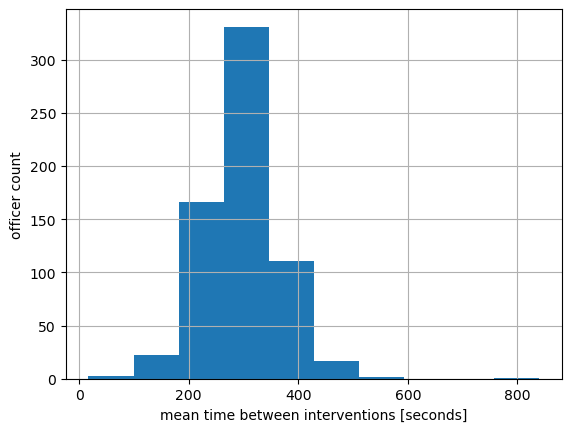

In [164]:
ax0 = wmean_time.astype('timedelta64[s]').div(np.timedelta64(1, "s")).hist()
ax0.set_xlabel("mean time between interventions [seconds]")
ax0.set_ylabel("officer count");

The super short average 'time_btwn' of 17s arises due to the unusual activity of an officer with a total of 3 (=2+1) interventions at the very start of this year, naturally non-clustered:

In [165]:
wmean_time.index[wmean_time < pd.to_timedelta("1 minutes")]

Index(['6a520679-4671-ed11-81ab-00224893324d'], dtype='object', name='Intervention officer GUID')

In [166]:
ime_df.query('`Intervention officer GUID` == "6a520679-4671-ed11-81ab-00224893324d"')

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
1445904,7acf3ebc-9862-4717-b33a-2f250cf4f084,b9c15094-6d29-46a3-8cf0-6ff29ccb1ca2,2024-01-01 07:29:47,INT-13741270-J6V2D-2024-01-01 07:29:56,445290003,445290000,NaN,6a520679-4671-ed11-81ab-00224893324d,NaN,NaN,NaN,Secondary Examination Area,2023-12-31 20:29:56,0 days 00:00:17,-1,2024-01-01 07:29:47,1
1445905,1fa3b538-c1fc-41eb-a5df-c5aafb156b4e,d3c3bce2-c007-4a36-acaa-e5c3cc6dad2f,2024-01-01 07:30:04,INT-13741275-X9Q8Z-2024-01-01 07:30:16,293050001,445290002,NaN,6a520679-4671-ed11-81ab-00224893324d,NaN,NaN,NaN,Secondary Examination Area,2023-12-31 20:30:16,1 days 09:51:41,-1,2024-01-01 07:30:04,1
1445906,b82597e2-4787-4396-979c-51c5a8827ca7,ec56b7e7-0304-48b3-b751-f1d3e6ffd03d,2024-01-02 17:21:45,INT-13753639-Q3Y8P-2024-01-02 17:22:2,445290005,445290003,NaN,6a520679-4671-ed11-81ab-00224893324d,NaN,NaN,NaN,Secondary Examination Area,2024-01-02 06:22:02,0 days 00:00:00,-1,2024-01-02 17:21:45,1


The officer who exhibits a long (14 min) average intervention time shows (non-clustered) activity dispersed over a month:

In [167]:
wmean_time.index[wmean_time > pd.to_timedelta("10 minutes")].to_list()

['b97d4b84-d2aa-ea11-a814-000d3a6a9def']

In [168]:
ime_df.query('`Intervention officer GUID` == "b97d4b84-d2aa-ea11-a814-000d3a6a9def"')

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
2463746,8c77a31f-191a-46af-89b1-73303cd0a7f5,a4d2d966-5380-ef11-ac21-000d3ad1e49e,2024-10-02 09:43:30,NaN,445290005,445290003,Added channel record to correct error. MA 2/10...,b97d4b84-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-10-02 00:15:25,0 days 00:14:00,-1,2024-10-02 09:43:30,1
2463747,f81fb87f-8f7f-ef11-ac21-000d3ad1e49e,4757e83a-5580-ef11-ac21-6045bde5817e,2024-10-02 09:57:30,NaN,445290005,445290002,New channel added due to error in previous MA ...,b97d4b84-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-10-02 00:28:30,15 days 04:31:59,-1,2024-10-02 09:57:30,1
2463748,dd5f6271-4d7e-40d8-8fca-41092530a885,cc144163-3c8c-ef11-8a6a-002248922b75,2024-10-17 14:29:29,NaN,445290005,445290003,"TAMS Admin audit, Mark Alessio 17/10/2024",b97d4b84-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-10-17 04:00:51,14 days 00:58:05,-1,2024-10-17 14:29:29,1
2463749,cefe80cb-8d9b-4f42-b31b-9ef383aa3dc7,763cbce4-4497-ef11-8a68-6045bdc30b40,2024-10-31 15:27:34,NaN,445290005,445290003,TAMS admin audit amendment. Inspection channel...,b97d4b84-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-10-31 04:59:24,3 days 16:39:49,-1,2024-10-31 15:27:34,1
2463750,82467265-7763-4d70-9f81-7ffd9aceed78,28593df2-2b9a-ef11-8a69-000d3aca6962,2024-11-04 08:07:23,NaN,445290005,445290003,Inspection channel added to replace deactivate...,b97d4b84-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-03 21:38:31,0 days 02:44:10,-1,2024-11-04 08:07:23,1
2463751,75bf04a6-b699-ef11-8a6a-6045bde5ac1d,7ba6020a-439a-ef11-8a6a-00224894e457,2024-11-04 10:51:33,NaN,445290005,445290003,"Manual entry created in error, inspection chan...",b97d4b84-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-04 00:23:42,2 days 00:39:27,-1,2024-11-04 10:51:33,1
2463752,3adf3ad0-7664-44c6-816f-116c7ad31611,434412dd-da9b-ef11-8a6a-002248922b75,2024-11-06 11:31:00,NaN,445290005,445290003,TAMS admin audit. System error as per defects ...,b97d4b84-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-06 01:03:01,36 days 03:28:06,-1,2024-11-06 11:31:00,1
2463753,cf0cbbae-dcb0-ef11-b8e8-6045bdc30b40,6284a1dd-41b8-ef11-b8e8-000d3aca6962,2024-12-12 14:59:06,NaN,445290005,445290003,Inspection Channel added. Mark Alessio 12/12/2024,b97d4b84-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-12-12 04:30:52,0 days 00:00:00,-1,2024-12-12 14:59:06,1


Note that there 653 officers above. The "missing" 5:

In [169]:
d5o = set(ime_df['Intervention officer GUID']).difference(set(wmean_time.index))
d5o

{'11b1b0aa-9fd9-ed11-a7c7-002248933507',
 '3ac7a308-0ba6-ef11-b8e9-6045bde5ac1d',
 '6063bfca-d4aa-ea11-a814-000d3a6a9def',
 '9017ee36-0da6-ef11-b8e9-6045bde533d1',
 'fae89c27-d3aa-ea11-a814-000d3a6a9def'}

These 5 carried a total of dozen non-clustered interventions: 

In [170]:
ime_df.query('`Intervention officer GUID` in @d5o')

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
255807,2e26c259-5e17-42b5-ace0-5e69109cf7a1,0183be50-5f31-4e8a-8a6a-609647709a8d,2024-11-20 11:54:30,INT-16506494-L9Q2T-2024-11-20 11:55:5,445290003,445290000,NaN,11b1b0aa-9fd9-ed11-a7c7-002248933507,NaN,NaN,NaN,Secondary Examination Area,2024-11-20 00:55:05,0 days 00:00:00,-1,2024-11-20 11:54:30.000,3
255808,81511afd-9679-409a-ba79-a7bd9bcbe81c,8b3a4add-ffb1-427f-8d90-cba8baf7d5ec,2024-11-20 11:54:30,INT-16506495-M8H2Z-2024-11-20 11:55:6,445290003,445290000,NaN,11b1b0aa-9fd9-ed11-a7c7-002248933507,NaN,NaN,NaN,Secondary Examination Area,2024-11-20 00:55:06,0 days 00:00:00,-1,2024-11-20 11:54:30.010,3
255809,c15981c9-8314-4dc2-b7cf-126b3326ffde,52e810e3-9309-4fe5-bede-cd180d0879df,2024-11-20 11:54:30,INT-16506496-Y6T1N-2024-11-20 11:55:6,445290003,445290000,NaN,11b1b0aa-9fd9-ed11-a7c7-002248933507,NaN,NaN,NaN,Secondary Examination Area,2024-11-20 00:55:06,19 days 20:50:39,-1,2024-11-20 11:54:30.020,3
255810,65ee3c00-5c8d-412f-87a6-5bdb68cdd725,4c1461db-bad7-4cd3-a1e5-8b23bc7bf473,2024-12-10 08:45:09,INT-16710404-C7M8Q-2024-12-10 08:45:32,445290003,445290000,NaN,11b1b0aa-9fd9-ed11-a7c7-002248933507,NaN,NaN,NaN,Secondary Examination Area,2024-12-09 21:45:32,0 days 00:00:00,-1,2024-12-10 08:45:09.020,2
255811,11c8bad3-b344-4e82-8d87-88ebe47ebebf,a40d43f2-8fc1-4d7c-a8ce-864323869712,2024-12-10 08:45:09,INT-16710426-C0Z3G-2024-12-10 08:45:32,445290003,445290000,NaN,11b1b0aa-9fd9-ed11-a7c7-002248933507,NaN,NaN,NaN,Secondary Examination Area,2024-12-09 21:45:32,0 days 00:00:00,-1,2024-12-10 08:45:09.030,2
817351,2da25ea7-6a06-49d6-bfd8-87babe5af0d6,0d8c0ac7-1aae-4b7f-940f-2eea0d9b5efe,2024-12-03 14:40:46,INT-16640532-V5S1G-2024-12-03 15:53:45,445290005,445290003,NaN,3ac7a308-0ba6-ef11-b8e9-6045bde5ac1d,NaN,NaN,NaN,Secondary Examination Area,2024-12-03 04:53:45,0 days 00:00:00,-1,2024-12-03 14:40:46.000,1
1300866,e799bdd4-d4d8-447e-a855-01c46ec75f37,02e64694-89eb-40e6-8998-baf04483f6a1,2024-01-01 00:31:25,INT-13740443-F6R0S-2024-01-01 03:31:30,445290000,445290001,Seeds and nuts,6063bfca-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,Verbal declaration,Baggage claim,2023-12-31 16:31:30,0 days 00:27:50,-1,2024-01-01 00:31:25.000,1
1300867,80e8eaea-6bd0-4f0a-a67d-999a91448b1f,130c0609-b518-4908-9707-191a05955ef1,2024-01-01 00:59:15,INT-13740505-B1D0P-2024-01-01 03:59:21,445290000,445290001,Dry food snack and leftover for oldest dauy,6063bfca-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,Verbal declaration,Baggage claim,2023-12-31 16:59:21,0 days 00:00:00,-1,2024-01-01 00:59:15.000,1
1999421,3bccd09b-6f53-4c2e-8376-63c639d959f2,597b9e8a-6e8f-4c0e-a12d-69b498b10490,2024-12-03 14:45:11,INT-16640541-D3F3T-2024-12-03 15:54:34,445290005,445290003,NaN,9017ee36-0da6-ef11-b8e9-6045bde533d1,NaN,NaN,NaN,Secondary Examination Area,2024-12-03 04:54:34,0 days 00:00:00,-1,2024-12-03 14:45:11.000,1
3274557,eec8bd90-687a-494d-8b94-dd3902ef0d22,3b957e57-5a96-ef11-8a68-000d3aca6962,2024-10-30 11:58:26,NaN,293050001,445290002,Survey scanned too early. Channel re-added for...,fae89c27-d3aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-10-30 01:00:24,0 days 00:30:57,-1,2024-10-30 11:58:26.000,1


These are the 175812 rows that need imputation (by reducing the excessive 'time_btwn' values):

In [171]:
ime_df.loc[ ime_df['Intervention officer GUID'].isin(wmean_time.index.to_list()) & ime_df['time_btwn'].gt(pd.to_timedelta("20 minutes")) & ime_df['intervention_batch'].ge(0), :]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
100,5b97ae7f-50aa-4367-a44c-8423b946c8c2,56c302df-0a53-436d-ac35-040c48ca4d75,2024-01-05 08:54:36,INT-13775175-V0S4D-2024-01-05 08:55:25,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,6644fc7d-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-01-04 21:55:25,0 days 01:11:22,0,2024-01-05 08:54:36.780,7
137,15e49309-3490-4f15-ab27-406c16648db3,e691d500-62ac-4d35-b71e-1b37da9698d4,2024-01-05 10:37:59,INT-13776494-R2K4M-2024-01-05 10:38:9,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,72bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2024-01-04 23:38:09,0 days 00:28:09,1,2024-01-05 10:38:00.070,3
155,f016a0da-0307-41ac-92fb-a1a8fd2e5396,b2b61b14-f237-4e05-a142-03abc4f8d5db,2024-01-05 11:11:35,INT-13776783-R4C0R-2024-01-05 11:12:32,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,7e08a796-6877-ec11-8d21-00224812d0c8,NaN,Secondary Examination Area,2024-01-05 00:12:32,0 days 00:20:07,2,2024-01-05 11:11:36.230,5
164,04a7eeb4-33d1-4a19-9f70-8f074844d42f,2876439d-56d1-4a25-ad1a-580c5a830cf7,2024-01-05 11:55:54,INT-13777146-N4X3J-2024-01-05 11:56:11,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,cecd11ff-2fc9-ed11-b596-0022489331f6,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-05 00:56:11,0 days 00:20:11,3,2024-01-05 11:55:55.280,1
253,ad9ab117-e137-498d-b2d6-eb9dbefb9610,b1d567c9-9082-496c-b99c-2cb2091dd2f5,2024-01-06 08:52:25,INT-13784298-R9B2B-2024-01-06 09:30:23,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,ed1307ea-fb82-ec11-8d21-00224892090f,55a2ddb6-92ab-eb11-8236-000d3a6b429b,NaN,Secondary Examination Area,2024-01-05 22:30:24,0 days 00:38:09,4,2024-01-06 08:52:26.960,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3321732,454e95da-b849-4b61-b59c-2b88d05abb98,d0a87ab0-0f0d-418f-ba65-935bec46ad31,2024-12-15 11:09:52,INT-16767130-C0G7N-2024-12-15 11:33:21,445290003,445290001,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,X-ray referral,Secondary Examination Area,2024-12-15 00:33:21,0 days 00:23:26,322,2024-12-15 11:10:14.940,1
3321756,12e1fa3f-0871-4da3-8f98-0a6f45fe3f6b,ac18bb93-d501-461d-b364-d582d8aa3c40,2024-12-17 08:52:45,INT-16788778-J7P1F-2024-12-17 08:52:59,445290005,445290002,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-12-16 21:52:59,0 days 01:00:48,323,2024-12-17 08:53:08.020,1
3321777,086b31fb-5704-49b8-8a95-acdec35732c0,d569dc76-c5b0-49cf-972f-e8e756ecd983,2024-12-17 10:37:47,INT-16790581-B6D0B-2024-12-17 10:37:59,445290005,445290002,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-12-16 23:37:59,0 days 20:05:04,324,2024-12-17 10:38:10.140,1
3321811,8a61d707-4128-4a1d-9aed-4b3e689d25eb,46c1459a-1387-450c-b730-54c512931719,2024-12-18 09:24:29,INT-16801313-H2L9Q-2024-12-18 09:29:44,445290003,445290000,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-12-17 22:29:44,0 days 00:27:07,326,2024-12-18 09:24:52.250,4


Imputing the mean intervention time for the final sub-batch which starts at the same time, but takes over 20 min before the next batch (this may take a couple of minutes):

In [172]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for offc in wmean_time.index.to_list():
        # print(offc)
        ime_df['time_btwn'] = ime_df['time_btwn'].mask(ime_df['Intervention officer GUID'].eq(offc) & ime_df['time_btwn'].gt(pd.to_timedelta("20 minutes")) & ime_df['intervention_batch'].ge(0), wmean_time[offc])

Impute the 'time_btwn' values for the end of the final cluster of each officer:

In [173]:
ime_df[ime_df['Intervention officer GUID'].isin([o for o, t in equal_0.index]) &
                             ime_df['Intervention method event start datetime'].isin([t for o, t in equal_0.index]) &
                             ime_df['time_btwn'].eq(pd.to_timedelta("0 seconds")) &
                             ime_df['intervention_batch'].ge(0)]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
15467,b7d812d6-8f36-497b-a782-260fb8ea572b,cdaab54e-fc4a-4c3e-847e-6ca3e94361ba,2024-12-08 11:24:53,INT-16691715-B7V4D-2024-12-08 11:25:3,445290005,445290003,NaN,0030689c-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-12-08 00:25:03,0 days,31,2024-12-08 11:24:54.770,1
39676,8408d418-d457-4bd9-8739-7580d99e25c5,64fb93ce-0b92-4fc8-8446-ced21898212a,2024-12-16 00:13:22,INT-16774354-K9W7P-2024-12-16 00:13:32,445290003,445290000,NaN,0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-12-15 13:13:33,0 days,456,2024-12-16 00:13:58.250,5
39677,866abce6-2dc1-4d22-81bb-76ce2e846839,91c2c31c-d828-43ee-9e35-a0376cc2d564,2024-12-16 00:13:22,INT-16774355-K6R4P-2024-12-16 00:13:32,445290003,445290000,NaN,0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-12-15 13:13:32,0 days,456,2024-12-16 00:13:58.260,5
39678,1d9e046e-4932-461a-821f-a0403e4bf3e4,624f0c01-b894-410c-b33c-ef6e49a2183e,2024-12-16 00:13:22,INT-16774356-P2X9Q-2024-12-16 00:13:32,445290003,445290000,NaN,0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-12-15 13:13:32,0 days,456,2024-12-16 00:13:58.270,5
39679,09a60f63-f4f6-4d1d-913d-0f5048cb84ba,e27011a8-544f-4ac2-a0e2-71fcf61436b9,2024-12-16 00:13:22,INT-16774357-T7D2Z-2024-12-16 00:13:32,445290003,445290000,NaN,0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-12-15 13:13:32,0 days,456,2024-12-16 00:13:58.280,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3297940,3fbbf8e6-87f1-468c-a962-592e79e58653,b6b7ea4e-5f58-4c24-bec4-d1b37e138f9c,2024-12-18 00:22:11,INT-16797827-G3T7H-2024-12-18 00:22:18,445290000,445290000,NaN,fcd011f6-d3aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Baggage claim,2024-12-17 13:22:18,0 days,298,2024-12-18 00:22:31.690,1
3308988,d80ba6aa-79a7-4ca0-8767-350cfabfb30d,575bd73c-d119-45b9-9600-7e432f156616,2024-12-17 12:04:20,INT-16792482-H3Z6X-2024-12-17 13:06:53,445290005,445290003,NaN,fe185c2a-ac8f-ed11-aad1-002248933b6d,NaN,NaN,NaN,Secondary Examination Area,2024-12-17 02:06:53,0 days,490,2024-12-17 12:05:06.200,1
3315500,c0ecfaed-2603-4025-8352-c2d5aedfbdaf,29c17510-691b-4a83-a99f-8e6808b425da,2024-12-18 23:09:53,INT-16808834-R3X1F-2024-12-18 23:10:2,445290003,445290000,NaN,ff36baa6-d5aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-12-18 12:10:02,0 days,375,2024-12-18 23:10:16.200,2
3315501,14bd4c5f-d458-48b7-ba22-8539408b7a58,163d7c23-f507-4745-9f42-0aa2325ae138,2024-12-18 23:09:53,INT-16808835-Z8M1T-2024-12-18 23:10:1,445290003,445290000,NaN,ff36baa6-d5aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-12-18 12:10:01,0 days,375,2024-12-18 23:10:16.210,2


In [174]:
for offc, tstamp in equal_0.index.to_list():
    ime_df['time_btwn'] = ime_df['time_btwn'].mask(ime_df['Intervention officer GUID'].eq(offc) &
                                                   ime_df['Intervention method event start datetime'].eq(tstamp) &
                                                   ime_df['time_btwn'].eq(pd.to_timedelta("0 seconds")) &
                                                   ime_df['intervention_batch'].ge(0), wmean_time[offc])

Now all the interventions with 'time_btwn' exceeding 20 minutes are the non-clustered kind (with label -1):

In [175]:
ime_df.query('time_btwn.gt(@pd.to_timedelta("20 minutes"))')['intervention_batch'].value_counts()

intervention_batch
-1    123763
Name: count, dtype: int64

The 'time_btwn' descriptive statistics:

In [176]:
ime_df.query('time_btwn.gt(@pd.to_timedelta("20 minutes"))')['time_btwn'].describe()

count                       123763
mean     0 days 14:22:25.196326850
std      2 days 15:06:21.772077904
min                0 days 00:20:01
25%                0 days 00:33:07
50%                0 days 01:05:49
75%         0 days 05:10:06.500000
max              147 days 21:37:54
Name: time_btwn, dtype: object

In [177]:
ime_df.query('intervention_batch.lt(0)')['time_btwn'].describe()

count                       279043
mean     0 days 06:24:24.863383062
std      1 days 18:37:29.198728865
min                0 days 00:00:00
25%                0 days 00:00:08
50%                0 days 00:11:31
75%                0 days 00:54:45
max              147 days 21:37:54
Name: time_btwn, dtype: object

Let's save these and all non-clustered interventions into a separate dataframe:

In [178]:
extra_df = ime_df.query('time_btwn.gt(@pd.to_timedelta("20 minutes")) or intervention_batch.lt(0)')
extra_df.shape

(279043, 17)

No dupllcate rows:

In [179]:
extra_df.duplicated().sum()

0

Finally, dropping the interventions with uncertain ending times, i.e., the final intervention of each batch (namely, when the 'time_btwn' exceeds 20 minutes)
and the interventions that have not been assigne to a batch (those with 'intervention_batch' label -1):

In [180]:
# ime_df = ime_df.drop(ime_df.query('time_btwn.gt(@pd.to_timedelta("20 minutes"))').index, axis=0).\
ime_df = ime_df.query('intervention_batch.ge(0)').reset_index(drop=True)

In [181]:
ime_df['time_btwn'].describe()

count                      3042797
mean     0 days 00:02:25.691245587
std      0 days 00:03:41.925050803
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:20
75%                0 days 00:03:57
max                0 days 00:20:00
Name: time_btwn, dtype: object

Anything gone missing?

In [182]:
3321840 - (ime_df.shape[0] + extra_df.shape[0])

0

And now we can evaluate the 'time_btwn' as the maximum value found in a group with the identical intervention start datetime divided by the size of the group (i.e., 'intervention_count'):

In [183]:
ime_df['time_btwn'] = ime_df.groupby(['Intervention officer GUID', ime_df['Intervention method event start datetime'].round("5s")])['time_btwn'].transform("max").div(ime_df['intervention_count'])

ime_df['time_btwn'].describe()

C:\Users\AB0175\AppData\Local\Temp\ipykernel_21180\2338858467.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ime_df['time_btwn'] = ime_df.groupby(['Intervention officer GUID', ime_df['Intervention method event start datetime'].round("5s")])['time_btwn'].transform(max).div(ime_df['intervention_count'])


count                      3042797
mean     0 days 00:02:25.640978021
std      0 days 00:02:52.683541865
min      0 days 00:00:00.111111111
25%                0 days 00:00:40
50%         0 days 00:01:23.400000
75%                0 days 00:03:01
max                0 days 00:20:00
Name: time_btwn, dtype: object

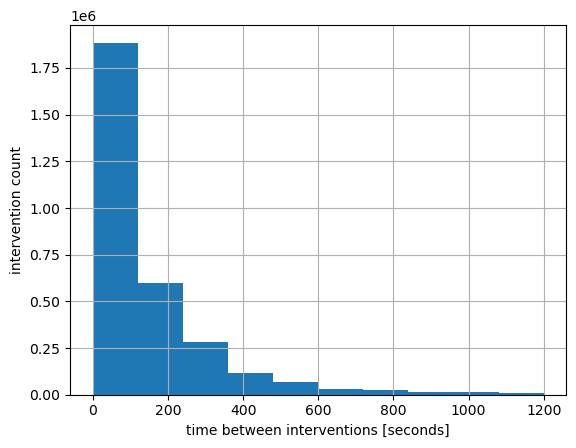

In [184]:
ax1 = ime_df['time_btwn'].astype('timedelta64[s]').div(np.timedelta64(1, "s")).hist()
ax1.set_xlabel("time between interventions [seconds]")
ax1.set_ylabel("intervention count");

There still remain 654 interventions with super short 'time_btwn' values:

In [185]:
ime_df.query('time_btwn.le(@pd.to_timedelta("1 seconds"))')

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
7728,9686e4cc-04dd-49ac-8d64-647912e13e99,7b90c7ae-2224-41f9-a5c6-4770145c3210,2024-06-02 12:21:29,INT-14926813-J7C5D-2024-06-02 12:21:40,445290002,445290001,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,77cd9aa9-e674-ec11-8943-002248920ae0,K9 referral,Secondary Examination Area,2024-06-02 02:21:40,0 days 00:00:00.333333333,171,2024-06-02 12:22:28.130,3
7729,9ef412a6-698b-4169-8681-46b588cbad04,59dcc2ad-ff61-4065-a86b-43b2828eb78b,2024-06-02 12:21:29,INT-14926816-C2C2W-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:00:00.333333333,171,2024-06-02 12:22:28.140,3
7730,dcfaffe1-141d-41d2-b876-986ae80f155c,e9f884bd-59be-4a35-9941-637899f53831,2024-06-02 12:21:29,INT-14926817-P5Y2L-2024-06-02 12:21:48,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:48,0 days 00:00:00.333333333,171,2024-06-02 12:22:28.150,3
36466,71c1da56-8ec1-4bd5-8b4a-95f9273546cc,eaddf967-56ec-411e-8878-d92817ba3d31,2024-11-04 18:43:55,INT-16349141-Y5C6K-2024-11-04 18:50:37,445290005,445290003,NaN,0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-11-04 07:50:37,0 days 00:00:01,376,2024-11-04 18:44:27.190,1
52197,c2c1007d-2e95-43e8-be7b-d44d8393e194,52f75df3-3e88-4f0a-85d3-bb978e59922c,2024-02-22 23:58:24,INT-14176330-G1F8R-2024-02-23 00:59:49,445290003,445290000,NaN,03259f49-b44a-ed11-bba2-002248933bc9,NaN,NaN,NaN,Secondary Examination Area,2024-02-22 13:59:50,0 days 00:00:01,100,2024-02-22 23:58:37.650,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2985888,5453ae4d-d6a4-4b3d-a1d4-58dc85330129,038cf8c8-28fe-41f9-818d-9abbc8383733,2024-02-03 07:18:29,INT-14020881-B2C7B-2024-02-03 07:18:38,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:38,0 days 00:00:00.200000,43,2024-02-03 07:18:38.830,5
2985889,22884045-4f06-463a-9732-d286c7fed34c,c9b4f87a-340b-454c-8b22-97599a47515c,2024-02-03 07:18:29,INT-14020882-V4Z4R-2024-02-03 07:18:38,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:38,0 days 00:00:00.200000,43,2024-02-03 07:18:38.840,5
2985890,c91db98c-0486-434c-a492-6461afe63a39,713fa15c-5723-4c38-aed9-5f133174259f,2024-02-03 07:18:29,INT-14020883-W8K4N-2024-02-03 07:18:38,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:38,0 days 00:00:00.200000,43,2024-02-03 07:18:38.850,5
2985891,873683d6-01cf-4c2d-846c-d647e9eed061,e8a643da-eaf3-469a-b804-1f7d5eca9868,2024-02-03 07:18:29,INT-14020884-L5P9W-2024-02-03 07:18:39,445290002,445290000,NaN,fa17a6bf-4eec-ec11-bb3d-000d3acbc8f7,8ca4616b-30c9-ed11-b596-0022489331f6,b65fd5b3-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-02-02 20:18:39,0 days 00:00:00.200000,43,2024-02-03 07:18:38.860,5


Let's inspect the four sub-batches showing above:

In [186]:
ime_df.iloc[131277: 131289, :]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch,start_dtime,intervention_count
131277,a0d715c3-2764-4d8d-9d90-1b9cecfda4ff,7e0b07ab-0a8a-4118-b886-18d7af2305c5,2024-11-12 23:47:33,INT-16432541-M7B4T-2024-11-13 00:47:44,445290003,445290001,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,Declared item of interest,Secondary Examination Area,2024-11-12 13:47:44,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.170,9
131278,d198918e-e7bf-4794-aea2-01c0ba67d9ce,43433b49-8c02-440e-853c-7e0c541201c8,2024-11-12 23:47:33,INT-16432542-R9T3J-2024-11-13 00:47:46,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:46,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.180,9
131279,68e9ab51-4704-4d58-b9a2-83929ea1b775,9bcbb580-6d26-4207-8c49-9a4d70a86651,2024-11-12 23:47:33,INT-16432543-N9W1W-2024-11-13 00:47:46,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:46,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.190,9
131280,630b2f06-4d04-4ab5-9a1d-43d3230b86f2,0057fb98-9508-4a50-a67f-9528b9b2ef80,2024-11-12 23:47:33,INT-16432544-B6J4H-2024-11-13 00:47:46,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:46,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.200,9
131281,d25d4b57-2715-4548-aa69-6ba5051e6a1d,bfead267-92b3-4680-b443-032ed872ca69,2024-11-12 23:47:33,INT-16432545-R4S1P-2024-11-13 00:47:46,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:46,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.210,9
131282,2b1130f7-9999-4f09-a377-307a21e02031,de05b849-8b17-49de-938a-d2e560465108,2024-11-12 23:47:33,INT-16432546-D8M8X-2024-11-13 00:47:46,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:46,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.220,9
131283,820354c4-f1d2-4a48-9746-19544e868469,002640d2-979f-4773-bcfa-fb7a59f5e954,2024-11-12 23:47:33,INT-16432547-X0X0V-2024-11-13 00:47:46,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:46,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.230,9
131284,1f09e8cd-bf48-4151-a600-a3c9bc7f501b,35ee56bc-773e-4735-8de9-488fe86e0929,2024-11-12 23:47:33,INT-16432548-G9W1S-2024-11-13 00:47:46,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:46,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.240,9
131285,278b66fe-0b03-4b1c-b451-d52840f088f1,89b55df6-3055-4b79-a8f9-db4ea2aaf214,2024-11-12 23:47:33,INT-16432549-M7F9S-2024-11-13 00:47:46,445290003,445290000,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:46,0 days 00:00:00.888888888,327,2024-11-12 23:47:59.250,9
131286,a0d715c3-2764-4d8d-9d90-1b9cecfda4ff,8d485cb0-91ec-47da-939d-0b5c1348b8e3,2024-11-12 23:47:41,INT-16432541-M7B4T-2024-11-13 00:47:49,445290005,445290003,NaN,09d6568a-d2aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-11-12 13:47:49,0 days 00:04:59,327,2024-11-12 23:48:07.250,1


In [187]:
dmean_time = ime_df.groupby('Intervention officer GUID')['time_btwn'].mean().round("1s")

dmean_time

Intervention officer GUID
002727cb-77a9-eb11-9442-0022480fe6d6   0 days 00:01:17.282747496
0030689c-d2aa-ea11-a814-000d3a6a9def   0 days 00:03:14.999999999
0116c2cb-c1e4-ee11-904d-002248933647   0 days 00:02:25.855423619
01493553-d3aa-ea11-a814-000d3a6a9def   0 days 00:02:42.019575856
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e   0 days 00:02:05.970068347
                                                  ...           
fcd011f6-d3aa-ea11-a814-000d3a6a9def   0 days 00:02:27.873501997
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def   0 days 00:01:24.330434782
fe185c2a-ac8f-ed11-aad1-002248933b6d   0 days 00:02:48.547813375
ff36baa6-d5aa-ea11-a814-000d3a6a9def   0 days 00:02:18.789998281
ff485647-46ba-ee11-9078-0022489330fc   0 days 00:03:18.947430496
Name: time_btwn, Length: 647, dtype: timedelta64[ns]

The distribution of the average 'time_btwn' for all the officers:

In [188]:
dmean_time.describe()

count                          647
mean     0 days 00:02:32.659376341
std      0 days 00:00:41.271675454
min      0 days 00:00:38.572074983
25%      0 days 00:02:08.702845547
50%      0 days 00:02:33.840438489
75%      0 days 00:02:57.717494020
max      0 days 00:05:34.222222222
Name: time_btwn, dtype: object

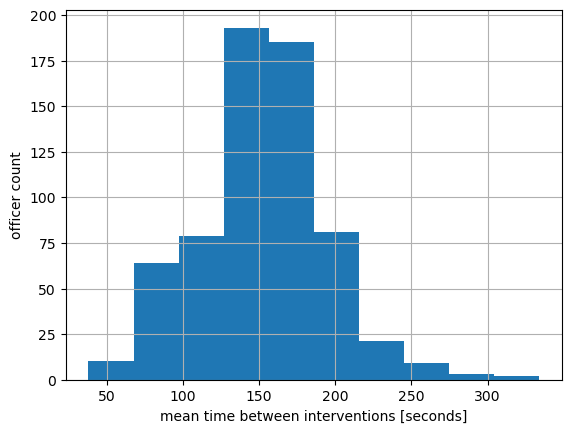

In [189]:
ax2 = dmean_time.astype('timedelta64[s]').div(np.timedelta64(1, "s")).hist()
ax2.set_xlabel("mean time between interventions [seconds]")
ax2.set_ylabel("officer count");

The full 2024 time effort:

In [190]:
ime_df['time_btwn'].sum().round("1s")

Timedelta('5129 days 02:52:11')

The 1st half of 2024 time effort:

In [191]:
ime_df.query('`Intervention method event start datetime`.lt(@pd.to_datetime("2024-07-01 00:00:01"))')['time_btwn'].sum().round("1s")

Timedelta('2335 days 02:42:45')

It is interesting to resolve the distribution of 'time_btwn' based on the intervention method:

In [192]:
ime_df.groupby('Intervention method ID', observed=True)['time_btwn'].describe().rename(index={293050001: "Survey",
                                                                                              445290000: "Rover",
                                                                                              445290001: "Marshal",
                                                                                              445290002: "Detector dog",
                                                                                              445290003: "2D X-Ray",
                                                                                              445290004: "3D X-Ray",
                                                                                              445290005: "Inspection bench"})

,count,mean,std,min,25%,50%,75%,max
Intervention method ID,,,,,,,,
Survey,26451,0 days 00:07:31.339079807,0 days 00:04:51.709278962,0 days 00:00:08,0 days 00:04:16,0 days 00:06:38,0 days 00:10:42,0 days 00:20:00
Rover,261656,0 days 00:02:12.591524750,0 days 00:03:03.831686114,0 days 00:00:05,0 days 00:00:21,0 days 00:01:03,0 days 00:02:43,0 days 00:20:00
Marshal,7543,0 days 00:02:35.790269123,0 days 00:03:22.534162567,0 days 00:00:05,0 days 00:00:14,0 days 00:01:16,0 days 00:03:46,0 days 00:19:56
Detector dog,643427,0 days 00:01:10.374256908,0 days 00:01:26.561157443,0 days 00:00:00.111111111,0 days 00:00:28.636363636,0 days 00:00:46.200000,0 days 00:01:18,0 days 00:20:00
2D X-Ray,1092466,0 days 00:02:15.306257585,0 days 00:02:33.865804170,0 days 00:00:00.200000,0 days 00:00:41,0 days 00:01:25,0 days 00:02:49,0 days 00:20:00
3D X-Ray,23,0 days 00:02:17.043478260,0 days 00:02:24.148433050,0 days 00:00:30,0 days 00:00:50,0 days 00:01:19,0 days 00:02:16.500000,0 days 00:09:49
Inspection bench,1011231,0 days 00:03:20.001514985,0 days 00:03:17.338829766,0 days 00:00:00.142857142,0 days 00:01:07,0 days 00:02:15,0 days 00:04:27.500000,0 days 00:20:00


The partial contributions from each intervention method (in the first half of 2024): 

In [193]:
ime_df[ime_df['Intervention method event start datetime'].between(pd.to_datetime("2023-07-01 00:00:01"), pd.to_datetime("2024-06-30 23:59:50"))]\
    .groupby('Intervention method ID', observed=True)['time_btwn'].sum().rename(index={293050001: "Survey",
                                                                                       445290000: "Rover",
                                                                                       445290001: "Marshal",
                                                                                       445290002: "Detector dog",
                                                                                       445290003: "2D X-Ray",
                                                                                       445290004: "3D X-Ray",
                                                                                       445290005: "Inspection bench"})

Intervention method ID
Survey                         65 days 16:19:23
Rover                          97 days 06:23:52
Marshal                         6 days 10:39:54
Detector dog        252 days 07:44:11.999935347
2D X-Ray            805 days 05:47:45.999966214
Inspection bench   1108 days 03:28:25.999973036
Name: time_btwn, dtype: timedelta64[ns]

Evidently, with the exception of the small number of "Survey" interventions, the most "Inspection bench" is the most time consuming type of intervention.

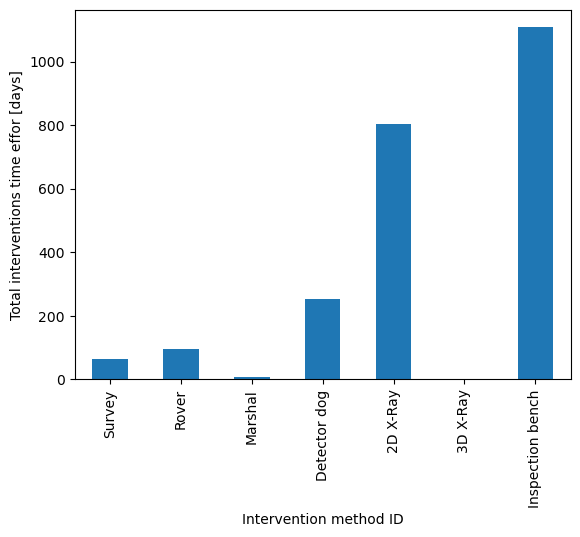

In [194]:
ax2 = ime_df[ime_df['Intervention method event start datetime'].between(pd.to_datetime("2023-07-01 00:00:01"), pd.to_datetime("2024-06-30 23:59:50"))]\
    .groupby('Intervention method ID', observed=False)['time_btwn'].sum().rename(index={293050001: "Survey",
                                                                        445290000: "Rover",
                                                                        445290001: "Marshal",
                                                                        445290002: "Detector dog",
                                                                        445290003: "2D X-Ray",
                                                                        445290004: "3D X-Ray",
                                                                        445290005: "Inspection bench"}).dt.days.plot(kind="bar")
#                                                                       445290005: "Inspection bench"}).astype('timedelta64[D]').plot(kind="bar")  BROKEN

ax2.set_ylabel("Total interventions time effor [days]");